This initial code block imports all necessary Python libraries for the project. These libraries include `pandas` and `numpy` for data manipulation and numerical operations, `torch` and `transformers` for deep learning functionalities (specifically for using pre-trained models from Hugging Face), `random` for generating random numbers, and `matplotlib.pyplot` along with `plotly.graph_objects` and `plotly.subplots` for creating various types of visualizations.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
import random

This code defines the path to the CSV file and loads the patient journal data into a pandas DataFrame. It then displays the first few rows and the shape of the DataFrame for initial inspection.

In [ ]:
# Define the CSV file path
csv_filename = 'synthetic_dataset_300.csv'

# Load the CSV into a DataFrame
df_patient_journals = pd.read_csv(csv_filename)

display(df_patient_journals.head())
print(f"Shape of df_patient_journals: {df_patient_journals.shape}")

,patient_id,age,gender,profession,education,writing_tone,punctuation_style,uses_abbreviations,vocabulary_level,day_1,day_2,day_3,day_4,day_5,day_6,day_7,diagnosis
0,P001,58,Male,Registered Nurse,Bachelor's,narrative,standard,Yes,colloquial,I looked at my computer screen and literally w...,"I feel like a hollow shell of myself, just goi...",Had an absolute blast hanging out w/ Marcus an...,My brain is running at a hundred miles an hour...,I recalled how excited I was on my first day h...,I have checked my locked door five times alrea...,"I feel completely invisible to the world, and ...",Burnout
1,P002,44,Male,Astrophysicist,PhD,formal,minimal,Yes,academic,"Today felt balanced, calm, and relatively stra...",I went for a long run after work and felt a gr...,Spent a quiet evening playing board games w/ m...,I feel optimal affective equilibrium and at pe...,I keep remembering that one presentation where...,I dealt w/ a minor transient stressor today bu...,We went out to a new Italian bistro in town an...,Healthy
2,P003,38,Male,Senior UX Researcher,Master's,highly-emotional,ellipses,Yes,professional,I have been sitting at my desk for nine hours ...,"My body feels heavy, sluggish, and constantly ...",Everyone else is out living their lives while ...,I am so incredibly overwhelmed by the sheer vo...,I keep remembering old mistakes and cringing a...,My brain is running at a hundred miles an hour...,Cancelling plans has become my favorite hobby ...,Depression
3,P004,50,Non-binary,Speech Pathologist,Master's,formal,standard,No,colloquial,I am so tired of feeling like an absolute psyc...,"I forgot to eat lunch today, honestly food jus...",I avoid going to crowded places because they t...,"I feel so restless, like I need to run away bu...",I keep remembering old mistakes and cringing a...,My thoughts are swirling around like a hurrica...,My partner tried to talk about dinner and I co...,Anxiety
4,P005,53,Non-binary,Senior Research Scientist,PhD,narrative,ellipses,Yes,academic,"A wave of intense, irrational anger washed ove...",I feel incredibly dizzy and nauseous from this...,I ended up leaving early bcs the crowded room ...,Everything feels incredibly urgent and I am co...,Memories of what happened are crashing through...,"I feel this constant, generalized somatic hype...",I went to a small gathering but felt like ever...,PTSD


Shape of df_patient_journals: (300, 17)


This cell checks for the availability of a GPU and sets the `device` variable accordingly. It prints whether the system will use GPU (high performance) or CPU (standard) for computations.

In [ ]:
device = 0 if torch.cuda.is_available() else -1
print(f"System: {'GPU (High Performance)' if device == 0 else 'CPU (Standard)'}")

System: GPU (High Performance)


This code block defines a `clean_text` function to preprocess patient journal entries by removing links, numbers, and most special characters, while normalizing whitespace. It then applies this cleaning function to all 'day_X_text' columns in the `df_patient_journals` DataFrame and displays the first few rows of the cleaned data.

In [ ]:
import pandas as pd
import re

# Pre-compile patterns for performance
# The _special_char_pattern has been updated to allow repeated punctuation and to remove only irrelevant symbols.
_link_pattern = re.compile(r'http\S+')
_number_pattern = re.compile(r'\d+')
# Preserve English letters, spaces, common punctuation,
_special_char_pattern = re.compile(r'[^a-zA-Z0-9\s.,!?;:\'()-]')
_whitespace_pattern = re.compile(r'\s+')

def clean_text(text):
    # Return empty string for NaN values
    if pd.isna(text):
        return ""

    text = str(text)

    # 2. Remove links
    text = _link_pattern.sub('', text)

    # 3. Remove numbers (not relevant for emotional analysis)
    text = _number_pattern.sub('', text)

    # 4. Remove special characters (preserving punctuation for syntax)
    # The regex removes any symbol not defined in the parenthesis, but preserves punctuation marks like !?.
    text = _special_char_pattern.sub('', text)

    # 5. Normalize whitespaces
    text = _whitespace_pattern.sub(' ', text).strip()

    return text

# Apply the clean_text function to all 'day_X_text' columns in df_patient_journals
for i in range(1, 8):
    col_name = f'day_{i}_text'
    if col_name in df_patient_journals.columns:
        df_patient_journals[col_name] = df_patient_journals[col_name].apply(clean_text)

# Display the head of the DataFrame to show the cleaned data
display(df_patient_journals.head())

,patient_id,age,gender,profession,education,writing_tone,punctuation_style,uses_abbreviations,vocabulary_level,day_1,day_2,day_3,day_4,day_5,day_6,day_7,diagnosis
0,P001,58,Male,Registered Nurse,Bachelor's,narrative,standard,Yes,colloquial,I looked at my computer screen and literally w...,"I feel like a hollow shell of myself, just goi...",Had an absolute blast hanging out w/ Marcus an...,My brain is running at a hundred miles an hour...,I recalled how excited I was on my first day h...,I have checked my locked door five times alrea...,"I feel completely invisible to the world, and ...",Burnout
1,P002,44,Male,Astrophysicist,PhD,formal,minimal,Yes,academic,"Today felt balanced, calm, and relatively stra...",I went for a long run after work and felt a gr...,Spent a quiet evening playing board games w/ m...,I feel optimal affective equilibrium and at pe...,I keep remembering that one presentation where...,I dealt w/ a minor transient stressor today bu...,We went out to a new Italian bistro in town an...,Healthy
2,P003,38,Male,Senior UX Researcher,Master's,highly-emotional,ellipses,Yes,professional,I have been sitting at my desk for nine hours ...,"My body feels heavy, sluggish, and constantly ...",Everyone else is out living their lives while ...,I am so incredibly overwhelmed by the sheer vo...,I keep remembering old mistakes and cringing a...,My brain is running at a hundred miles an hour...,Cancelling plans has become my favorite hobby ...,Depression
3,P004,50,Non-binary,Speech Pathologist,Master's,formal,standard,No,colloquial,I am so tired of feeling like an absolute psyc...,"I forgot to eat lunch today, honestly food jus...",I avoid going to crowded places because they t...,"I feel so restless, like I need to run away bu...",I keep remembering old mistakes and cringing a...,My thoughts are swirling around like a hurrica...,My partner tried to talk about dinner and I co...,Anxiety
4,P005,53,Non-binary,Senior Research Scientist,PhD,narrative,ellipses,Yes,academic,"A wave of intense, irrational anger washed ove...",I feel incredibly dizzy and nauseous from this...,I ended up leaving early bcs the crowded room ...,Everything feels incredibly urgent and I am co...,Memories of what happened are crashing through...,"I feel this constant, generalized somatic hype...",I went to a small gathering but felt like ever...,PTSD


This cell defines the name of a pre-trained Hugging Face model (`SamLowe/roberta-base-go_emotions`) for sentiment analysis. It initializes a `pipeline` from the `transformers` library to use this model, configured to return all emotion labels. It confirms that the model has been successfully loaded, indicating readiness for emotion detection.

In [ ]:
# Define the name of the pre-trained Hugging Face model for sentiment analysis.
model_name = "SamLowe/roberta-base-go_emotions"
# Initialize the sentiment-analysis pipeline using the specified model.
# 'top_k=None' ensures that all possible emotion labels are returned, not just the top one.
# 'device=device' uses a GPU if available (device=0) or CPU (device=-1) for inference.
classifier = pipeline("sentiment-analysis",
                      model=model_name,
                      top_k=None,
                      device=device)
# Print a confirmation message indicating that the model has been successfully loaded.
print(f"Model '{model_name}' successfully loaded.")

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Model 'SamLowe/roberta-base-go_emotions' successfully loaded.


This code block saves the pre-trained RoBERTa model and its tokenizer to a specified local directory. This allows for offline usage or faster loading in subsequent sessions without re-downloading, confirming that the model artifacts are persistently stored.

In [ ]:
# Define the local directory where the model will be saved.
save_directory = "./roberta_go_emotions_local"

# Save the pre-trained model to the specified local directory.
classifier.model.save_pretrained(save_directory)
# Save the tokenizer, which is essential for preprocessing text for the model.
classifier.tokenizer.save_pretrained(save_directory)

# Print a confirmation message indicating that the model has been successfully saved locally.
print(f"The model has been saved locally in the folder: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The model has been saved locally in the folder: ./roberta_go_emotions_local


This cell loads the text-classification pipeline directly from the locally saved model path, demonstrating how to use a previously saved model without internet access. It confirms that the model was loaded instantly from disk, ensuring efficiency and reproducibility.

In [ ]:
from transformers import pipeline

# Define the path to the locally saved model folder.
model_path = "./roberta_go_emotions_local"

# Load the text-classification pipeline directly from the local disk.
# This avoids re-downloading the model if it's already saved locally.
classifier = pipeline("text-classification",
                      model=model_path,      # Specify the local path to the model.
                      tokenizer=model_path,  # Specify the local path to the tokenizer.
                      top_k=None,            # Retrieve all possible emotion labels, not just the top one.
                      device=device)         # Use GPU (if device=0) or CPU (if device=-1) for inference.

# Print a confirmation message indicating that the model has been successfully loaded.
print("Model loaded instantly from disk.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded instantly from disk.


This code defines `EKMAN_MAPPING`, a dictionary that groups 28 fine-grained emotions (from the GoEmotions dataset) into the 7 broader Ekman emotion categories (Anger, Disgust, Fear, Joy, Sadness, Surprise, Neutral). This mapping is essential for aggregating detailed emotion predictions into more generalized categories for analysis.

In [ ]:
EKMAN_MAPPING = {
    # Anger-related: Feelings of frustration or irritability
    'Anger': ['anger', 'annoyance', 'disapproval'],
    # Disgust-related: Feelings of revulsion or strong dislike
    'Disgust': ['disgust'],
    # Fear-related: Markers of anxiety, worry, or physical nervousness
    'Fear': ['fear', 'nervousness'],
    # Joy-related: Positive states, social bonding, and emotional relief
    'Joy': ['joy', 'optimism', 'gratitude', 'relief', 'pride', 'love', 'admiration', 'excitement'],
    # Sadness-related: Markers of low mood, loss, or regret
    'Sadness': ['sadness', 'grief', 'remorse', 'disappointment'],
    # Surprise-related: Cognitive shifts, curiosity, or sudden realizations
    'Surprise': ['surprise', 'realization', 'confusion', 'curiosity'],
    # Neutral: Factual statements or lack of clear emotional markers
    'Neutral': ['neutral']
}

This cell defines the `get_ekman_score_for_text` function, which takes a text input, uses the RoBERTa classifier to predict fine-grained emotions, and then aggregates these into Ekman emotion scores based on `EKMAN_MAPPING`. It handles empty or NaN inputs by returning zero scores and prints a confirmation once the function is defined.

In [ ]:
def get_ekman_score_for_text(text, classifier, EKMAN_MAPPING):
    # If text is NaN or empty, return 0.0 for all Ekman categories and an empty dict for fine-grained scores
    if pd.isna(text) or str(text).strip() == "":
        return {cat: 0.0 for cat in EKMAN_MAPPING.keys()}, {}
    # Ensure text is a string before passing to the classifier
    predictions = classifier(str(text))[0] # Get list of {'label': 'emotion', 'score': float}
    # Initialize Ekman scores with 0.0 for each category
    ekman_scores = {cat: 0.0 for cat in EKMAN_MAPPING.keys()}
    # Initialize fine-grained scores
    fine_grained_emotions_scores = {label: 0.0 for emotion_list in EKMAN_MAPPING.values() for label in emotion_list}
    for pred in predictions:
        fine_grained_label = pred['label']
        score = pred['score']
        fine_grained_emotions_scores[fine_grained_label] = score
        # Find the Ekman category for this fine_grained_label
        for ekman_cat, fine_list in EKMAN_MAPPING.items():
            if fine_grained_label in fine_list:
                # Sum the scores for emotions mapping to the same Ekman category
                ekman_scores[ekman_cat] += score
                break
    return ekman_scores, fine_grained_emotions_scores
print("Function `get_ekman_score_for_text` defined.")

Function `get_ekman_score_for_text` defined.


This code block prepares patient data for emotional analysis. It selects specific patient IDs (starting with 'P001' and optionally another random patient) and then iterates through each patient's daily journal entries. For each entry, it calculates Ekman and fine-grained emotion scores using the `get_ekman_score_for_text` function. Finally, it constructs a DataFrame (`df_emotional_analysis`) summarizing the dominant Ekman emotion, its score, and top fine-grained emotions for each day, displaying it as a styled table.

In [ ]:
# Ensure P001 is included in the analysis if it exists in the dataset
available_patient_ids = list(df_patient_journals['patient_id'].unique())
patient_ids_to_analyze = ['P001'] # Start with P001 for the test case

if 'P001' not in available_patient_ids:
    print("Warning: Patient 'P001' not found in the dataset. Test for P001 might fail.")
    # If P001 is not available, just pick random ones
    patient_ids_to_analyze = random.sample(available_patient_ids, min(2, len(available_patient_ids)))
else:
    # If P001 is available, add another random patient if there are more than one unique patient
    if len(available_patient_ids) > 1:
        other_patient_ids = [pid for pid in available_patient_ids if pid != 'P001']
        if other_patient_ids: # ensure there are other patients to sample
            patient_ids_to_analyze.append(random.sample(other_patient_ids, 1)[0])
    # If only P001 is available, patient_ids_to_analyze remains ['P001']

patients_to_analyze_df = df_patient_journals[df_patient_journals['patient_id'].isin(patient_ids_to_analyze)].copy()

analysis_results = []

for index, row in patients_to_analyze_df.iterrows():
    patient_id = row['patient_id']
    diagnosis = row['diagnosis']
    daily_data = {'patient_id': patient_id, 'diagnosis': diagnosis}

    for i in range(1, 8):
        day_col = f'day_{i}' # Corrected column name format
        journal_entry = row[day_col]

        # Get Ekman scores and fine-grained scores
        ekman_scores, fine_grained_scores = get_ekman_score_for_text(journal_entry, classifier, EKMAN_MAPPING)

        # Determine dominant Ekman emotion and its score
        if ekman_scores:
            dominant_ekman = max(ekman_scores, key=ekman_scores.get)
            dominant_ekman_score = ekman_scores[dominant_ekman]
        else:
            dominant_ekman = 'Neutral'
            dominant_ekman_score = 0.0 # Default score if no emotions are detected

        # Get top 3 fine-grained emotions
        sorted_fine_grained = sorted(fine_grained_scores.items(), key=lambda item: item[1], reverse=True)
        top_fine_grained_str = ', '.join([f'{k}: {v:.2f}' for k, v in sorted_fine_grained[:3]])

        daily_data[f'Day_{i}_Ekman'] = dominant_ekman
        daily_data[f'Day_{i}_Ekman_Score'] = f'{dominant_ekman_score:.2f}' # Store as formatted string
        daily_data[f'Day_{i}_FineGrained'] = top_fine_grained_str

    analysis_results.append(daily_data)

df_emotional_analysis = pd.DataFrame(analysis_results)

# Apply styling for a more 'academic' and 'professional' table
styled_df = df_emotional_analysis.style.set_properties(**{'border-color': 'black', 'border-style': 'solid', 'border-width': '1px', 'color': 'black', 'text-align': 'left'})
styled_df = styled_df.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#E0E0E0'), ('font-weight', 'bold'), ('color', 'black'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('background-color', 'white'), ('color', 'black'), ('text-align', 'left'), ('padding', '8px')]}
])
styled_df = styled_df.set_caption("Emotional Analysis for Sample Patients") # Updated caption

display(styled_df)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,patient_id,diagnosis,Day_1_Ekman,Day_1_Ekman_Score,Day_1_FineGrained,Day_2_Ekman,Day_2_Ekman_Score,Day_2_FineGrained,Day_3_Ekman,Day_3_Ekman_Score,Day_3_FineGrained,Day_4_Ekman,Day_4_Ekman_Score,Day_4_FineGrained,Day_5_Ekman,Day_5_Ekman_Score,Day_5_FineGrained,Day_6_Ekman,Day_6_Ekman_Score,Day_6_FineGrained,Day_7_Ekman,Day_7_Ekman_Score,Day_7_FineGrained
0,P001,Burnout,Neutral,0.29,"neutral: 0.29, annoyance: 0.20, desire: 0.20",Sadness,0.47,"neutral: 0.37, disappointment: 0.34, sadness: 0.12",Fear,0.52,"fear: 0.34, nervousness: 0.17, joy: 0.11",Sadness,0.54,"disappointment: 0.51, annoyance: 0.41, neutral: 0.23",Joy,0.76,"excitement: 0.52, amusement: 0.30, joy: 0.21",Sadness,0.48,"disappointment: 0.27, neutral: 0.25, sadness: 0.19",Joy,0.37,"joy: 0.29, desire: 0.16, neutral: 0.11"
1,P277,Burnout,Anger,0.88,"annoyance: 0.69, disappointment: 0.25, anger: 0.15",Sadness,0.49,"neutral: 0.43, sadness: 0.31, disappointment: 0.17",Sadness,0.43,"neutral: 0.41, disappointment: 0.38, annoyance: 0.19",Sadness,0.59,"disappointment: 0.39, neutral: 0.25, annoyance: 0.19",Fear,0.52,"nervousness: 0.35, realization: 0.19, fear: 0.17",Sadness,0.37,"disappointment: 0.32, annoyance: 0.15, neutral: 0.12",Sadness,0.99,"sadness: 0.66, disappointment: 0.31, neutral: 0.07"


This code block defines two functions for visualization: `plot_radar_chart_from_scores` to create radar charts for emotional scores and `plot_fine_grained_bar_chart` for horizontal bar charts of fine-grained emotions. It then applies these functions to plot daily and aggregated fine-grained emotional signatures for a specific patient (`P076`), iterating through their journal entries for each day and aggregating scores across the week.

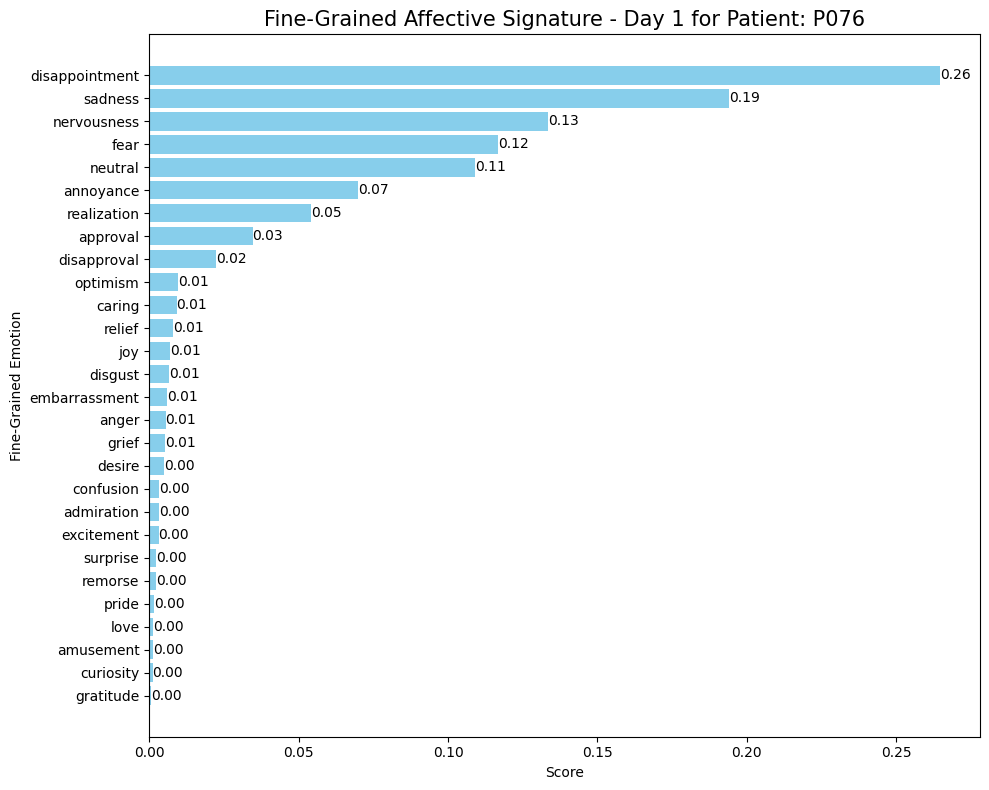

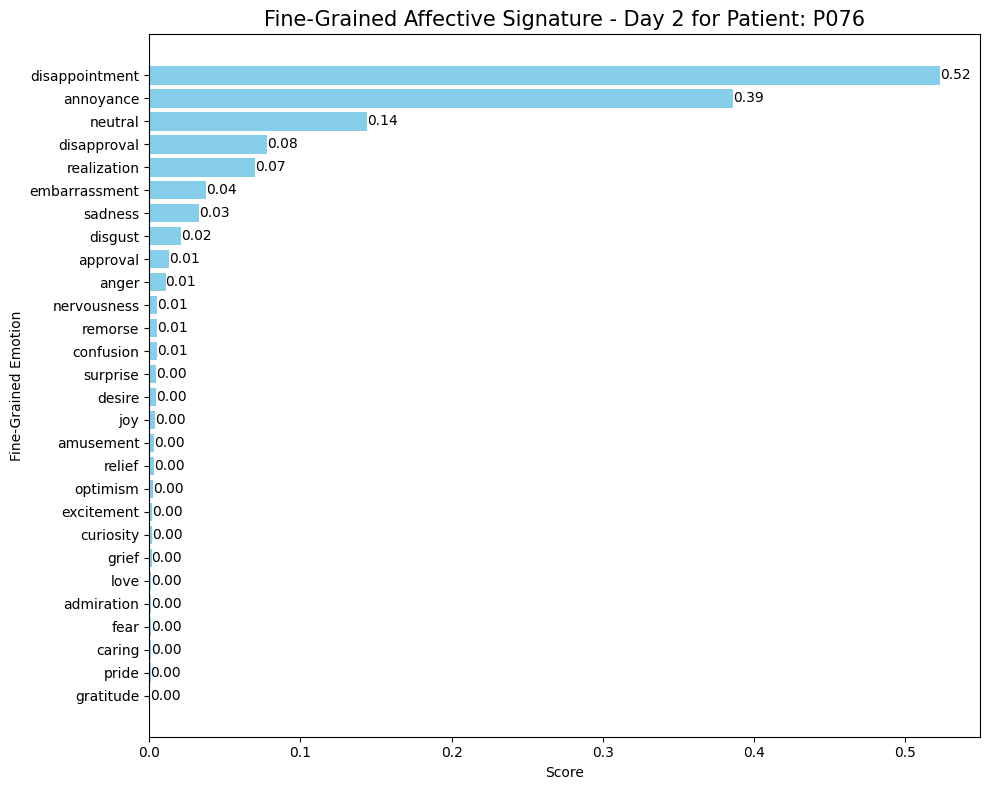

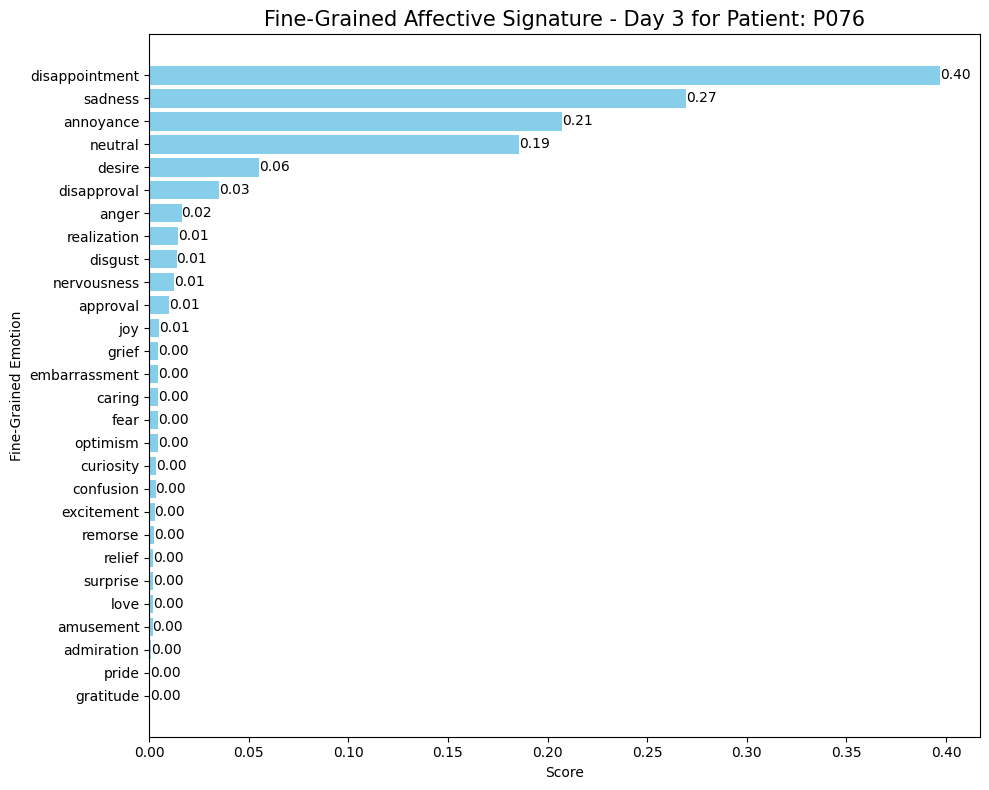

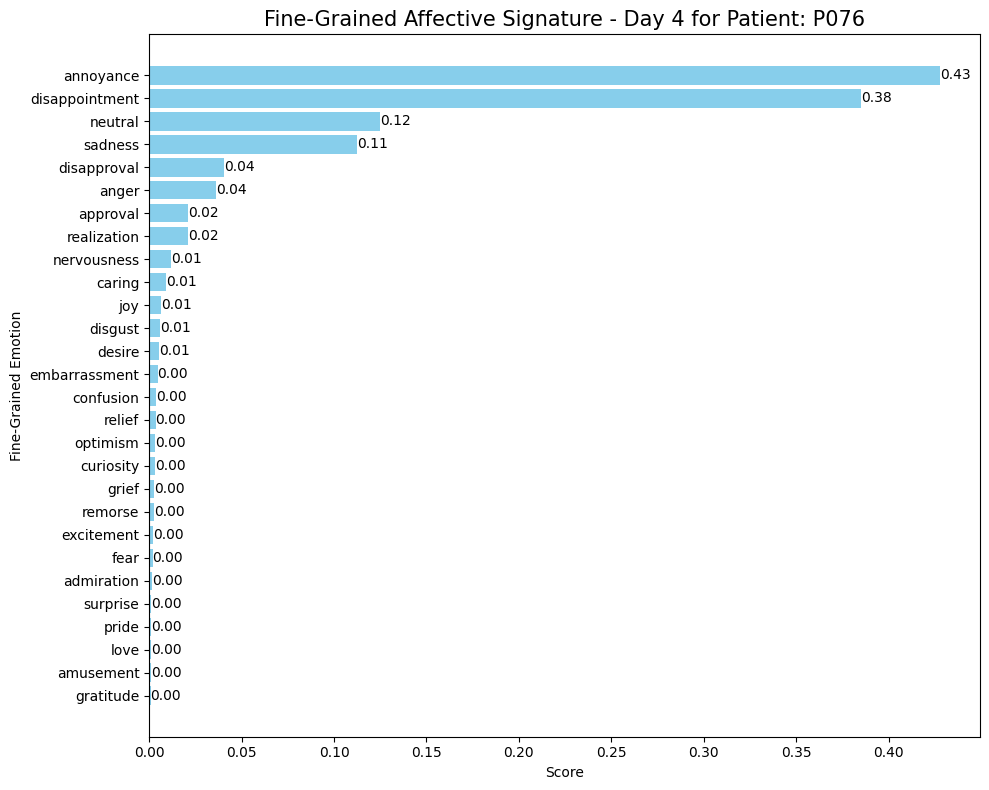

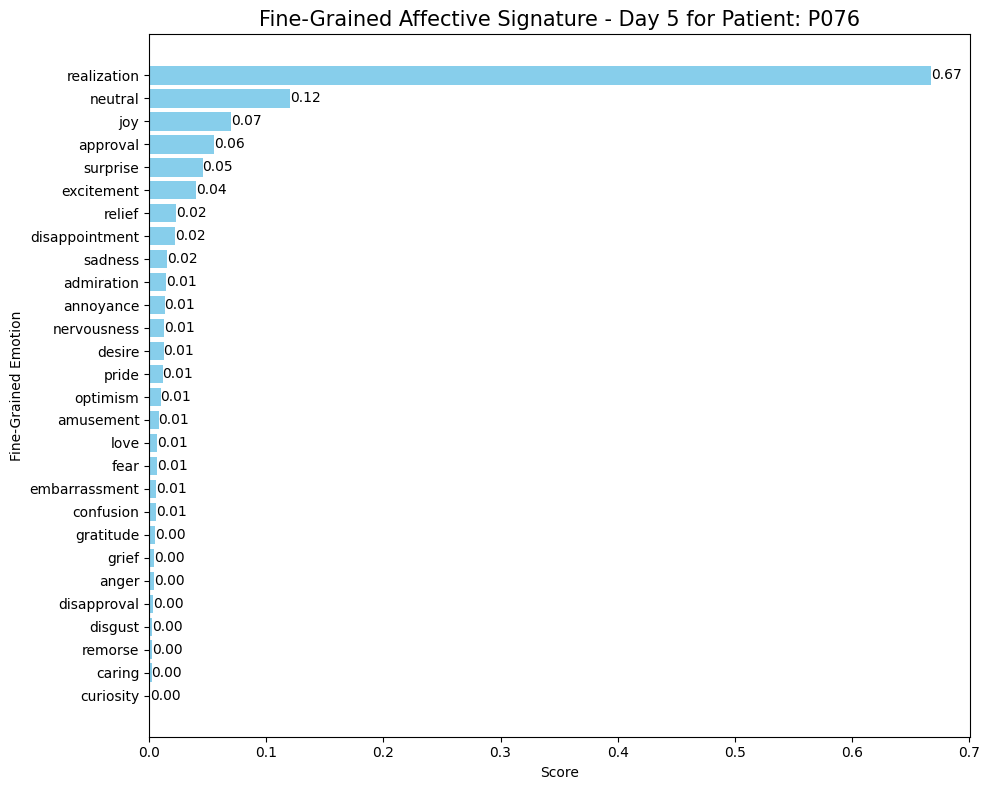

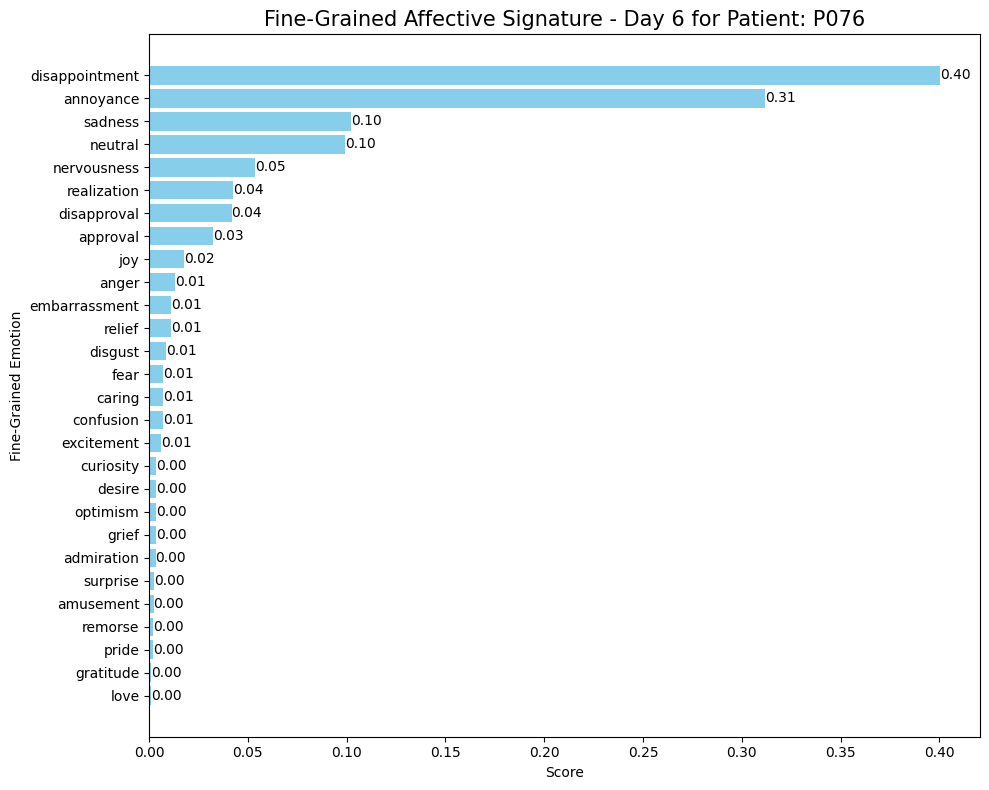

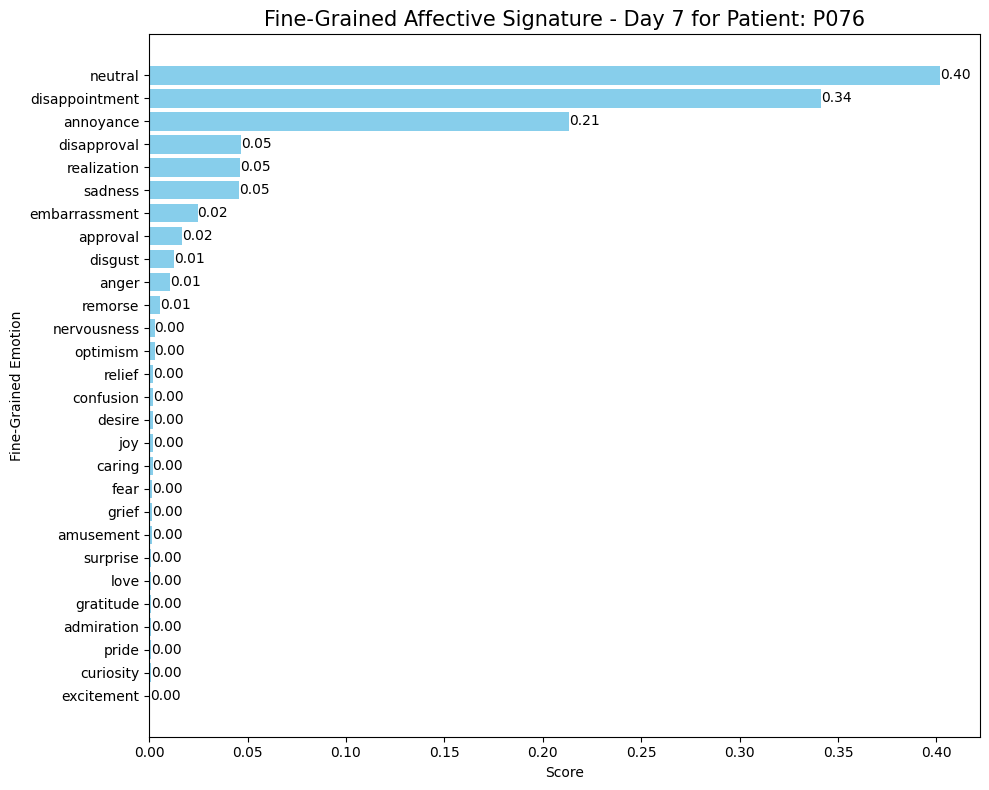

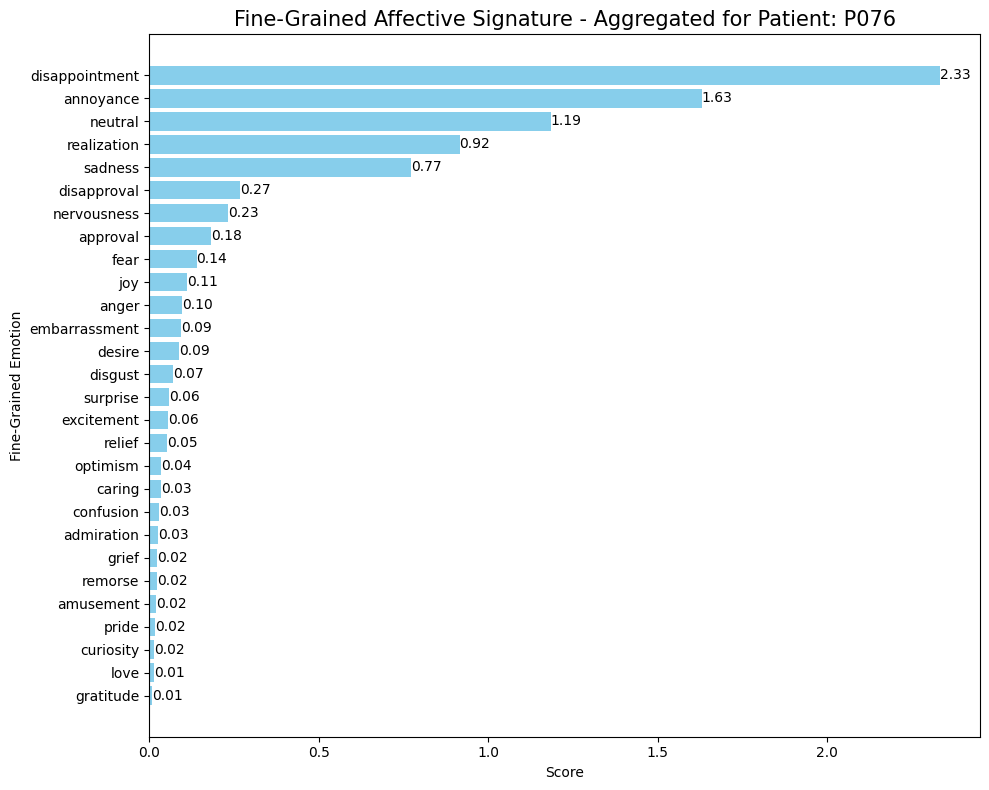

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_radar_chart_from_scores(scores_dict, patient_id, title_prefix="Fine-Grained Affective Signature"):
    # Sort categories alphabetically for consistent plotting order
    categories = sorted(list(scores_dict.keys()))
    values = [scores_dict[cat] for cat in categories]

    # Close the circle (bring the first value to the end)
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Draw the line and fill the area
    ax.fill(angles, values, color='red', alpha=0.25)
    ax.plot(angles, values, color='red', linewidth=2)

    # Set labels
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9) # Adjusted font size for more categories

    # Set y-axis limits dynamically based on scores, ensuring non-negative range
    max_val = max(values) if values else 1.0
    ax.set_ylim(0, max_val * 1.1) # Ensure some padding above max value

    # Dynamically set y-tick labels for better readability
    num_ticks = 5
    if max_val > 0: # Avoid division by zero if all scores are 0
        yticks = np.linspace(0, max_val * 1.1, num_ticks)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{y:.2f}' for y in yticks], fontsize=8)
    else:
        ax.set_yticks([0])
        ax.set_yticklabels(['0.00'], fontsize=8)

    plt.title(f"{title_prefix} for Patient: {patient_id}", size=15, color='black', y=1.1)
    plt.show()

def plot_fine_grained_bar_chart(scores_dict, patient_id, title_prefix="Fine-Grained Affective Signature"):
    # Convert dictionary to DataFrame for easy sorting and plotting
    # Filter out emotions with zero score to avoid clutter in the plot unless explicitly needed
    filtered_scores_dict = {k: v for k, v in scores_dict.items() if v > 0}

    if not filtered_scores_dict:
        print(f"No fine-grained emotional scores detected for {title_prefix} for Patient '{patient_id}'.")
        return

    df_scores = pd.DataFrame(list(filtered_scores_dict.items()), columns=['Emotion', 'Score'])

    # Sort emotions by score in ascending order
    df_scores = df_scores.sort_values(by='Score', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8)) # Adjust figure size for readability

    # Create horizontal bar chart
    bars = ax.barh(df_scores['Emotion'], df_scores['Score'], color='skyblue')

    # Add scores as labels on the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

    ax.set_xlabel('Score')
    ax.set_ylabel('Fine-Grained Emotion')
    ax.set_title(f"{title_prefix} for Patient: {patient_id}", size=15, color='black')

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()
    plt.show()

# --- Code to plot fine-grained emotions for a specific patient, both daily and aggregated ---
patient_id_to_plot = 'P076' # Patient ID as requested

# Full list of 28 fine-grained emotions from the GoEmotions dataset
# as returned by the SamLowe/roberta-base-go_emotions model
all_go_emotions_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Initialize a dictionary to aggregate fine-grained scores across all days
# This ensures all 28 fine-grained emotions are covered.
aggregated_fine_grained_scores = {label: 0.0 for label in all_go_emotions_labels}

# Retrieve patient's journal entries from df_patient_journals
single_patient_df = df_patient_journals[df_patient_journals['patient_id'] == patient_id_to_plot]

if not single_patient_df.empty:
    patient_row = single_patient_df.iloc[0]

    # --- Plot daily fine-grained emotions ---
    for i in range(1, 8): # Iterate through Day 1 to Day 7
        day_col = f'day_{i}'
        journal_entry = patient_row[day_col]

        # Get Ekman and fine-grained scores for the current day's entry
        _, fine_grained_scores_today = get_ekman_score_for_text(journal_entry, classifier, EKMAN_MAPPING)

        # Ensure all 28 fine-grained emotions are represented, even if with 0 score
        full_day_fine_grained_scores = {label: fine_grained_scores_today.get(label, 0.0) for label in all_go_emotions_labels}

        # Plot the bar chart for fine-grained emotions for the current day
        plot_fine_grained_bar_chart(full_day_fine_grained_scores, patient_id_to_plot,
                                    title_prefix=f"Fine-Grained Affective Signature - Day {i}")

        # Aggregate fine-grained scores for the overall chart
        for fg_label, fg_score in fine_grained_scores_today.items():
            if fg_label in aggregated_fine_grained_scores:
                aggregated_fine_grained_scores[fg_label] += fg_score
            else:
                print(f"Warning: Unknown fine-grained emotion label '{fg_label}' encountered. Adding it to the aggregation.")
                aggregated_fine_grained_scores[fg_label] = fg_score # Initialize and add score if new

    # --- Plot aggregated fine-grained emotions (after iterating through all days) ---
    plot_fine_grained_bar_chart(aggregated_fine_grained_scores, patient_id_to_plot,
                                title_prefix="Fine-Grained Affective Signature - Aggregated")
else:
    print(f"Patient '{patient_id_to_plot}' not found in df_patient_journals. Please check the patient ID.")

This cell defines a helper function `calculate_features` to compute the mean, standard deviation (volatility), and linear regression slope for a list of scores over time. It then defines `generate_emotional_features` to apply this logic to each patient's daily Ekman emotion scores across the week. This generates a new DataFrame (`df_emotional_features`) containing these calculated features for all patients, which will be used for downstream machine learning tasks, and displays the first few rows.

In [ ]:
from scipy.stats import linregress
from tqdm.notebook import tqdm

# Helper function to calculate mean, volatility (std), and slope
def calculate_features(scores_list):
    mean_val = np.mean(scores_list)
    std_val = np.std(scores_list) # Volatility (Standard Deviation)

    # Calculate slope (trend) using linear regression
    days = np.arange(1, 8) # Days 1 to 7
    # Ensure enough data points for regression, though with 7 days it should always be sufficient
    if len(scores_list) < 2:
        slope = 0.0 # Cannot calculate slope with less than 2 points
    else:
        slope, _, _, _, _ = linregress(days, scores_list)
    return mean_val, std_val, slope

def generate_emotional_features(df_patient_journals, classifier, EKMAN_MAPPING):
    # Initialize a list to store processed data for all patients
    processed_patients_data = []

    # Iterate through each patient in the df_patient_journals (correcting from df_static_dataset)
    for idx, row in tqdm(df_patient_journals.iterrows(), total=len(df_patient_journals), desc="Processing Patients for Features"):
        # Use 'patient_id' and 'diagnosis' from df_patient_journals
        patient_features = {'Patient_ID': row['patient_id'], 'Final_Diagnosis': row['diagnosis']}

        # Store daily Ekman scores for this patient before calculating aggregates
        # This will be a dictionary where keys are Ekman emotions and values are lists of 7 scores
        patient_daily_ekman_scores = {cat: [] for cat in EKMAN_MAPPING.keys()}

        # Process each day's journal entry
        for day in range(1, 8):
            text_entry = row[f'day_{day}']

            # Get Ekman scores for the current day's text (handles NaN/empty by returning 0s)
            current_day_ekman_scores, _ = get_ekman_score_for_text(text_entry, classifier, EKMAN_MAPPING)

            # Append scores to their respective emotion history for this patient
            for emo_cat, score in current_day_ekman_scores.items():
                patient_daily_ekman_scores[emo_cat].append(score)

        # Mean, Volatility (Std), and Slope for each Ekman emotion for this patient
        for emo in EKMAN_MAPPING.keys():
            scores_for_emotion = patient_daily_ekman_scores[emo]

            # calculate_features expects 7 scores, which get_ekman_score_for_text ensures.
            mean, std, slope = calculate_features(scores_for_emotion)

            patient_features[f'{emo}_Mean'] = mean
            patient_features[f'{emo}_Volatility'] = std
            patient_features[f'{emo}_Slope'] = slope

        processed_patients_data.append(patient_features)

    # Create the final DataFrame with engineered features
    df_emotional_features = pd.DataFrame(processed_patients_data)
    return df_emotional_features

# Call the function to generate the emotional features DataFrame
df_emotional_features = generate_emotional_features(df_patient_journals, classifier, EKMAN_MAPPING)

pd.options.display.float_format = '{:.4f}'.format

print("\nEmotional feature engineering complete. Displaying the first 5 rows of the emotional feature DataFrame:")
display(df_emotional_features.head())

Processing Patients for Features:   0%|          | 0/300 [00:00<?, ?it/s]


Emotional feature engineering complete. Displaying the first 5 rows of the emotional feature DataFrame:


,Patient_ID,Final_Diagnosis,Anger_Mean,Anger_Volatility,Anger_Slope,Disgust_Mean,Disgust_Volatility,Disgust_Slope,Fear_Mean,Fear_Volatility,...,Joy_Slope,Sadness_Mean,Sadness_Volatility,Sadness_Slope,Surprise_Mean,Surprise_Volatility,Surprise_Slope,Neutral_Mean,Neutral_Volatility,Neutral_Slope
0,P001,Burnout,0.1777,0.1605,-0.0166,0.0069,0.0024,-0.0005,0.0976,0.1734,...,0.0516,0.2584,0.2110,-0.0010,0.0590,0.0382,-0.0019,0.1848,0.1247,-0.0284
1,P002,Healthy,0.0863,0.1637,0.0367,0.0020,0.0015,0.0006,0.0306,0.0482,...,-0.0426,0.0677,0.0703,0.0283,0.0694,0.0515,0.0071,0.0985,0.0878,-0.0181
2,P003,Depression,0.2514,0.1834,-0.0191,0.0103,0.0046,-0.0015,0.0403,0.0524,...,0.1326,0.4925,0.2818,-0.0831,0.0784,0.1075,0.0092,0.1179,0.0896,-0.0385
3,P004,Anxiety,0.3130,0.2750,-0.0510,0.0085,0.0032,-0.0014,0.0991,0.1239,...,0.0017,0.3491,0.0868,-0.0013,0.1781,0.1611,0.0137,0.1833,0.1003,0.0122
4,P005,PTSD,0.2734,0.3628,-0.0589,0.0115,0.0066,-0.0012,0.2992,0.4290,...,0.0081,0.3699,0.2080,0.0614,0.0969,0.0791,0.0034,0.1176,0.0716,-0.0078


This code block defines `generate_patient_emotional_drift_plot`, a Plotly function that visualizes a patient's emotional journey over seven days. It creates two subplots: a scatter plot showing the dominant Ekman emotions changing daily, and a table summarizing detailed emotional scores. The function is designed to return a Plotly figure object, which is then tested and displayed for Patient 'P001'.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def generate_patient_emotional_drift_plot(df_patient_data: pd.DataFrame):
    # 1. Initialization of Visual Components
    # Defines a consistent color map for the seven basic Ekman emotions, ensuring visual
    # coherence across different plots. Each emotion is assigned a distinct color for clarity.
    ekman_color_map = {
        'Anger': 'red', 'Disgust': 'purple', 'Fear': 'orange',
        'Joy': 'green', 'Sadness': 'blue', 'Surprise': 'yellow',
        'Neutral': 'gray'
    }

    figures = []

    # 2. Iteration Through Patient Data
    # The function iterates through each row of the input DataFrame, treating each row
    # as a distinct patient's emotional analysis record. This allows for individual
    # plot generation per patient.
    for idx, row in df_patient_data.iterrows():
        patient_id = row['patient_id']
        diagnosis = row['diagnosis']

        # Lists to store daily emotional data points. These lists are populated
        # dynamically from the DataFrame row for each patient.
        daily_ekman_emotions = []
        daily_fine_grained_emotions_parsed = []  # Stores list of (emotion, score) tuples
        daily_ekman_scores = []  # Stores numeric Ekman scores

        # 3. Daily Data Extraction and Parsing
        # This loop processes the emotional data for each of the seven days for the current patient.
        for d in range(1, 8):
            # Extracts the dominant Ekman emotion label for the specific day.
            ekman_label = row[f'Day_{d}_Ekman']
            # Extracts the numerical score associated with the dominant Ekman emotion.
            ekman_score = row[f'Day_{d}_Ekman_Score']
            # Retrieves the string containing fine-grained emotions and their scores.
            fine_grained_str = row[f'Day_{d}_FineGrained']

            # Appends the extracted Ekman label and score to their respective daily lists.
            daily_ekman_emotions.append(ekman_label)
            daily_ekman_scores.append(float(ekman_score)) # Ensure score is float for plotting/analysis

            # Parses the fine-grained emotion string into a structured list of (emotion, score) tuples.
            # This involves splitting the string and converting scores to float.
            parsed_day_fine_grained = []
            if fine_grained_str:
                pairs = fine_grained_str.split(', ')
                for pair in pairs:
                    if ': ' in pair:
                        emotion, score_str = pair.split(': ')
                        parsed_day_fine_grained.append((emotion.strip(), float(score_str.strip())))
            daily_fine_grained_emotions_parsed.append(parsed_day_fine_grained)

        # 4. Figure and Subplot Initialization
        # Initializes a Plotly figure with two subplots: an XY plot for emotional drift
        # and a table for detailed emotional scores. Subplot titles are dynamically set.
        fig = make_subplots(rows=2, cols=1,
                            subplot_titles=(
                                f'Emotional Drift for Patient {patient_id} - Dominant Ekman Emotions',
                                f'Emotional Scores Summary for Patient {patient_id}')
                            ,
                            vertical_spacing=0.1,
                            specs=[[{'type': 'xy'}], [{'type': 'table'}]])

        # Generates labels for the days (e.g., 'Day 1', 'Day 2') for the x-axis.
        days = [f'Day {d}' for d in range(1, 8)]

        # Retrieves colors for each day's dominant Ekman emotion from the predefined map.
        ekman_colors_for_plot = [ekman_color_map.get(e, 'black') for e in daily_ekman_emotions]

        # 5. Subplot 1: Dominant Ekman Emotions (Scatter Plot)
        # Adds a scatter plot trace to the first subplot, illustrating the progression of
        # dominant Ekman emotions over the seven days. Markers are colored according to emotion.
        fig.add_trace(go.Scatter(
            x=days,
            y=daily_ekman_emotions,  # Plots the Ekman label as categorical Y-axis
            mode='lines+markers',
            name='Dominant Ekman Emotion',
            marker=dict(size=12, color=ekman_colors_for_plot, line=dict(width=1, color='DarkSlateGrey')),
            line=dict(width=3),
            hoverinfo='text',
            # Custom hover text displays Day, Dominant Ekman emotion, and its corresponding score.
            hovertext=[f'Day: {d}<br>Dominant Ekman: {e}<br>Ekman Score: {s}' for d, e, s in zip(days, daily_ekman_emotions, daily_ekman_scores)]
        ), row=1, col=1)

        # Configures the y-axis for the scatter plot to display Ekman emotions as ordered categories,
        # ensuring a consistent and readable presentation. Grid lines are hidden for a cleaner look.
        fig.update_yaxes(title_text='Dominant Ekman Emotion', row=1, col=1,
                         categoryorder='array', categoryarray=list(ekman_color_map.keys()),
                         showgrid=False)
        # Sets the title for the x-axis of the scatter plot.
        fig.update_xaxes(title_text='Day', row=1, col=1)

        # 6. Subplot 2: Emotional Scores Summary (Table)
        # Defines the maximum number of fine-grained emotions to display per day in the table,
        # based on previous analysis (e.g., top 3).
        max_fine_grained_per_day = 3

        # Constructs the table headers, including 'Day', 'Dominant Ekman', 'Ekman Score',
        # and dynamically generated headers for fine-grained emotions and their scores.
        table_headers = ['Day', 'Dominant Ekman', 'Ekman Score']
        for i in range(1, max_fine_grained_per_day + 1):
            table_headers.extend([f'Fine-Grained Emotion {i}', f'Score {i}'])

        # Populates the rows of the table with data extracted for each day. It includes
        # the dominant Ekman emotion, its score, and the top fine-grained emotions.
        table_data_rows = []
        for d_idx, day_label in enumerate(days):
            row_data = [day_label,
                        daily_ekman_emotions[d_idx],
                        f'{daily_ekman_scores[d_idx]:.2f}'] # Format score to 2 decimal places

            day_fine_grained_emotions_scores = daily_fine_grained_emotions_parsed[d_idx]
            # Fills in fine-grained emotion data, padding with empty strings if fewer
            # than `max_fine_grained_per_day` emotions are available.
            for i in range(max_fine_grained_per_day):
                if i < len(day_fine_grained_emotions_scores):
                    emotion, score = day_fine_grained_emotions_scores[i]
                    row_data.extend([emotion, f'{score:.2f}'])
                else:
                    row_data.extend(['', ''])
            table_data_rows.append(row_data)

        # Transposes the `table_data_rows` to fit Plotly's `go.Table` format, which expects
        # each list within `values` to represent a column rather than a row.
        cell_values_for_table = list(map(list, zip(*table_data_rows)))

        # Adds the table trace to the second subplot, defining header and cell styles for readability.
        fig.add_trace(go.Table(
            header=dict(values=table_headers,
                        fill_color='paleturquoise',
                        align='left',
                        font=dict(size=12, color='black'),
                        height=30),
            cells=dict(values=cell_values_for_table,
                       fill_color='lavender',
                       align='left',
                       font=dict(size=10, color='black'),
                       height=30)
        ), row=2, col=1)

        # 7. Global Figure Layout Configuration
        # Updates the overall layout of the figure, setting its height, centering the title,
        # enabling 'x unified' hover mode for interactive data exploration, and applying
        # aesthetic improvements to fonts and background colors for a professional appearance.
        fig.update_layout(height=900, showlegend=False,
                          title_text=f'Emotional Analysis for Patient {patient_id}',
                          title_x=0.5,
                          hovermode="x unified",
                          font=dict(family="Arial, sans-serif", size=12, color="RebeccaPurple"),
                          plot_bgcolor='white',
                          paper_bgcolor='white'
                         )
        figures.append(fig)

    if len(figures) == 1:
        return figures[0]
    return figures

# Test case for Patient P001:
# 1. Filtering Data for P001:
#    Filters the `df_emotional_analysis` DataFrame to include only the record
#    corresponding to 'P001'. This prepares the specific data required for the test.
patient_p001_df = df_emotional_analysis[df_emotional_analysis['patient_id'] == 'P001'].copy()

# 2. Function Call and Display:
#    Calls the `generate_patient_emotional_drift_plot` function with the filtered
#    DataFrame. Since it's a single patient, the function returns a single Plotly
#    figure object. This figure is then displayed using `fig.show()` for demonstration
#    within a non-Streamlit environment.
if not patient_p001_df.empty:
    fig_p001 = generate_patient_emotional_drift_plot(patient_p001_df)
    if isinstance(fig_p001, go.Figure):
        fig_p001.show()
    else:
        # In case the function returns a list (e.g., if df_patient_data somehow had multiple rows despite filtering for 'P001')
        for f in fig_p001:
            f.show()
else:
    print("Patient 'P001' not found in df_emotional_analysis.")

This cell analyzes the distribution of `Final_Diagnosis` in `df_emotional_features`. It prints the counts for each diagnosis and visualizes this distribution using both a bar plot and a pie chart. It also calculates and prints the class imbalance ratio to assess if any diagnosis is underrepresented, which is important for model training.

--- Distribution of Patient Diagnoses ---
Final_Diagnosis
Burnout       50
Healthy       50
Depression    50
Anxiety       50
PTSD          50
ADHD          50
Name: count, dtype: int64


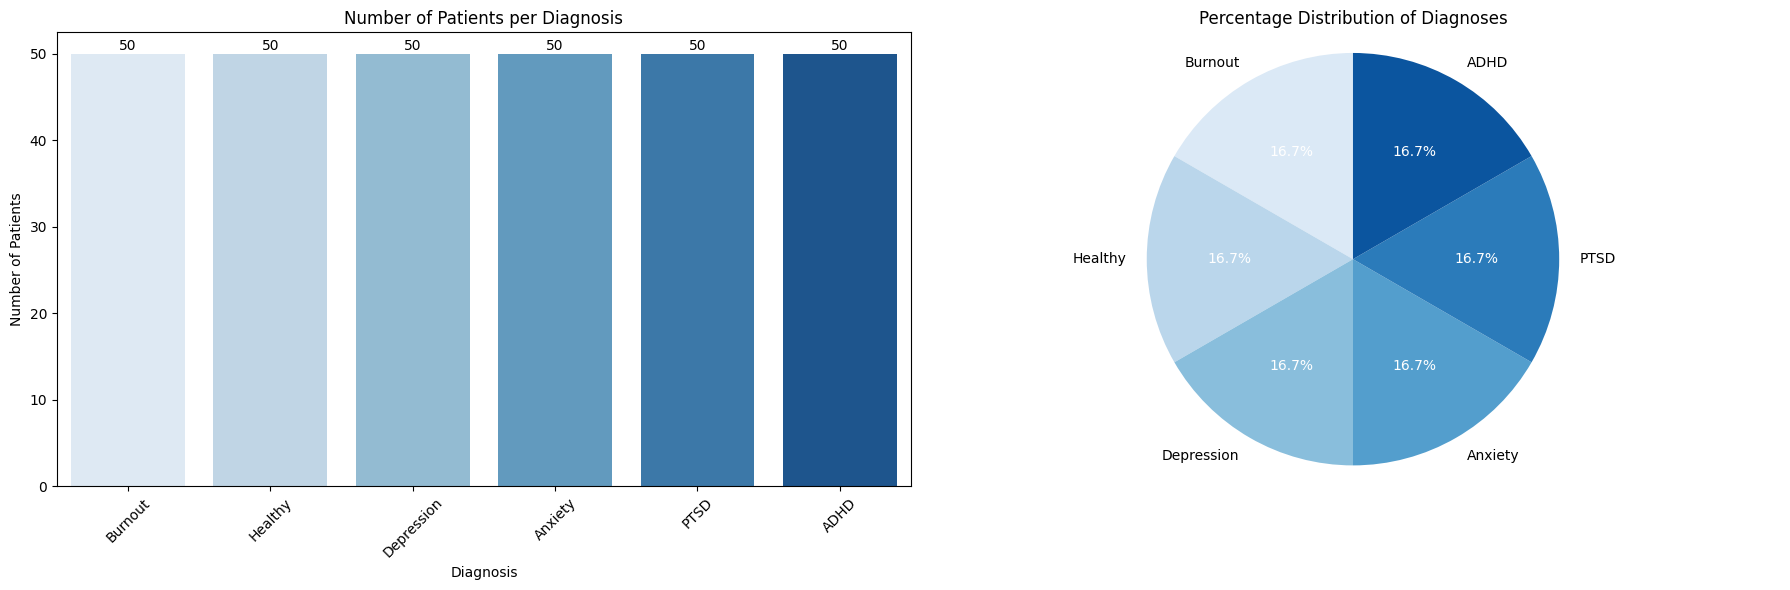


Class Imbalance Ratio (Minority:Majority) = 1.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the value counts for the 'Final_Diagnosis' column
diagnosis_counts = df_emotional_features['Final_Diagnosis'].value_counts()

print("--- Distribution of Patient Diagnoses ---")
print(diagnosis_counts)

# Create a figure with two subplots for the bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Bar Plot ---
# Visualize the distribution using a bar plot
sns.barplot(x=diagnosis_counts.index, y=diagnosis_counts.values, palette='Blues', ax=axes[0], hue=diagnosis_counts.index, legend=False)
axes[0].set_title('Number of Patients per Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

# Add numbers (counts) on top of the bars
for index, value in enumerate(diagnosis_counts.values):
    axes[0].text(index, value + 0.1, str(value), ha='center', va='bottom') # Adjust +0.1 for padding

# --- Pie Chart ---
# Calculate percentages for the pie chart
diagnosis_percentages = diagnosis_counts / diagnosis_counts.sum() * 100

# Plot the pie chart
wedges, texts, autotexts = axes[1].pie(diagnosis_percentages,
                                      labels=diagnosis_counts.index,
                                      autopct='%1.1f%%', # Format percentage with one decimal place
                                      startangle=90,
                                      colors=sns.color_palette('Blues', len(diagnosis_counts)))

axes[1].set_title('Percentage Distribution of Diagnoses')
axes[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Ensure percentages are visible
for autotext in autotexts:
    autotext.set_color('white') # Set color for better contrast if needed

plt.tight_layout()
plt.show()

# Calculate and display the ratio of minority to majority class for imbalance assessment
if not diagnosis_counts.empty:
    majority_class_count = diagnosis_counts.max()
    minority_class_count = diagnosis_counts.min()
    if majority_class_count > 0:
        imbalance_ratio = minority_class_count / majority_class_count
        print(f"\nClass Imbalance Ratio (Minority:Majority) = {imbalance_ratio:.2f}")
        if imbalance_ratio < 0.5:
            print("This indicates a significant class imbalance that might need to be addressed, for example, using techniques like oversampling, undersampling, or adjusting class weights in model training.")
    else:
        print("Cannot calculate imbalance ratio: No classes found.")
else:
    print("No diagnosis data available for imbalance analysis.")

This code block prepares the dataset for machine learning by splitting it into training, validation, and test sets using a 70%/15%/15% ratio. It defines features (`X`) and the target variable (`y`), encodes `y` using `LabelEncoder`, and ensures class distribution is maintained across splits using `stratify`. It then prints the shapes and class distributions of the resulting sets, along with an explanation of the `train_test_split` parameters.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
# Import pandas for pd.Series in print statement

# Define features (X) and target (y)
X = df_emotional_features.drop(['Patient_ID', 'Final_Diagnosis'], axis=1) # Exclude IDs and the target from features
y = df_emotional_features['Final_Diagnosis']

# Encode the categorical target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# First, split into training (70%) and a temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y_encoded)

# Then, split the temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
                                                test_size=0.5,
                                                random_state=42,
                                                stratify=y_temp)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"\nDistribution of classes in y_train:\n{pd.Series(label_encoder.inverse_transform(y_train)).value_counts(normalize=True)}")
print(f"\nDistribution of classes in y_val:\n{pd.Series(label_encoder.inverse_transform(y_val)).value_counts(normalize=True)}")
print(f"\nDistribution of classes in y_test:\n{pd.Series(label_encoder.inverse_transform(y_test)).value_counts(normalize=True)}")

# Explanation of train_test_split parameters:
# 1. test_size: This parameter specifies the proportion of the dataset to be allocated to the test set.
#    In the first split (X_train, X_temp), `test_size=0.3` means 30% of the original data is assigned to X_temp (and y_temp),
#    while the remaining 70% is used for training (X_train, y_train).
#    In the second split (X_val, X_test), `test_size=0.5` is applied to `X_temp` and `y_temp`.
#    This effectively splits the 30% temporary set into two equal halves, resulting in 15% for the validation set
#    and 15% for the test set from the original dataset.
#    This creates a 70%/15%/15% split for training, validation, and testing, respectively.

# 2. random_state: This parameter controls the shuffling applied to the data before splitting.
#    Providing an integer value (e.g., `random_state=42`) ensures that the shuffling is deterministic.
#    Consequently, every time the code is executed with the same `random_state`, the data is split in precisely the same way.
#    This determinism is crucial for reproducibility of experiments, allowing consistent comparison of different models
#    or hyperparameter settings.

# 3. stratify: This parameter receives an array-like object (typically the target variable `y_encoded` or `y_temp`).
#    When `stratify` is set, the data is split in a way that maintains the same proportion of classes in each split (training, validation, test) as in the original dataset.
#    For example, if the original dataset has 20% class A and 80% class B, each of the resulting subsets (train, val, test) will also approximate this 20%/80% distribution.
#    This is particularly important in classification tasks, especially with imbalanced datasets, to prevent any subset from having a disproportionate representation of certain classes, which could lead to biased model training or evaluation.

Shape of X_train: (210, 21)
Shape of X_val: (45, 21)
Shape of X_test: (45, 21)

Distribution of classes in y_train:
Burnout      0.1667
ADHD         0.1667
Healthy      0.1667
Depression   0.1667
PTSD         0.1667
Anxiety      0.1667
Name: proportion, dtype: float64

Distribution of classes in y_val:
Anxiety      0.1778
ADHD         0.1778
PTSD         0.1778
Burnout      0.1556
Depression   0.1556
Healthy      0.1556
Name: proportion, dtype: float64

Distribution of classes in y_test:
Depression   0.1778
Burnout      0.1778
Healthy      0.1778
PTSD         0.1556
Anxiety      0.1556
ADHD         0.1556
Name: proportion, dtype: float64


This cell initializes a `RandomForestClassifier` with `n_estimators=100`, `random_state=42` for reproducibility, and `class_weight='balanced'` to handle potential class imbalances. This model will serve as the baseline for classifying patient diagnoses based on the emotional features, and a message confirms its initialization for hyperparameter tuning.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# This model will be used for classifying patient diagnoses based on emotional features.
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest. More trees generally improve robustness but increase computation.
    random_state=42,   # Ensures reproducibility of the random processes (e.g., sample selection, feature selection).
                       # Using a fixed integer like 42 means the results will be the same every time the code is run.
    class_weight='balanced' # Automatically adjusts weights inversely proportional to class frequencies.
                            # This is particularly useful for imbalanced datasets, giving more importance to minority classes
                            # to prevent bias towards majority classes.
)

print("Random Forest model initialized for hyperparameter tuning.")

Random Forest model initialized for hyperparameter tuning.


This code block trains the `rf_model` on the `X_train` and `y_train` datasets and then evaluates its performance on both the validation and test sets. It calculates and prints the accuracy and a detailed classification report, and visualizes the results using confusion matrices for both sets. This provides a baseline understanding of the unoptimized model's diagnostic capabilities.


--- Evaluating Unoptimized Model on Validation Set ---

Model accuracy on the validation set: 0.5778

Classification report on the validation set:
              precision    recall  f1-score   support

        ADHD       0.86      0.75      0.80         8
     Anxiety       0.40      0.75      0.52         8
     Burnout       0.25      0.14      0.18         7
  Depression       0.75      0.43      0.55         7
     Healthy       0.88      1.00      0.93         7
        PTSD       0.43      0.38      0.40         8

    accuracy                           0.58        45
   macro avg       0.59      0.57      0.56        45
weighted avg       0.59      0.58      0.56        45


Confusion Matrix on the validation set:


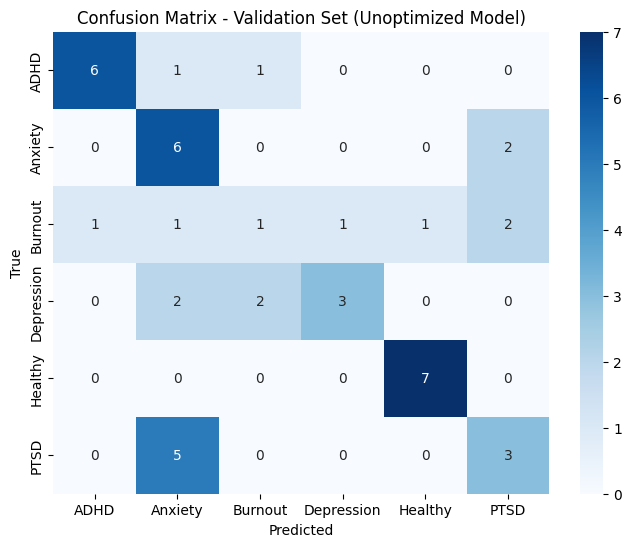


--- Evaluating Unoptimized Model on Test Set ---

Model accuracy on the test set: 0.5778

Classification Report (Test Set - Unoptimized Model):
              precision    recall  f1-score   support

        ADHD       0.67      0.57      0.62         7
     Anxiety       0.42      0.71      0.53         7
     Burnout       0.50      0.50      0.50         8
  Depression       0.50      0.25      0.33         8
     Healthy       1.00      1.00      1.00         8
        PTSD       0.43      0.43      0.43         7

    accuracy                           0.58        45
   macro avg       0.59      0.58      0.57        45
weighted avg       0.59      0.58      0.57        45


Confusion Matrix (Test Set - Unoptimized Model):


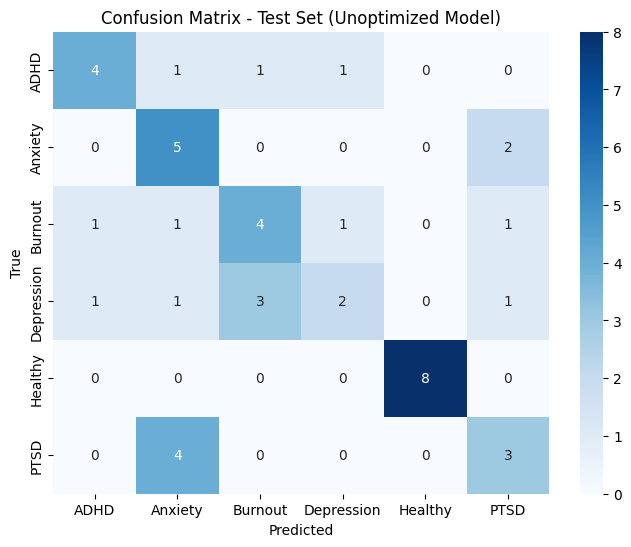

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Metrics for model evaluation
import matplotlib.pyplot as plt # Library for creating static, interactive, and animated visualizations
import seaborn as sns # Data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics

# Train the Random Forest model
# The .fit() method trains the model using the provided training data (X_train) and their corresponding labels (y_train).
# X_train contains the features, and y_train contains the target diagnoses for the training set.
rf_model.fit(X_train, y_train)


# --- Evaluation on the Validation Set ---
print("\n--- Evaluating Unoptimized Model on Validation Set ---")

# Predict on the validation set
# The .predict() method uses the trained model to make predictions on new, unseen data (X_val).
# X_val contains the features of the validation set, and y_val_pred will store the model's predicted diagnoses.
y_val_pred = rf_model.predict(X_val)

# Evaluate performance on the validation set
# Calculate the accuracy of the model on the validation set.
# accuracy_score compares the true labels (y_val) with the predicted labels (y_val_pred).
val_accuracy = accuracy_score(y_val, y_val_pred)

# Generate a classification report, which includes precision, recall, f1-score, and support for each class.
# target_names are used to display human-readable class labels in the report.
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_)

# Compute the confusion matrix, which shows the number of correct and incorrect predictions made by the classifier.
# Each row represents the instances in an actual class, while each column represents the instances in a predicted class.
val_cm = confusion_matrix(y_val, y_val_pred)

# Print the calculated accuracy.
print(f"\nModel accuracy on the validation set: {val_accuracy:.4f}")

# Print the full classification report.
print("\nClassification report on the validation set:")
print(val_report)

# Display the confusion matrix visually using a heatmap.
print("\nConfusion Matrix on the validation set:")
plt.figure(figsize=(8, 6)) # Set the size of the plot

# Create a heatmap of the confusion matrix.
# annot=True displays the actual numbers in each cell.
# fmt='d' formats the numbers as integers.
# cmap='Blues' sets the color scheme.
# xticklabels and yticklabels set the labels for the predicted and true classes, respectively.
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix - Validation Set (Unoptimized Model)') # Set the title of the plot
plt.xlabel('Predicted') # Label for the x-axis
plt.ylabel('True') # Label for the y-axis
plt.show() # Display the plot


# --- Evaluation on the Test Set (Unoptimized Model) ---
print("\n--- Evaluating Unoptimized Model on Test Set ---")

# Predict on the test set using the unoptimized model
y_test_pred = rf_model.predict(X_test)

# Evaluate performance on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_)
test_cm = confusion_matrix(y_test, y_test_pred)

print(f"\nModel accuracy on the test set: {test_accuracy:.4f}")
print("\nClassification Report (Test Set - Unoptimized Model):")
print(test_report)

print("\nConfusion Matrix (Test Set - Unoptimized Model):")
plt.figure(figsize=(8, 6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Test Set (Unoptimized Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This text cell indicates that the next step is to evaluate the performance of the **optimized** model (`rf_model_tuned`) on the validation set.

This code block initializes `GridSearchCV` to perform hyperparameter tuning for the `RandomForestClassifier`. It defines a `param_grid` with various values for `n_estimators`, `max_depth`, and `min_samples_split`. It uses `StratifiedKFold` for 5-fold cross-validation, `accuracy` as the scoring metric, and parallelizes computation (`n_jobs=-1`). After running the grid search on the training data, it prints the best parameters and the best accuracy score found, and saves the optimized model as `rf_model_tuned`.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold # Import GridSearchCV for hyperparameter search and StratifiedKFold for stratified cross-validation

# Define the parameter grid for GridSearchCV
# This is a map of the hyperparameters we want to test and their possible values.
param_grid = {
    'n_estimators': [50, 100, 200],  # The number of decision trees in the random forest. A higher number can increase accuracy but also computation time.
    'max_depth': [3, 5, 10, None],   # The maximum depth of each tree. `None` means trees expand until leaves are pure or contain less than `min_samples_split` samples.
    'min_samples_split': [2, 5, 10]  # The minimum number of samples required to split an internal node. This helps control overfitting.
}

# Initialize GridSearchCV
# GridSearchCV will build a model for each combination of parameters in `param_grid`.
# It will evaluate each combination using cross-validation.
grid_search = GridSearchCV(
    estimator=rf_model, # The model we want to optimize (RandomForestClassifier initialized earlier)
    param_grid=param_grid, # The parameter grid to explore
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # Cross-validation strategy. StratifiedKFold maintains class proportions in each split, crucial for imbalanced datasets.
    scoring='accuracy', # The evaluation metric GridSearchCV will use to determine the best parameter combination. Here we use accuracy.
    n_jobs=-1, # Uses all available CPU cores to speed up computation (parallelization).
    verbose=1 # Displays the search progress.
)

print("Starting grid search for the best parameters...")
# Run the grid search on the training set
# This function will train the model multiple times with different parameter combinations and find the best combination.
grid_search.fit(X_train, y_train)

# Display the best parameters and the best score obtained
# `best_params_` returns a dictionary with the best combination of hyperparameters found.
# `best_score_` returns the score (accuracy, in this case) obtained with these optimal parameters during cross-validation.
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best accuracy score obtained: {grid_search.best_score_:.4f}")

# Save the best model
# `best_estimator_` is the model automatically re-trained on the entire training dataset using the best parameters found.
rf_model_tuned = grid_search.best_estimator_

Starting grid search for the best parameters...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy score obtained: 0.5952


This cell evaluates the `rf_model_tuned` (the optimized Random Forest model) on the validation set. It predicts labels, calculates accuracy, generates a classification report, and displays a confusion matrix. This step assesses how well the tuned model performs on unseen data, providing insights into its generalization capabilities before testing on the final test set.


Accuracy of the optimized Random Forest model on the validation set: 0.5556

Classification Report (Optimized Model - Validation Set):
              precision    recall  f1-score   support

        ADHD       0.86      0.75      0.80         8
     Anxiety       0.46      0.75      0.57         8
     Burnout       0.20      0.14      0.17         7
  Depression       0.50      0.29      0.36         7
     Healthy       0.88      1.00      0.93         7
        PTSD       0.38      0.38      0.38         8

    accuracy                           0.56        45
   macro avg       0.54      0.55      0.54        45
weighted avg       0.55      0.56      0.54        45


Confusion Matrix (Optimized Model - Validation Set):


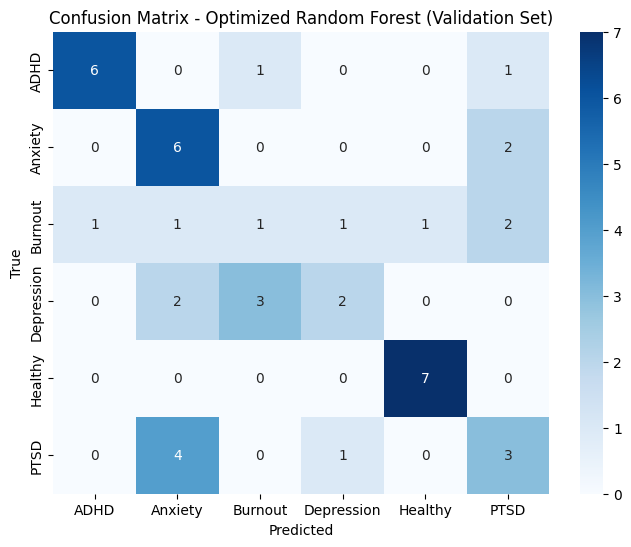

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the validation set using the optimized model
# The optimized model (`rf_model_tuned`) was trained on the entire training set (`X_train`)
# using the best hyperparameters found by GridSearchCV.
# Here, we make predictions on the validation set (`X_val`), which is a completely separate
# and unseen data set during training or hyperparameter search.
y_val_pred_tuned = rf_model_tuned.predict(X_val)

# Evaluate performance on the validation set
# The accuracy calculated here is on the external validation set (`X_val`), not on the internal cross-validation folds of GridSearchCV.
# For this reason, the score may be different (and usually slightly lower) than `grid_search.best_score_`,
# because `grid_search.best_score_` is an average of the performance on the validation folds *within the training set*.
val_accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)
val_report_tuned = classification_report(y_val, y_val_pred_tuned, target_names=label_encoder.classes_)
val_cm_tuned = confusion_matrix(y_val, y_val_pred_tuned)

print(f"\nAccuracy of the optimized Random Forest model on the validation set: {val_accuracy_tuned:.4f}")
print("\nClassification Report (Optimized Model - Validation Set):")
print(val_report_tuned)

print("\nConfusion Matrix (Optimized Model - Validation Set):")
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Optimized Random Forest (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This cell evaluates the `rf_model_tuned` (the optimized Random Forest model) on the test set. It predicts labels, calculates accuracy, generates a classification report, and displays a confusion matrix. This final evaluation provides an unbiased estimate of the model's performance on completely new, unseen data.


Accuracy of the optimized Random Forest model on the test set: 0.5778

Classification Report (Optimized Model - Test Set):
              precision    recall  f1-score   support

        ADHD       0.67      0.57      0.62         7
     Anxiety       0.33      0.43      0.38         7
     Burnout       0.50      0.62      0.56         8
  Depression       0.50      0.25      0.33         8
     Healthy       1.00      1.00      1.00         8
        PTSD       0.50      0.57      0.53         7

    accuracy                           0.58        45
   macro avg       0.58      0.57      0.57        45
weighted avg       0.59      0.58      0.57        45


Confusion Matrix (Optimized Model - Test Set):


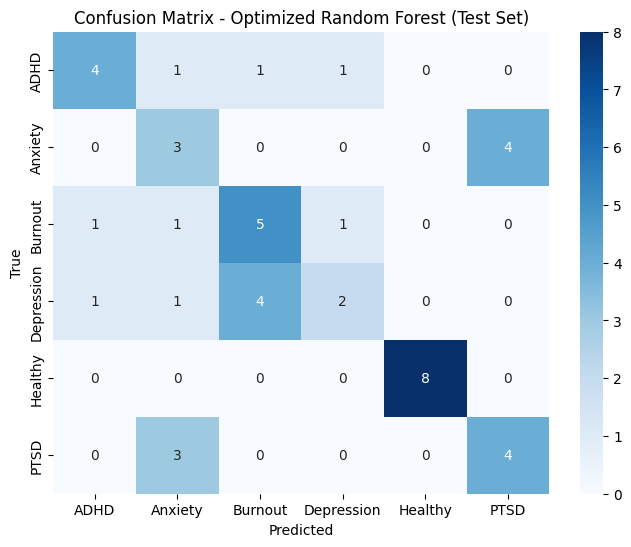

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the test set using the optimized model
y_test_pred_tuned = rf_model_tuned.predict(X_test)

# Evaluate performance on the test set
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_report_tuned = classification_report(y_test, y_test_pred_tuned, target_names=label_encoder.classes_)
test_cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print(f"\nAccuracy of the optimized Random Forest model on the test set: {test_accuracy_tuned:.4f}")
print("\nClassification Report (Optimized Model - Test Set):")
print(test_report_tuned)

print("\nConfusion Matrix (Optimized Model - Test Set):")
plt.figure(figsize=(8, 6))
sns.heatmap(test_cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Optimized Random Forest (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This code checks for data leakage by comparing feature rows between the training set (`X_train`) and the test set (`X_test`). It converts the DataFrames to sets of tuples and finds common rows. It then prints whether any duplicate feature rows are detected, indicating a potential data leakage at the instance level. In this case, no duplicates were found, which is a good sign for model integrity.

In [ ]:
import pandas as pd

# Convert DataFrames to sets of tuples for efficient comparison
# This assumes the order of columns is consistent, which it should be for X_train and X_test
X_train_tuples = {tuple(row) for row in X_train.values}
X_test_tuples = {tuple(row) for row in X_test.values}

# Find common rows (features) between the two sets
common_rows = X_train_tuples.intersection(X_test_tuples)

if common_rows:
    print(f"Detected {len(common_rows)} duplicate feature rows between X_train and X_test.")
    print("This indicates a potential data leakage at the instance level.")
else:
    print("No duplicate feature rows detected between X_train and X_test.")
    print("This reduces the risk of data leakage at the instance level.")

No duplicate feature rows detected between X_train and X_test.
This reduces the risk of data leakage at the instance level.


This text block introduces the next section, focusing on building a text-based model using TF-IDF for text vectorization. It explains that the vectorized data will then be split into training, validation, and testing sets, similar to the previous approach using emotional features.
`prepare_text_data` function, which is responsible for combining all daily journal texts, applying TF-IDF vectorization to convert them into numerical features, encoding the target `diagnosis` labels, and performing a stratified split into training, validation, and test sets. It returns the splits, the fitted TF-IDF vectorizer, and the label encoder.

In [ ]:
import joblib
from scipy.sparse import hstack

def prepare_text_data(df, text_columns, target_column, test_size=0.3):
    """
    Processes journal texts, generates TF-IDF vectors, and performs stratified splitting.
    """
    # 1. Combine journal columns into a single text block
    full_text = df[text_columns].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)

    # 2. Vectorize using TF-IDF
    tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, stop_words='english')
    X_text = tfidf_vectorizer.fit_transform(full_text)

    # 3. Encode diagnostic labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df[target_column])

    # 4. Stratified Split (Train, Val, Test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_text, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    return (X_train, X_val, X_test), (y_train, y_val, y_test), tfidf_vectorizer, label_encoder

This text cell introduces the training of the TF-IDF + Random Forest model, emphasizing that a pipeline will be built to combine `TfidfVectorizer` with a `RandomForestClassifier`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
from sklearn.model_selection import train_test_split # Import train_test_split

# Define the columns that contain the journal entries
text_columns = [f'day_{i}' for i in range(1, 8)] # Corrected column names
target_column = 'diagnosis' # Corrected target column name

# Call prepare_text_data to get the necessary splits and transformers
# This function was defined in cell 20a731b6
(X_train_text_cleaned, X_val_text_cleaned, X_test_text_cleaned), \
(y_train_text_cleaned, y_val_text_cleaned, y_test_text_cleaned), \
tfidf_vectorizer, label_encoder_text = prepare_text_data(
    df_patient_journals, text_columns, target_column
)

# Create a pipeline with TF-IDF and Random Forest Classifier
tfidf_rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define the parameter grid for GridSearchCV for the pipeline
param_grid_tfidf_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 10, None],
    'rf__min_samples_split': [2, 5, 10]
}
# Initialize GridSearchCV
grid_search_tfidf_rf = GridSearchCV(
    estimator=tfidf_rf_pipeline,
    param_grid=param_grid_tfidf_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run the grid search on the training set
grid_search_tfidf_rf.fit(X_train_text_cleaned, y_train_text_cleaned)

# Display the best parameters and the best score obtained
print(f"Best parameters for TF-IDF + Random Forest: {grid_search_tfidf_rf.best_params_}")
print(f"Best accuracy score for TF-IDF + Random Forest: {grid_search_tfidf_rf.best_score_:.4f}")

# Save the best model from the grid search
tfidf_rf_pipeline_tuned = grid_search_tfidf_rf.best_estimator_

print("TF-IDF + Random Forest Pipeline optimized and trained successfully.")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for TF-IDF + Random Forest: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best accuracy score for TF-IDF + Random Forest: 0.8095
TF-IDF + Random Forest Pipeline optimized and trained successfully.


This text cell introduces the evaluation of the TF-IDF + Random Forest model, specifically addressing a previous error and confirming that evaluation will proceed using newly created variables and the pipeline.

This code block evaluates both the unoptimized and optimized TF-IDF + Random Forest models on the validation and test sets. It first prints the dimensions of the cleaned data splits. Then, it fits the unoptimized pipeline, makes predictions, and displays accuracy, classification reports, and confusion matrices for both validation and test sets. Finally, it performs the same evaluation for the optimized `tfidf_rf_pipeline_tuned` on both sets, showcasing the impact of hyperparameter tuning.

Dimension of X_train_text_cleaned: 210 samples
Dimension of y_train_text_cleaned: 210 samples
Dimension of X_val_text_cleaned: 45 samples
Dimension of y_val_text_cleaned: 45 samples
Dimension of X_test_text_cleaned: 45 samples
Dimension of y_test_text_cleaned: 45 samples

--- Evaluation on the cleaned validation set (Unoptimized TF-IDF Model) ---

Accuracy on validation set: 0.8000

Classification Report (Validation Set - Unoptimized TF-IDF Model):
              precision    recall  f1-score   support

        ADHD       0.88      0.88      0.88         8
     Anxiety       0.64      0.88      0.74         8
     Burnout       0.67      0.57      0.62         7
  Depression       0.60      0.43      0.50         7
     Healthy       1.00      1.00      1.00         7
        PTSD       1.00      1.00      1.00         8

    accuracy                           0.80        45
   macro avg       0.80      0.79      0.79        45
weighted avg       0.80      0.80      0.79        45


Con

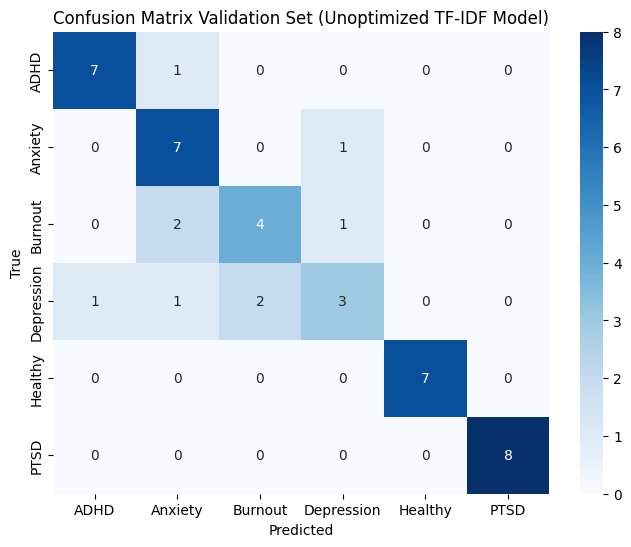


--- Evaluation on the cleaned internal test set (Unoptimized TF-IDF Model) ---

Accuracy on validation set: 0.8444

Classification Report (Test Set - Unoptimized TF-IDF Model):
              precision    recall  f1-score   support

        ADHD       1.00      1.00      1.00         7
     Anxiety       1.00      0.86      0.92         7
     Burnout       0.70      0.88      0.78         8
  Depression       0.60      0.38      0.46         8
     Healthy       1.00      1.00      1.00         8
        PTSD       0.78      1.00      0.88         7

    accuracy                           0.84        45
   macro avg       0.85      0.85      0.84        45
weighted avg       0.84      0.84      0.83        45


Confusion Matrix (Unoptimized TF-IDF Model):


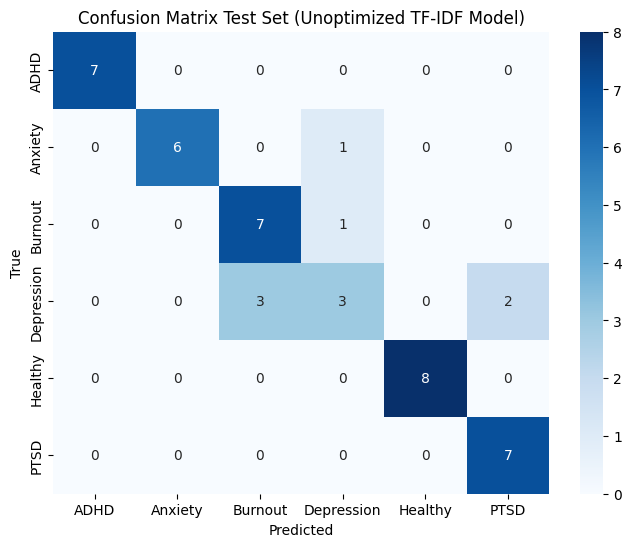


--- Evaluation of Optimized TF-IDF + Random Forest Model on Validation Set ---

Accuracy of the optimized TF-IDF model on the validation set: 0.7556

Classification Report (Optimized TF-IDF Model - Validation Set):
              precision    recall  f1-score   support

        ADHD       0.86      0.75      0.80         8
     Anxiety       0.55      0.75      0.63         8
     Burnout       0.80      0.57      0.67         7
  Depression       0.50      0.43      0.46         7
     Healthy       0.88      1.00      0.93         7
        PTSD       1.00      1.00      1.00         8

    accuracy                           0.76        45
   macro avg       0.76      0.75      0.75        45
weighted avg       0.77      0.76      0.75        45


Confusion Matrix (Optimized TF-IDF Model - Validation Set):


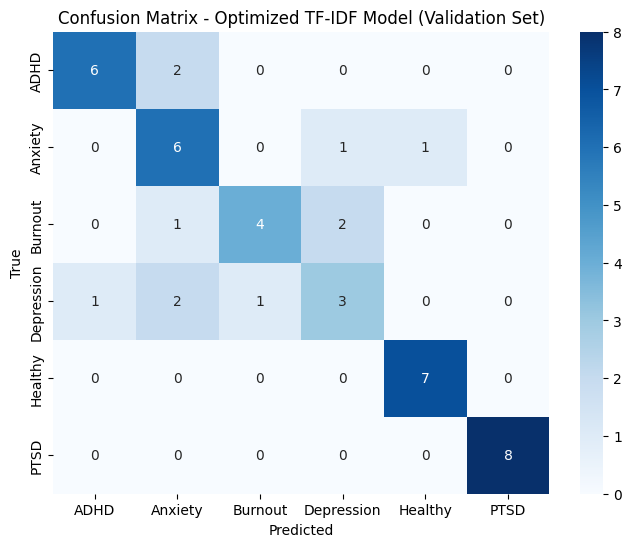


--- Evaluation of Optimized TF-IDF + Random Forest Model on Test Set ---

Accuracy of the optimized TF-IDF model on the test set: 0.9111

Classification Report (Optimized TF-IDF Model - Test Set):
              precision    recall  f1-score   support

        ADHD       1.00      1.00      1.00         7
     Anxiety       1.00      1.00      1.00         7
     Burnout       0.78      0.88      0.82         8
  Depression       0.83      0.62      0.71         8
     Healthy       1.00      1.00      1.00         8
        PTSD       0.88      1.00      0.93         7

    accuracy                           0.91        45
   macro avg       0.91      0.92      0.91        45
weighted avg       0.91      0.91      0.91        45


Confusion Matrix (Optimized TF-IDF Model - Test Set):


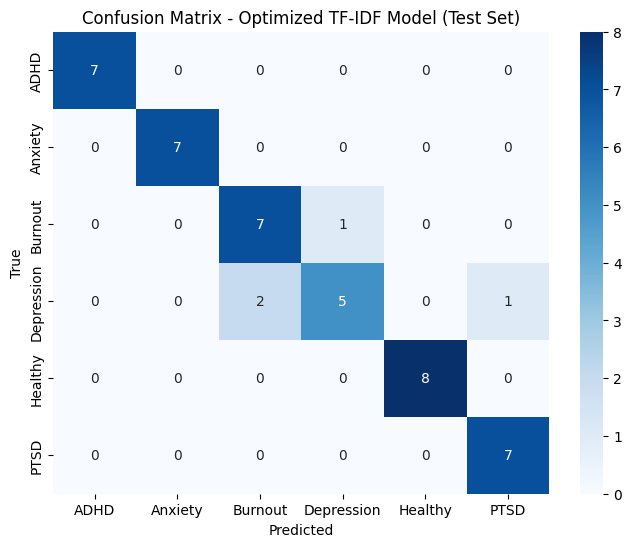

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Display the dimensions of the cleaned data splits
print(f"Dimension of X_train_text_cleaned: {X_train_text_cleaned.shape[0]} samples")
print(f"Dimension of y_train_text_cleaned: {y_train_text_cleaned.shape[0]} samples")
print(f"Dimension of X_val_text_cleaned: {X_val_text_cleaned.shape[0]} samples")
print(f"Dimension of y_val_text_cleaned: {y_val_text_cleaned.shape[0]} samples")
print(f"Dimension of X_test_text_cleaned: {X_test_text_cleaned.shape[0]} samples")
print(f"Dimension of y_test_text_cleaned: {y_test_text_cleaned.shape[0]} samples")

# Fit the unoptimized TF-IDF pipeline to the training data
tfidf_rf_pipeline.fit(X_train_text_cleaned, y_train_text_cleaned)

print("\n--- Evaluation on the cleaned validation set (Unoptimized TF-IDF Model) ---")
# Make predictions on the cleaned internal validation set using the UNOPTIMIZED pipeline
y_val_text_cleaned_pred = tfidf_rf_pipeline.predict(X_val_text_cleaned)

# Evaluate performance
cleaned_val_accuracy = accuracy_score(y_val_text_cleaned, y_val_text_cleaned_pred)
cleaned_val_report = classification_report(y_val_text_cleaned, y_val_text_cleaned_pred, target_names=label_encoder_text.classes_)
cleaned_val_cm = confusion_matrix(y_val_text_cleaned, y_val_text_cleaned_pred)

print(f"\nAccuracy on validation set: {cleaned_val_accuracy:.4f}")
print("\nClassification Report (Validation Set - Unoptimized TF-IDF Model):")
print(cleaned_val_report)

print("\nConfusion Matrix Validation Set (Unoptimized TF-IDF Model)")
plt.figure(figsize=(8, 6))
sns.heatmap(cleaned_val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_text.classes_, yticklabels=label_encoder_text.classes_)
plt.title('Confusion Matrix Validation Set (Unoptimized TF-IDF Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\n--- Evaluation on the cleaned internal test set (Unoptimized TF-IDF Model) ---")
# Make predictions on the cleaned internal test set using the UNOPTIMIZED pipeline
y_test_text_cleaned_pred = tfidf_rf_pipeline.predict(X_test_text_cleaned)

# Evaluate performance
cleaned_internal_accuracy = accuracy_score(y_test_text_cleaned, y_test_text_cleaned_pred)
cleaned_internal_report = classification_report(y_test_text_cleaned, y_test_text_cleaned_pred, target_names=label_encoder_text.classes_)
cleaned_internal_cm = confusion_matrix(y_test_text_cleaned, y_test_text_cleaned_pred)

print(f"\nAccuracy on validation set: {cleaned_internal_accuracy:.4f}")
print("\nClassification Report (Test Set - Unoptimized TF-IDF Model):")
print(cleaned_internal_report)

print("\nConfusion Matrix (Unoptimized TF-IDF Model):")
plt.figure(figsize=(8, 6))
sns.heatmap(cleaned_internal_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_text.classes_, yticklabels=label_encoder_text.classes_)
plt.title('Confusion Matrix Test Set (Unoptimized TF-IDF Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# --- Evaluation of Optimized TF-IDF + Random Forest Model on Validation Set ---
print("\n--- Evaluation of Optimized TF-IDF + Random Forest Model on Validation Set ---")

y_val_text_cleaned_pred_tuned = tfidf_rf_pipeline_tuned.predict(X_val_text_cleaned)
val_accuracy_tfidf_tuned = accuracy_score(y_val_text_cleaned, y_val_text_cleaned_pred_tuned)
val_report_tfidf_tuned = classification_report(y_val_text_cleaned, y_val_text_cleaned_pred_tuned, target_names=label_encoder_text.classes_)
val_cm_tfidf_tuned = confusion_matrix(y_val_text_cleaned, y_val_text_cleaned_pred_tuned)

print(f"\nAccuracy of the optimized TF-IDF model on the validation set: {val_accuracy_tfidf_tuned:.4f}")
print("\nClassification Report (Optimized TF-IDF Model - Validation Set):")
print(val_report_tfidf_tuned)

print("\nConfusion Matrix (Optimized TF-IDF Model - Validation Set):")
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_tfidf_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_text.classes_, yticklabels=label_encoder_text.classes_)
plt.title('Confusion Matrix - Optimized TF-IDF Model (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# --- Evaluation of Optimized TF-IDF + Random Forest Model on Test Set ---
print("\n--- Evaluation of Optimized TF-IDF + Random Forest Model on Test Set ---")

y_test_text_cleaned_pred_tuned = tfidf_rf_pipeline_tuned.predict(X_test_text_cleaned)
test_accuracy_tfidf_tuned = accuracy_score(y_test_text_cleaned, y_test_text_cleaned_pred_tuned)
test_report_tfidf_tuned = classification_report(y_test_text_cleaned, y_test_text_cleaned_pred_tuned, target_names=label_encoder_text.classes_)
test_cm_tfidf_tuned = confusion_matrix(y_test_text_cleaned, y_test_text_cleaned_pred_tuned)

print(f"\nAccuracy of the optimized TF-IDF model on the test set: {test_accuracy_tfidf_tuned:.4f}")
print("\nClassification Report (Optimized TF-IDF Model - Test Set):")
print(test_report_tfidf_tuned)

print("\nConfusion Matrix (Optimized TF-IDF Model - Test Set):")
plt.figure(figsize=(8, 6))
sns.heatmap(test_cm_tfidf_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_text.classes_, yticklabels=label_encoder_text.classes_)
plt.title('Confusion Matrix - Optimized TF-IDF Model (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This cell generates TF-IDF plots for each unique diagnosis. It re-creates the `full_text` and applies the already fitted `tfidf_vectorizer` to get the `X_text` matrix. For each diagnosis, it sums the TF-IDF scores for relevant patients to identify the top 10 most important words. These words and their aggregated scores are then visualized in horizontal bar charts, showing the distinct linguistic profiles associated with each diagnosis.

Generating TF-IDF plots for each diagnosis...


/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




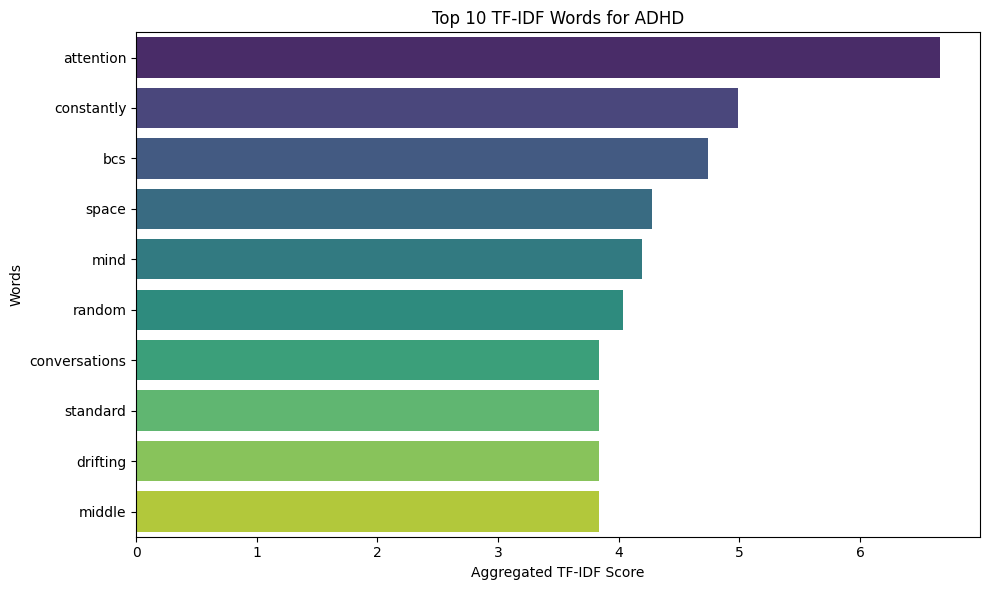

/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




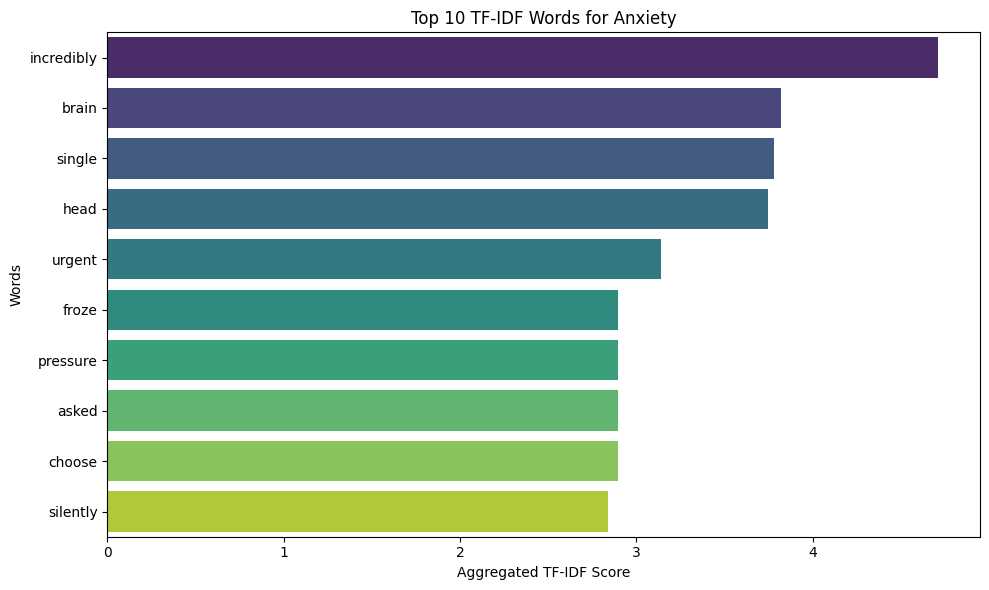

/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




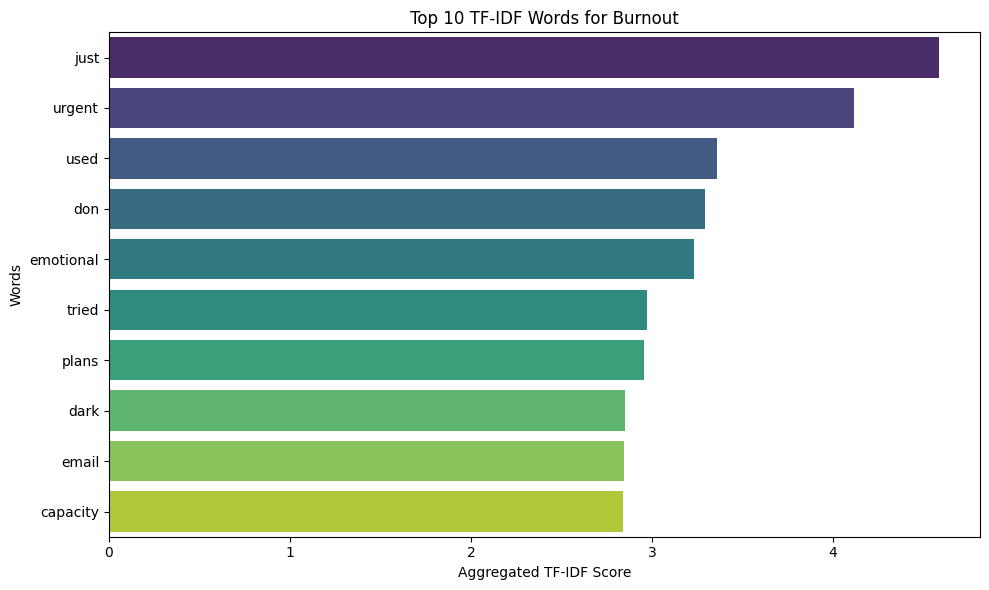

/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




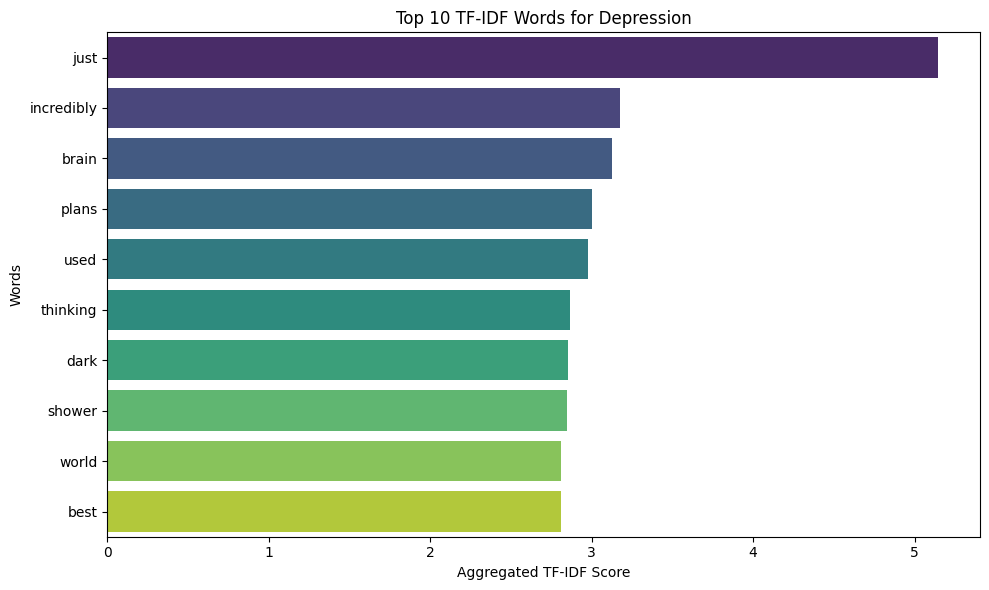

/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




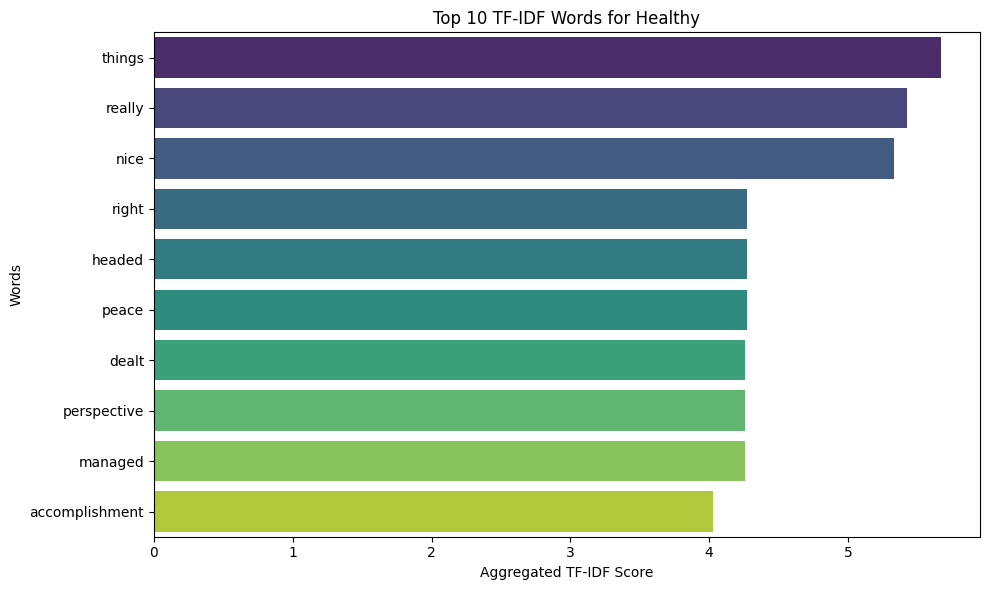

/tmp/ipykernel_3118/1694035510.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




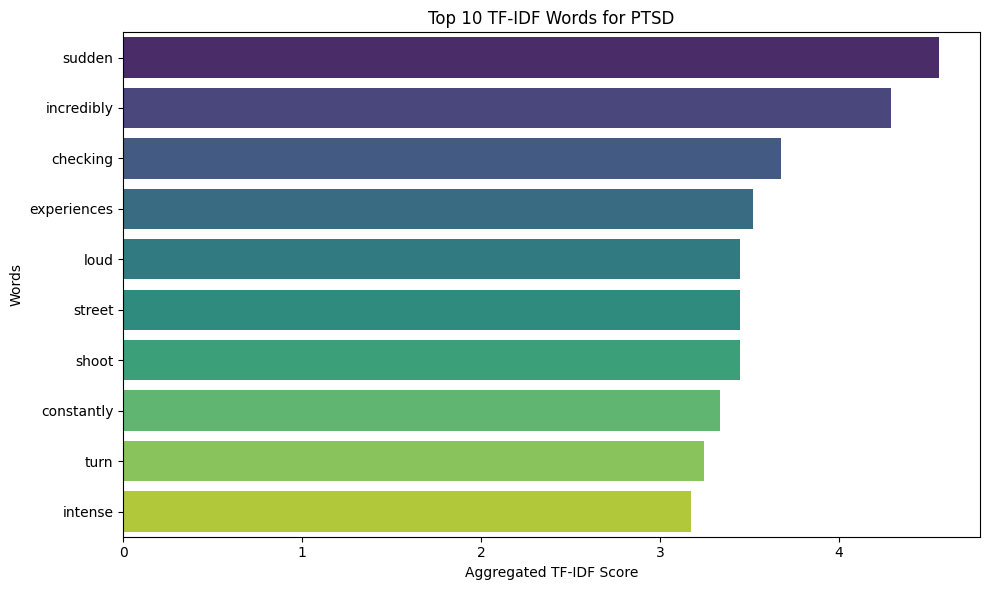

TF-IDF plot generation complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Re-create full_text and X_text, y_text_encoded for plotting purposes
# These variables were computed inside prepare_text_data and not explicitly returned for the full dataset.
# Assuming 'df_patient_journals' is available from previous cells.
# Assuming 'tfidf_vectorizer' and 'label_encoder_text' are available and fitted from previous cells.

# Define the columns that contain the journal entries (from cell 82005404 context)
text_columns = [f'day_{i}' for i in range(1, 8)]
target_column = 'diagnosis'

# 1. Combine journal columns into a single text block
full_text = df_patient_journals[text_columns].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)

# 2. Transform using the already fitted TF-IDF vectorizer
X_text = tfidf_vectorizer.transform(full_text)

# 3. Encode diagnostic labels using the already fitted label encoder
y_text_encoded = label_encoder_text.transform(df_patient_journals[target_column])


# Get feature names from the fitted TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get unique diagnoses
unique_diagnoses = label_encoder_text.classes_

print("Generating TF-IDF plots for each diagnosis...")

for diagnosis_label in unique_diagnoses:
    encoded_label = label_encoder_text.transform([diagnosis_label])[0]
    # Get indices of patients belonging to this diagnosis
    indices_for_diagnosis = np.where(y_text_encoded == encoded_label)[0]

    # Select the corresponding rows from the TF-IDF matrix
    tfidf_subset = X_text[indices_for_diagnosis]

    # Sum TF-IDF scores across these rows for each term
    tfidf_sums = np.array(tfidf_subset.sum(axis=0)).flatten()

    # Get top 10 words with highest TF-IDF sums
    top_indices = tfidf_sums.argsort()[-10:][::-1]  # Get top 10 and reverse for highest first
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [tfidf_sums[i] for i in top_indices]

    # Create a horizontal bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_scores, y=top_words, palette='viridis')
    plt.title(f'Top 10 TF-IDF Words for {diagnosis_label}')
    plt.xlabel('Aggregated TF-IDF Score')
    plt.ylabel('Words')
    plt.tight_layout()
    plt.show()

print("TF-IDF plot generation complete.")

This text block describes the findings from the TF-IDF analysis, stating that it revealed distinct linguistic signatures for each condition. It provides examples of how 'Burnout' was characterized by work-related terms and 'Depression' by markers of isolation, confirming the model's ability to capture contextually relevant terminology.

This code defines the `generate_diagnosis_radar_charts` function, which creates RoBERTa emotional radar charts for each unique diagnosis based on the mean Ekman emotion scores. It iterates through each diagnosis, filters the `df_emotional_features`, calculates the mean for each Ekman emotion, and then plots a radar chart to visualize the emotional profile. This allows for a clear comparison of emotional states across different diagnostic groups.

Generating RoBERTa emotional radar charts for each diagnosis...


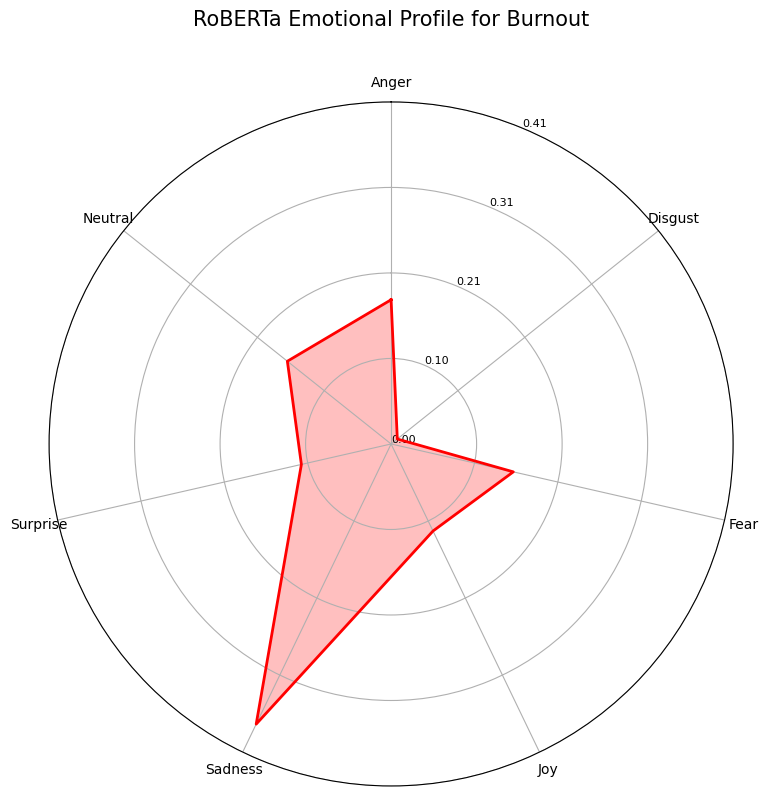

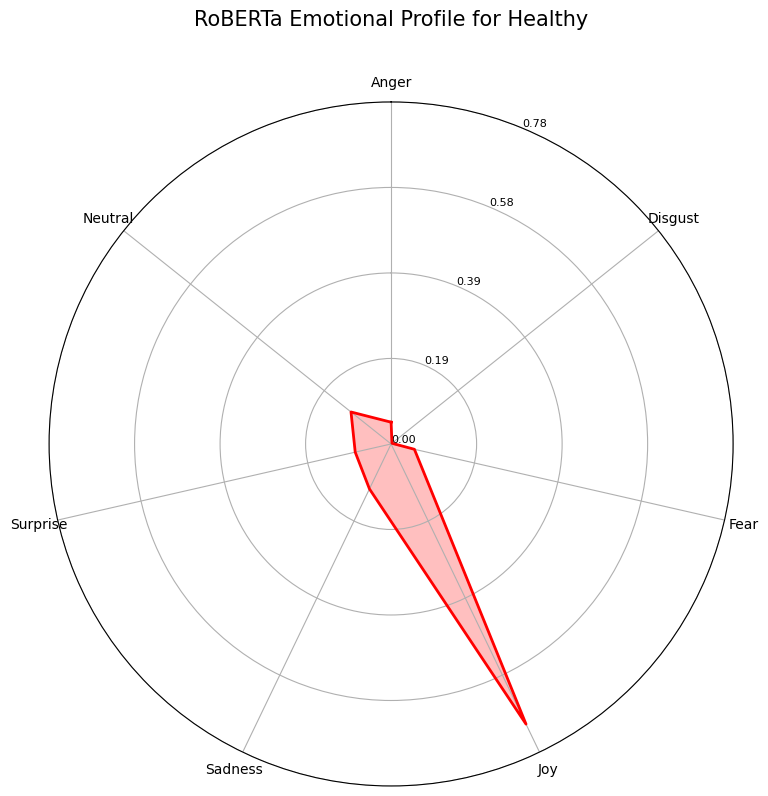

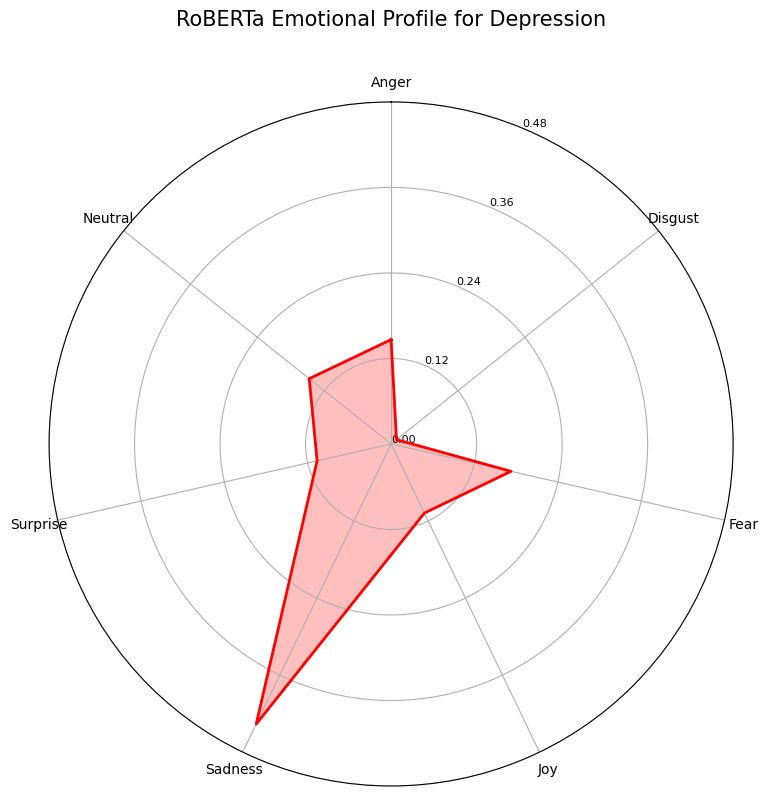

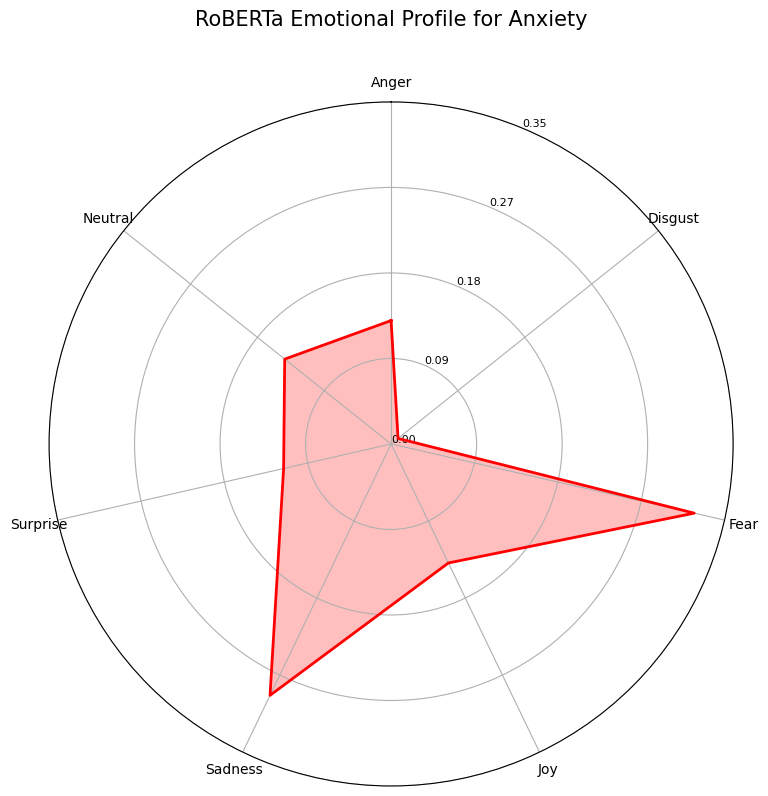

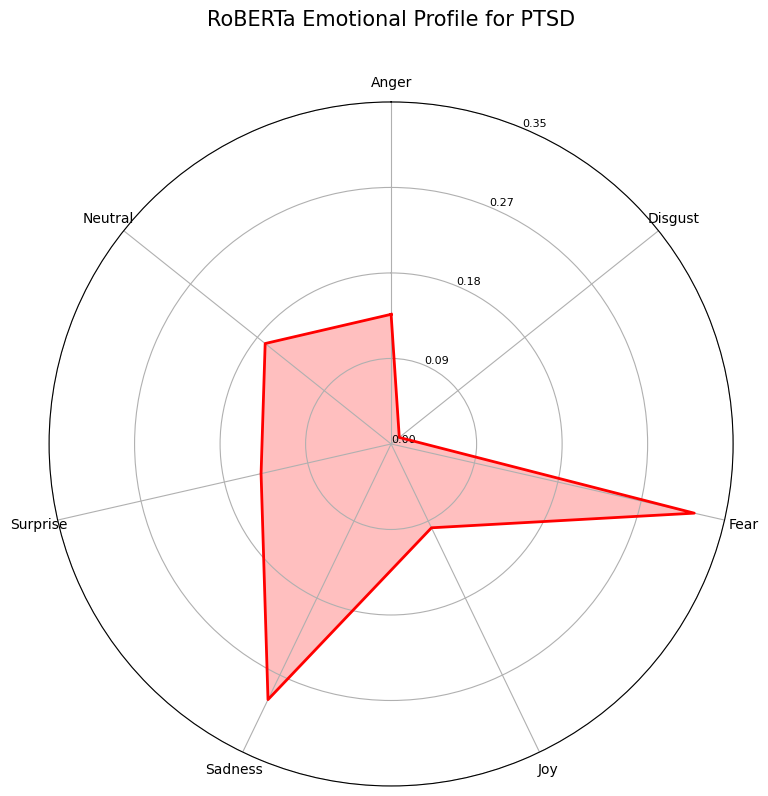

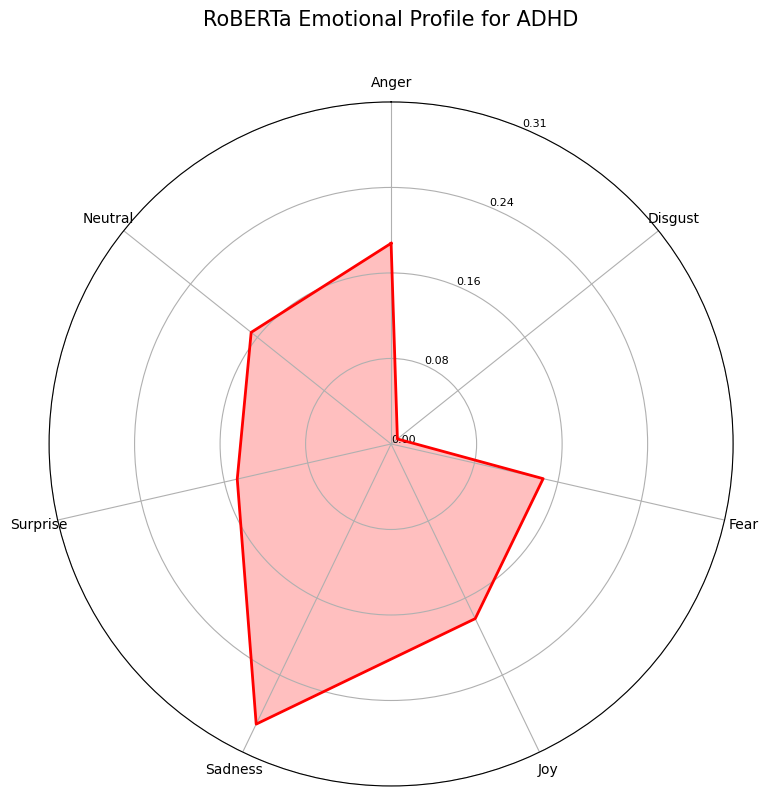

RoBERTa emotional radar chart generation complete.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_diagnosis_radar_charts(df_emotional_features, EKMAN_MAPPING):
    """
    Generates RoBERTa emotional radar charts for each unique diagnosis
    found in df_emotional_features.

    Args:
        df_emotional_features (pd.DataFrame): DataFrame containing emotional features
                                             and a 'Final_Diagnosis' column.
        EKMAN_MAPPING (dict): Mapping of Ekman emotions to fine-grained emotions.
    """
    # Get unique diagnoses from df_emotional_features
    unique_diagnoses = df_emotional_features['Final_Diagnosis'].unique()

    # Get Ekman emotions from the mapping
    ekman_emotions = list(EKMAN_MAPPING.keys())

    print("Generating RoBERTa emotional radar charts for each diagnosis...")

    for diagnosis_label in unique_diagnoses:
        # Filter emotional features for the current diagnosis
        df_filtered = df_emotional_features[df_emotional_features['Final_Diagnosis'] == diagnosis_label]

        # Calculate the mean of each Ekman emotion's 'Mean' score
        mean_ekman_scores = {emo: df_filtered[f'{emo}_Mean'].mean() for emo in ekman_emotions}

        # Prepare data for radar chart
        categories = list(mean_ekman_scores.keys())
        values = list(mean_ekman_scores.values())

        # Close the circle for the radar chart
        values = values + values[:1]
        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        angles = angles + angles[:1]

        # Create radar chart
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        ax.fill(angles, values, color='red', alpha=0.25)
        ax.plot(angles, values, color='red', linewidth=2)

        # Set labels and title
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=10)
        ax.set_title(f'RoBERTa Emotional Profile for {diagnosis_label}', size=15, color='black', y=1.1)

        # Set y-axis limits dynamically
        max_val = max(values) if values else 1.0
        ax.set_ylim(0, max_val * 1.1)  # Ensure some padding above max value
        num_ticks = 5
        if max_val > 0:
            yticks = np.linspace(0, max_val * 1.1, num_ticks)
            ax.set_yticks(yticks)
            ax.set_yticklabels([f'{y:.2f}' for y in yticks], fontsize=8)
        else:
            ax.set_yticks([0])
            ax.set_yticklabels(['0.00'], fontsize=8)

        plt.tight_layout()
        plt.show()

    print("RoBERTa emotional radar chart generation complete.")

# Keep the test for the diagnosis
# Check if df_emotional_features is defined before calling the function
if 'df_emotional_features' in globals() and 'EKMAN_MAPPING' in globals():
    generate_diagnosis_radar_charts(df_emotional_features, EKMAN_MAPPING)
else:
    print("Error: The DataFrame 'df_emotional_features' or 'EKMAN_MAPPING' is not defined.")
    print("Please ensure you have executed the cells that define 'df_emotional_features' (cell bLQsiGvyderb) and 'EKMAN_MAPPING' (cell 3lzZs5rUwLP_) before running this cell.")


This text cell introduces the next section: combining emotional and TF-IDF features. It outlines the intention to create a hybrid model by merging these two feature sets and evaluating its performance on the original test set to see if this combined approach yields better results.

This code block combines the emotional features (`X_train`) and TF-IDF text features (`X_train_text_cleaned`) using `hstack` to create `X_train_combined` and `X_test_combined`. It prints the shapes of these combined feature sets and then initializes and trains a new `RandomForestClassifier` (`rf_combined_model`) on the combined training data, confirming successful training.

In [ ]:
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier

# Combine emotional features (X_train) and TF-IDF text features (X_train_text_cleaned)
X_train_combined = hstack([X_train, X_train_text_cleaned])
X_test_combined = hstack([X_test, X_test_text_cleaned])

print(f"Shape of combined training features: {X_train_combined.shape}")
print(f"Shape of combined test features: {X_test_combined.shape}")

# Initialize a new Random Forest Classifier for combined features
rf_combined_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_combined_model.fit(X_train_combined, y_train)

print("Random Forest model trained on combined features successfully.")

Shape of combined training features: (210, 654)
Shape of combined test features: (45, 654)
Random Forest model trained on combined features successfully.


This text cell indicates that the next step is to evaluate the combined model on the original test set.


Accuracy of the Combined (Optimized Emotional + Optimized TF-IDF) Random Forest model on the original test set: 0.8889

Classification Report (Combined Optimized Model - Original Test Set):
              precision    recall  f1-score   support

        ADHD       1.00      1.00      1.00         7
     Anxiety       0.88      1.00      0.93         7
     Burnout       0.70      0.88      0.78         8
  Depression       0.80      0.50      0.62         8
     Healthy       1.00      1.00      1.00         8
        PTSD       1.00      1.00      1.00         7

    accuracy                           0.89        45
   macro avg       0.90      0.90      0.89        45
weighted avg       0.89      0.89      0.88        45


Confusion Matrix (Combined Optimized Model - Original Test Set):


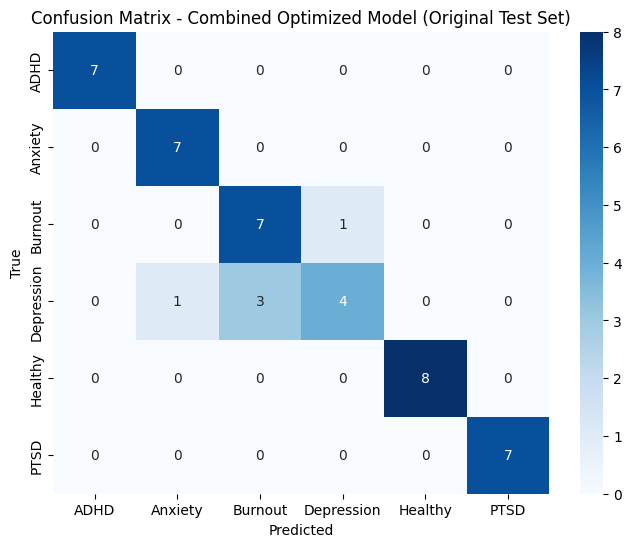

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Get probability predictions from the optimized emotional features model
# rf_model_tuned is the optimized Random Forest model for emotional features
y_pred_proba_emotional = rf_model_tuned.predict_proba(X_test)

# 2. Get probability predictions from the optimized TF-IDF text features model
# tfidf_rf_pipeline_tuned is the optimized Pipeline for TF-IDF features
y_pred_proba_tfidf = tfidf_rf_pipeline_tuned.predict_proba(X_test_text_cleaned)

# 3. Average the probabilities to get combined predictions
# Assuming both models predict probabilities for the same classes in the same order
y_pred_proba_combined_optimized = (y_pred_proba_emotional + y_pred_proba_tfidf) / 2

# 4. Convert averaged probabilities to final class predictions
y_test_combined_optimized_pred = np.argmax(y_pred_proba_combined_optimized, axis=1)

# Evaluate performance of the combined optimized model
combined_optimized_test_accuracy = accuracy_score(y_test, y_test_combined_optimized_pred)
combined_optimized_test_report = classification_report(y_test, y_test_combined_optimized_pred, target_names=label_encoder.classes_)
combined_optimized_test_cm = confusion_matrix(y_test, y_test_combined_optimized_pred)

print(f"\nAccuracy of the Combined (Optimized Emotional + Optimized TF-IDF) Random Forest model on the original test set: {combined_optimized_test_accuracy:.4f}")
print("\nClassification Report (Combined Optimized Model - Original Test Set):")
print(combined_optimized_test_report)

print("\nConfusion Matrix (Combined Optimized Model - Original Test Set):")
plt.figure(figsize=(8, 6))
sns.heatmap(combined_optimized_test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Combined Optimized Model (Original Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This cell calculates and compares Gini Importance and Permutation Feature Importance (PFI) for the combined model's features. It constructs a DataFrame for comparison, selects the top 20 features by PFI score, and visualizes the comparison using a side-by-side bar chart. The code then terminates prematurely due to a `KeyboardInterrupt` during PFI calculation.

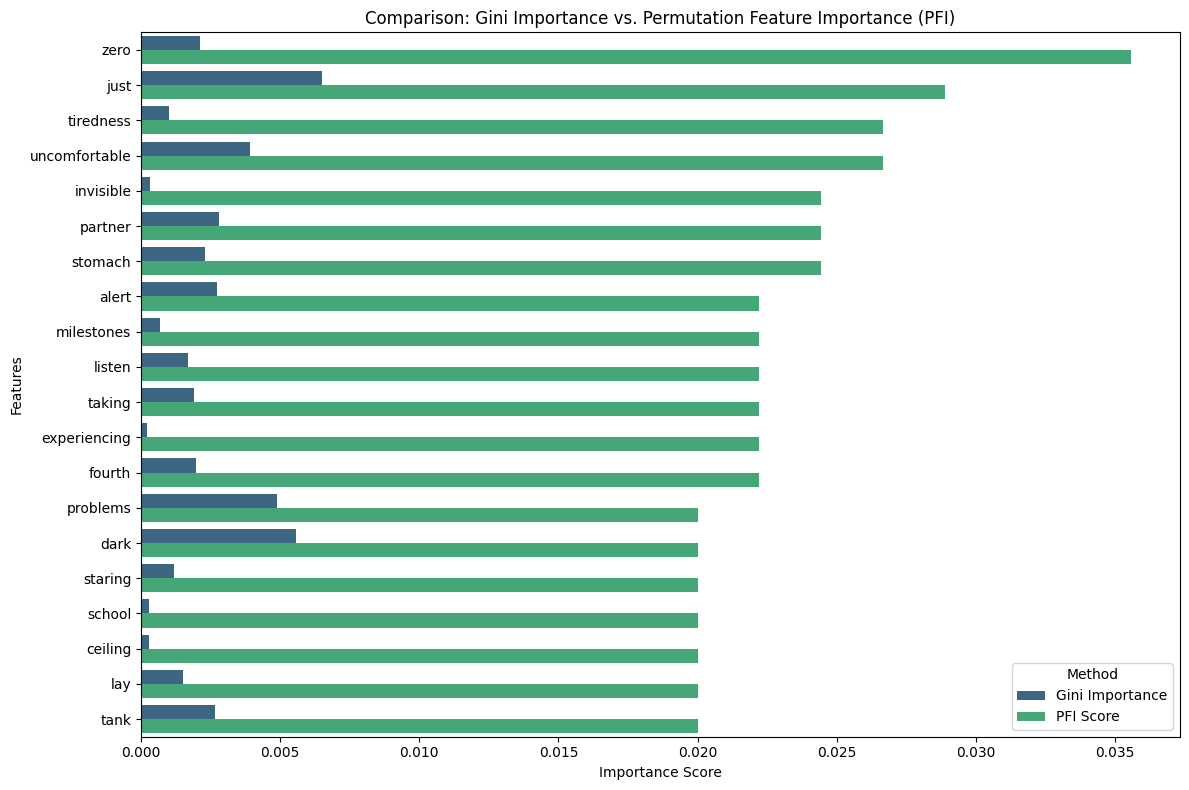

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# 1. Obținerea numelor tuturor trăsăturilor (Emoționale + TF-IDF)
# Asigură-te că emotional_feature_names este lista cu cele 21 de nume (3x7)
# emotional_feature_names is not defined globally, we need to create it from the X_train columns
emotional_feature_names = X_train.columns.to_list()
all_feature_names = np.concatenate([emotional_feature_names, tfidf_vectorizer.get_feature_names_out()])

# 2. Gini Importance (Direct din model)
gini_importances = rf_combined_model.feature_importances_

# 3. Permutation Feature Importance (PFI) pe setul de test
# Setăm n_repeats=10 pentru stabilitatea rezultatelor
pfi_result = permutation_importance(rf_combined_model, X_test_combined.toarray(), y_test,
                                    n_repeats=10, random_state=42, n_jobs=-1)

# 4. Crearea DataFrame-ului pentru comparație
df_comparison = pd.DataFrame({
    'Feature': all_feature_names,
    'Gini Importance': gini_importances,
    'PFI Score': pfi_result.importances_mean
})

# Selectăm top 20 trăsături după PFI (pentru a avea un grafic lizibil)
df_top20 = df_comparison.sort_values(by='PFI Score', ascending=False).head(20)

# 5. Vizualizarea comparativă (Side-by-Side Bar Chart)
df_melted = df_top20.melt(id_vars='Feature', var_name='Method', value_name='Importance')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melted, x='Importance', y='Feature', hue='Method', palette='viridis')
plt.title('Comparison: Gini Importance vs. Permutation Feature Importance (PFI)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

This code block identifies the top 20 most important features in the combined Random Forest model based on Gini Importance. It creates a DataFrame of all features and their importances, sorts them, and then visualizes the top 20 using a horizontal bar plot with `seaborn` and `matplotlib`. This helps in understanding which emotional and TF-IDF features contribute most to the model's predictions globally.

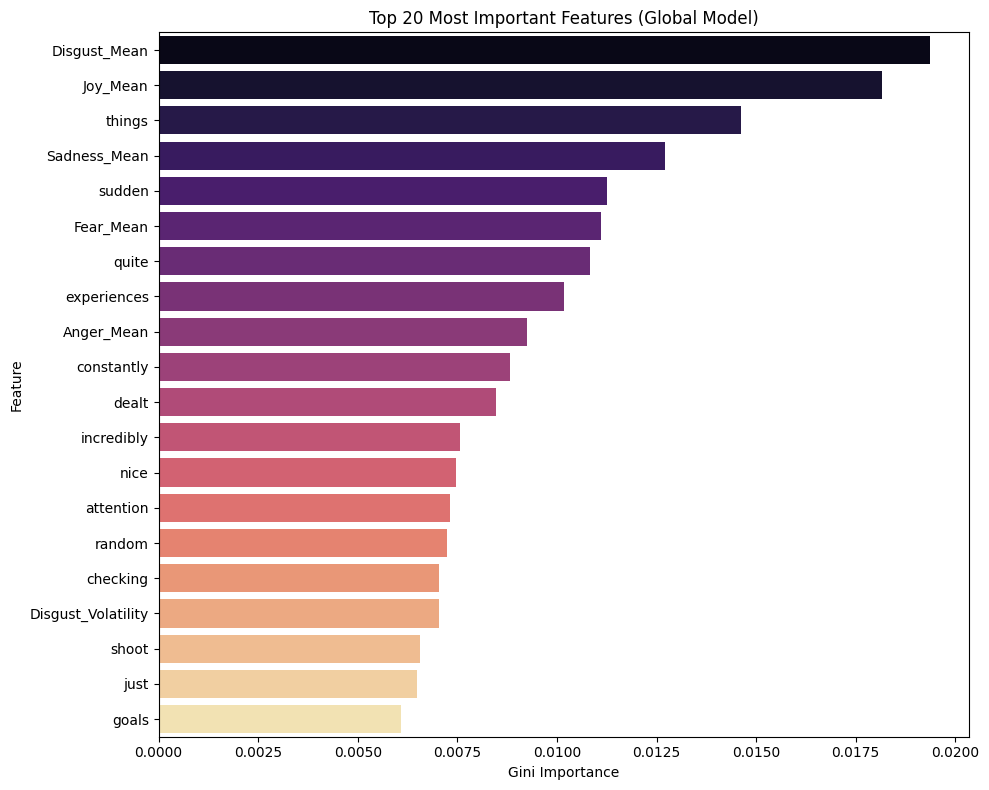

In [ ]:
# 1. Combine importances (ensure the order of lists matches X_train_combined)
all_importances = rf_combined_model.feature_importances_
all_names = np.concatenate([emotional_feature_names, tfidf_vectorizer.get_feature_names_out()])

# 2. Create the total DataFrame
df_total = pd.DataFrame({'Feature': all_names, 'Importance': all_importances})

# 3. Take the Top 20 from the entire set (the most relevant overall)
df_top20_total = df_total.sort_values(by='Importance', ascending=False).head(20)

# 4. Visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=df_top20_total, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Top 20 Most Important Features (Global Model)')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

This cell attempts to generate SHAP summary plots for each diagnosis to explain the predictions of the `rf_combined_model`. It initializes a `shap.TreeExplainer` and calculates SHAP values. However, it encounters a `NameError` because `X_test_combined` is not defined in the current scope (likely due to the previous `KeyboardInterrupt` stopping its definition), preventing the SHAP plots from being generated.

Generating SHAP summary plot for: ADHD


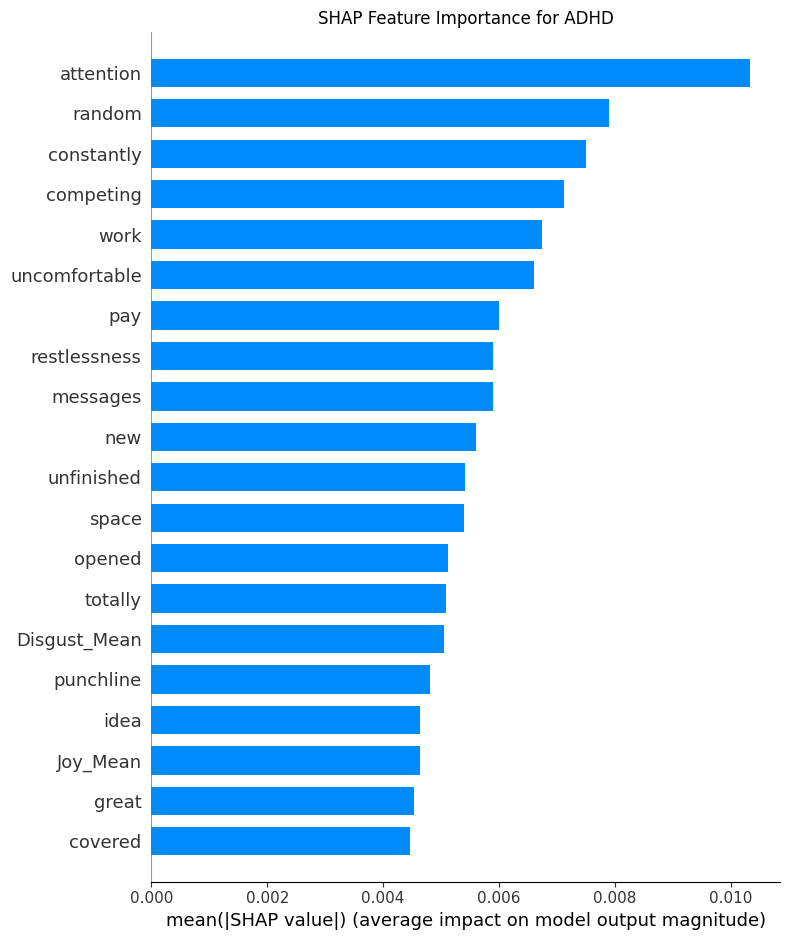

Generating SHAP summary plot for: Anxiety


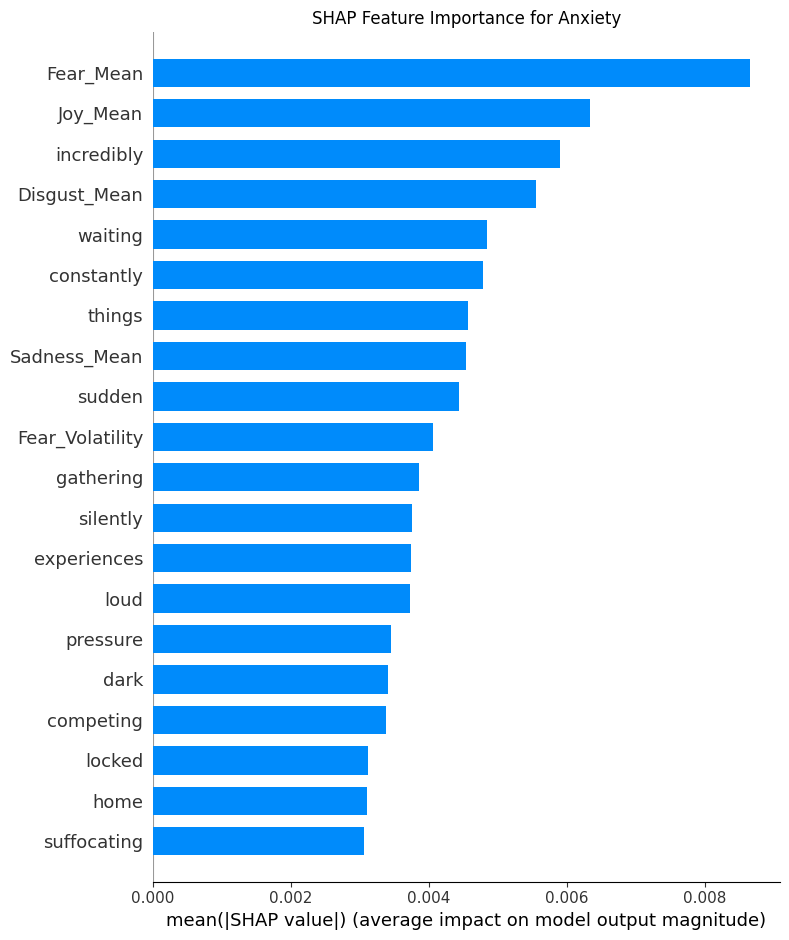

Generating SHAP summary plot for: Burnout


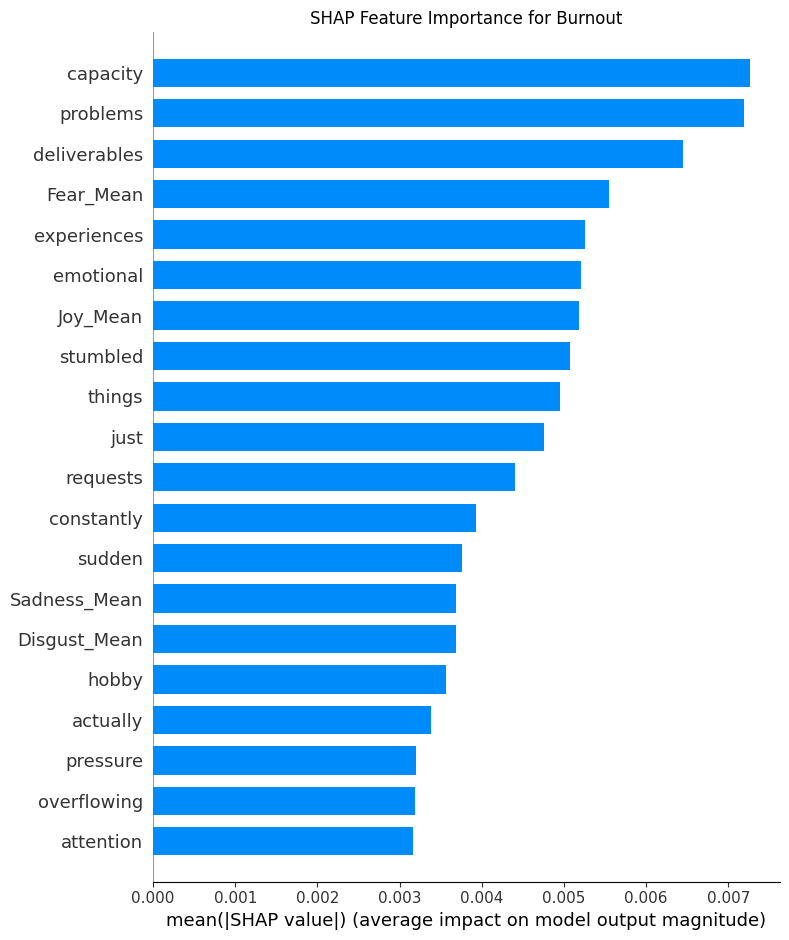

Generating SHAP summary plot for: Depression


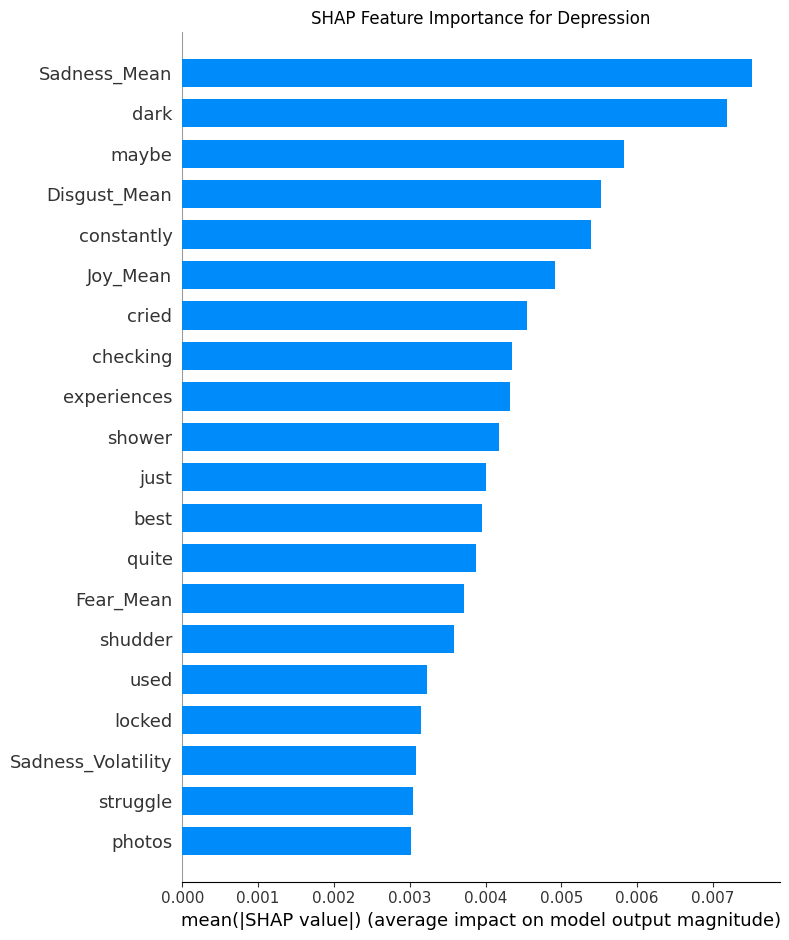

Generating SHAP summary plot for: Healthy


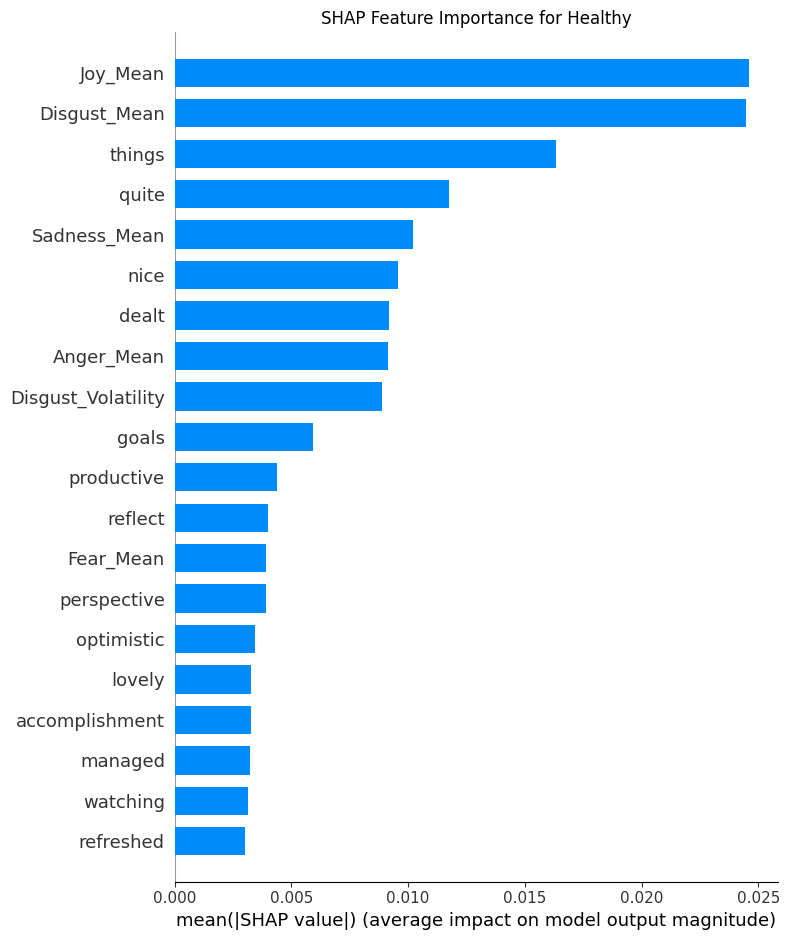

Generating SHAP summary plot for: PTSD


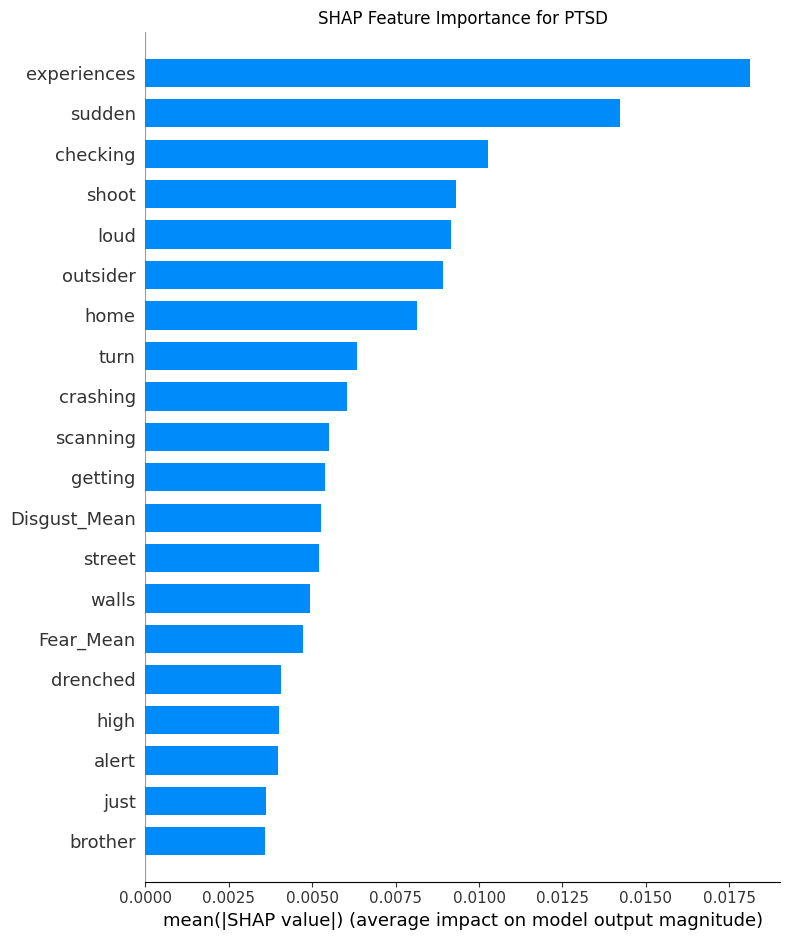

In [ ]:
import matplotlib.pyplot as plt
import shap

# 1. Initialize the explainer (if not already done)
explainer = shap.TreeExplainer(rf_combined_model)

# 2. Calculate SHAP values
# In Random Forest (multiclass), shap_values is a list of matrices (but can also be a 3D array)
# Interpreting the `shap_values` variable from the kernel as being of the form (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_combined.toarray())

# 3. Iterate through each class and generate the plot
for i, diagnosis in enumerate(label_encoder_text.classes_):
    print(f"Generating SHAP summary plot for: {diagnosis}")

    shap.summary_plot(shap_values[:, :, i], X_test_combined.toarray(),
                      feature_names=all_feature_names,
                      plot_type="bar",
                      show=False) # show=False allows us to customize the title

    plt.title(f"SHAP Feature Importance for {diagnosis}")
    plt.tight_layout()
    plt.show()

This script, `save_model_to_drive.py`, is designed to be run once after training. It mounts Google Drive, creates a designated directory (`DRIVE_ARTIFACTS_DIR`), and then saves all trained models and transformers (RoBERTa classifier, TF-IDF vectorizer, label encoder, and the combined Random Forest model) to this directory using `joblib`. It also saves the list of emotional feature names. The purpose is to persistently store these artifacts, allowing them to be loaded directly in future Colab sessions without re-running lengthy training processes.

In [ ]:
# -*- coding: utf-8 -*-

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import joblib

DRIVE_ARTIFACTS_DIR = "/content/drive/MyDrive/emotion_ai_artifacts"
os.makedirs(DRIVE_ARTIFACTS_DIR, exist_ok=True)


def _save(step_name, filename, value_fn):
    """Runs value_fn() and saves the result; skips gracefully if it fails
    because a variable from an earlier cell isn't defined right now."""
    try:
        value = value_fn()
    except NameError as e:
        print(f"⚠️ Skipped {step_name}: {e} (that variable isn't defined in this session)")
        return
    joblib.dump(value, os.path.join(DRIVE_ARTIFACTS_DIR, filename))
    print(f"✅ Saved {step_name} -> {filename}")


# 1. The RoBERTa model (already saved locally in the notebook at save_directory)
roberta_src = "./roberta_go_emotions_local"
roberta_dst = os.path.join(DRIVE_ARTIFACTS_DIR, "roberta_go_emotions_local")
if os.path.exists(roberta_src):
    if os.path.exists(roberta_dst):
        shutil.rmtree(roberta_dst)
    shutil.copytree(roberta_src, roberta_dst)
    print("✅ RoBERTa saved to Drive.")
else:
    print("⚠️ Skipped RoBERTa: ./roberta_go_emotions_local not found in this session.")

# 2. Emotional feature names - derived directly from EKMAN_MAPPING, no
#    X_train (or any other trained variable) required at all.
try:
    from emotion_ai_utils import EKMAN_MAPPING
    emotional_feature_names = [
        f'{emo}_{stat}' for emo in EKMAN_MAPPING.keys() for stat in ['Mean', 'Volatility', 'Slope']
    ]
    joblib.dump(emotional_feature_names, os.path.join(DRIVE_ARTIFACTS_DIR, "emotional_feature_names.joblib"))
    print("✅ Saved emotional feature names -> emotional_feature_names.joblib")
except Exception as e:
    print(f"⚠️ Skipped emotional feature names: {e}")

# 3. TF-IDF vectorizer
_save("TF-IDF vectorizer", "tfidf_vectorizer.joblib", lambda: tfidf_vectorizer)

# 4. Label encoder (diagnosis names, in the order used by rf_combined_model)
_save("label encoder", "label_encoder.joblib", lambda: label_encoder)

# 5. The hybrid model (emotional + TF-IDF) - the main model the app uses
_save("hybrid model", "rf_combined_model.joblib", lambda: rf_combined_model)

# 6. Optional: emotional-only model and TF-IDF-only pipeline (not required
#    by the current app, only useful if you rebuild the 3-model comparison)
_save("emotional-only model", "rf_model_tuned.joblib", lambda: rf_model_tuned)
_save("TF-IDF-only pipeline", "tfidf_rf_pipeline_tuned.joblib", lambda: tfidf_rf_pipeline_tuned)

print("\n✅ Done. Saved artifacts are at:")
print(f"   {DRIVE_ARTIFACTS_DIR}")
print("\nContents:", os.listdir(DRIVE_ARTIFACTS_DIR))
print("\nNext time, you don't need to re-run training - just run load_model_from_drive.py.")

Mounted at /content/drive
✅ RoBERTa saved to Drive.
⚠️ Skipped emotional feature names: No module named 'emotion_ai_utils'
✅ Saved TF-IDF vectorizer -> tfidf_vectorizer.joblib
✅ Saved label encoder -> label_encoder.joblib
✅ Saved hybrid model -> rf_combined_model.joblib
✅ Saved emotional-only model -> rf_model_tuned.joblib
✅ Saved TF-IDF-only pipeline -> tfidf_rf_pipeline_tuned.joblib

✅ Done. Saved artifacts are at:
   /content/drive/MyDrive/emotion_ai_artifacts

Contents: ['emotional_feature_names.joblib', 'tfidf_rf_pipeline_tuned.joblib', 'label_encoder.joblib', 'tfidf_vectorizer.joblib', 'rf_model_tuned.joblib', 'rf_combined_model.joblib', 'roberta_go_emotions_local']

Next time, you don't need to re-run training - just run load_model_from_drive.py.


This script, `load_model_from_drive.py`, is intended to be run at the beginning of subsequent Colab sessions. It mounts Google Drive, asserts that the artifacts directory exists, and then loads all previously saved models and transformers (RoBERTa classifier, TF-IDF vectorizer, label encoder, combined Random Forest model, and emotional feature names) back into memory using `joblib`. This bypasses the need for re-training or re-downloading, allowing immediate use of the trained models.

In [ ]:
# -*- coding: utf-8 -*-
import os
import shutil
import joblib

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


def _save(step_name, filename, value_fn):
    try:
        value = value_fn()
    except NameError as e:
        print(f"⚠️ Skipped {step_name}: {e} (that variable isn't defined in this session)")
        return
    joblib.dump(value, os.path.join(ARTIFACTS_DIR, filename))
    print(f"✅ Saved {step_name} -> {filename}")


# 1. The RoBERTa model (already saved locally in the notebook at save_directory)
roberta_src = "./roberta_go_emotions_local"
roberta_dst = os.path.join(ARTIFACTS_DIR, "roberta_go_emotions_local")
if os.path.exists(roberta_src) and not os.path.exists(roberta_dst):
    shutil.copytree(roberta_src, roberta_dst)
    print("✅ RoBERTa copied into artifacts/.")
elif os.path.exists(roberta_dst):
    print("RoBERTa already present in artifacts/.")
else:
    print("⚠️ Skipped RoBERTa: ./roberta_go_emotions_local not found in this session.")

# 2. Emotional feature names - derived directly from EKMAN_MAPPING, no
#    X_train (or any other trained variable) required at all.
try:
    from emotion_ai_utils import EKMAN_MAPPING
    emotional_feature_names = [
        f'{emo}_{stat}' for emo in EKMAN_MAPPING.keys() for stat in ['Mean', 'Volatility', 'Slope']
    ]
    joblib.dump(emotional_feature_names, os.path.join(ARTIFACTS_DIR, "emotional_feature_names.joblib"))
    print("✅ Saved emotional feature names -> emotional_feature_names.joblib")
except Exception as e:
    print(f"⚠️ Skipped emotional feature names: {e}")

# 3. TF-IDF vectorizer
_save("TF-IDF vectorizer", "tfidf_vectorizer.joblib", lambda: tfidf_vectorizer)

# 4. Label encoder
_save("label encoder", "label_encoder.joblib", lambda: label_encoder)

# 5. The hybrid model (emotional + TF-IDF) - the main model the app uses
_save("hybrid model", "rf_combined_model.joblib", lambda: rf_combined_model)

# 6. Optional: emotional-only model and TF-IDF-only pipeline (not required
#    by the current app, only useful if you rebuild the 3-model comparison)
_save("emotional-only model", "rf_model_tuned.joblib", lambda: rf_model_tuned)
_save("TF-IDF-only pipeline", "tfidf_rf_pipeline_tuned.joblib", lambda: tfidf_rf_pipeline_tuned)

print(f"\nDone. Contents of '{ARTIFACTS_DIR}/':", os.listdir(ARTIFACTS_DIR))

✅ RoBERTa copied into artifacts/.
⚠️ Skipped emotional feature names: No module named 'emotion_ai_utils'
✅ Saved TF-IDF vectorizer -> tfidf_vectorizer.joblib
✅ Saved label encoder -> label_encoder.joblib
✅ Saved hybrid model -> rf_combined_model.joblib
✅ Saved emotional-only model -> rf_model_tuned.joblib
✅ Saved TF-IDF-only pipeline -> tfidf_rf_pipeline_tuned.joblib

Done. Contents of 'artifacts/': ['rf_model_tuned.joblib', 'rf_combined_model.joblib', 'tfidf_vectorizer.joblib', 'roberta_go_emotions_local', 'tfidf_rf_pipeline_tuned.joblib', 'label_encoder.joblib']


This cell installs the `streamlit` library using `pip`. It prints a message indicating the installation process and then uses the `!pip install` command to execute the installation.

In [ ]:
print("Installing Streamlit...")
!pip install streamlit

Installing Streamlit...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 109.2 MB/s eta 0:00:00


This script saves all relevant model artifacts (RoBERTa local model, emotional feature names, TF-IDF vectorizer, label encoder, combined Random Forest model, and `df_emotional_features`) into a local `artifacts/` directory. It uses `joblib` for serialization and `shutil` for copying the RoBERTa model directory. The purpose is to package these components for easy deployment, for instance, with a Streamlit application.

In [ ]:
import os
import joblib
import shutil

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1. RoBERTa Model (already saved locally in the notebook, at save_directory) -----
# save_directory = "./roberta_go_emotions_local" (already exists from the notebook)
# No need to save again, it's already on disk. Just copy the folder, if you want
# everything in one place:
roberta_src = "./roberta_go_emotions_local"
roberta_dst = os.path.join(ARTIFACTS_DIR, "roberta_go_emotions_local")
if os.path.exists(roberta_src) and not os.path.exists(roberta_dst):
    shutil.copytree(roberta_src, roberta_dst)

# 2. Emotional feature names (exact order from X_train) -------------------
emotional_feature_names = X_train.columns.to_list()
joblib.dump(emotional_feature_names, os.path.join(ARTIFACTS_DIR, "emotional_feature_names.joblib"))

# 3. TF-IDF vectorizer --------------------------------------------------------
joblib.dump(tfidf_vectorizer, os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.joblib"))

# 4. Label encoder (diagnostic names, in the order used by rf_combined_model)
joblib.dump(label_encoder, os.path.join(ARTIFACTS_DIR, "label_encoder.joblib"))

# 5. Hybrid model (emotional + TF-IDF) -------------------------------------
joblib.dump(rf_combined_model, os.path.join(ARTIFACTS_DIR, "rf_combined_model.joblib"))

# 6. df_emotional_features (for Ekman radar charts by diagnosis)
joblib.dump(df_emotional_features, os.path.join(ARTIFACTS_DIR, "df_emotional_features.joblib"))

# 7. Optimized Emotional Model (rf_model_tuned) ----------------------------
joblib.dump(rf_model_tuned, os.path.join(ARTIFACTS_DIR, "rf_model_tuned.joblib"))

# 8. Optimized TF-IDF Pipeline (tfidf_rf_pipeline_tuned) -------------------
joblib.dump(tfidf_rf_pipeline_tuned, os.path.join(ARTIFACTS_DIR, "tfidf_rf_pipeline_tuned.joblib"))


print(f"All artifacts have been saved in the '{ARTIFACTS_DIR}/' folder.")
print("Contents:", os.listdir(ARTIFACTS_DIR))

import shutil  # noqa: E402 (intentional duplicate import at the end of the script)

All artifacts have been saved in the 'artifacts/' folder.
Contents: ['emotional_feature_names.joblib', 'rf_model_tuned.joblib', 'rf_combined_model.joblib', 'tfidf_vectorizer.joblib', 'roberta_go_emotions_local', 'tfidf_rf_pipeline_tuned.joblib', 'label_encoder.joblib', 'df_emotional_features.joblib']


This code block defines `emotion_ai_utils.py`, a Python file containing helper functions extracted from the main notebook. These functions (`clean_text`, `get_ekman_score_for_text`, `calculate_features`, `build_patient_emotional_features`, `generate_patient_emotional_drift_plot`, `plot_radar_chart_from_scores`, `plot_ekman_radar_chart`, `generate_waterfall_plot`, `predict_hybrid_diagnosis`) are adapted to return figures instead of displaying them directly, making them suitable for integration with web frameworks like Streamlit. No original logic is changed, only the output handling.

In [ ]:
!pip install -q seaborn

In [ ]:
# -*- coding: utf-8 -*-
%%writefile emotion_ai_utils.py
"""
emotion_ai_utils.py

Functions extracted from the thesis notebook (master_thesisipynb).
Same functions, just adapted to RETURN figures (fig) instead of
plt.show()/fig.show(), so they can be rendered in Streamlit with
st.pyplot(fig) / st.plotly_chart(fig).
"""

import re
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import plotly.graph_objects as go
from scipy.stats import linregress
from scipy.sparse import hstack, csr_matrix
import shap

try:
    from wordcloud import WordCloud
    _WORDCLOUD_AVAILABLE = True
except ImportError:
    _WORDCLOUD_AVAILABLE = False

# ---------------------------------------------------------------------------
# 1. Text cleaning
# ---------------------------------------------------------------------------
_link_pattern = re.compile(r'http\S+')
_number_pattern = re.compile(r'\d+')
_special_char_pattern = re.compile(r'[^a-zA-Z0-9\s.,!?;:\'()-]')
_whitespace_pattern = re.compile(r'\s+')


def clean_text(text):
    if pd.isna(text) or text is None:
        return ""
    text = str(text)
    text = _link_pattern.sub('', text)
    text = _number_pattern.sub('', text)
    text = _special_char_pattern.sub('', text)
    text = _whitespace_pattern.sub(' ', text).strip()
    return text


# ---------------------------------------------------------------------------
# 2. Emotion mapping (7 core emotions <- fine-grained emotion labels)
# ---------------------------------------------------------------------------
EKMAN_MAPPING = {
    'Anger': ['anger', 'annoyance', 'disapproval'],
    'Disgust': ['disgust'],
    'Fear': ['fear', 'nervousness'],
    'Joy': ['joy', 'optimism', 'gratitude', 'relief', 'pride', 'love', 'admiration', 'excitement'],
    'Sadness': ['sadness', 'grief', 'remorse', 'disappointment'],
    'Surprise': ['surprise', 'realization', 'confusion', 'curiosity'],
    'Neutral': ['neutral']
}

ALL_GO_EMOTIONS_LABELS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]


def get_ekman_score_for_text(text, classifier, ekman_mapping=EKMAN_MAPPING):
    if pd.isna(text) or str(text).strip() == "":
        return {cat: 0.0 for cat in ekman_mapping.keys()}, {}

    predictions = classifier(str(text))[0]
    ekman_scores = {cat: 0.0 for cat in ekman_mapping.keys()}
    fine_grained_scores = {label: 0.0 for lst in ekman_mapping.values() for label in lst}

    for pred in predictions:
        label, score = pred['label'], pred['score']
        fine_grained_scores[label] = score
        for ekman_cat, fine_list in ekman_mapping.items():
            if label in fine_list:
                ekman_scores[ekman_cat] += score
                break
    return ekman_scores, fine_grained_scores


# ---------------------------------------------------------------------------
# 3. Emotional features (Mean / Volatility / Slope)
# ---------------------------------------------------------------------------
def calculate_features(scores_list):
    mean_val = np.mean(scores_list)
    std_val = np.std(scores_list)
    days = np.arange(1, len(scores_list) + 1)
    if len(scores_list) < 2:
        slope = 0.0
    else:
        slope, _, _, _, _ = linregress(days, scores_list)
    return mean_val, std_val, slope


def build_patient_emotional_features(daily_texts, classifier, ekman_mapping=EKMAN_MAPPING):
    """
    Returns (feature_dict, daily_table_row, aggregated_fine_grained_scores, aggregated_ekman_mean)
    """
    daily_ekman_scores = {cat: [] for cat in ekman_mapping.keys()}
    daily_table_row = {}
    aggregated_fine_grained = {label: 0.0 for label in ALL_GO_EMOTIONS_LABELS}

    for i, raw_text in enumerate(daily_texts, start=1):
        text = clean_text(raw_text)
        ekman_scores, fine_grained_scores = get_ekman_score_for_text(text, classifier, ekman_mapping)

        for emo, score in ekman_scores.items():
            daily_ekman_scores[emo].append(score)

        if ekman_scores:
            dominant = max(ekman_scores, key=ekman_scores.get)
            dominant_score = ekman_scores[dominant]
        else:
            dominant, dominant_score = 'Neutral', 0.0

        sorted_fine = sorted(fine_grained_scores.items(), key=lambda x: x[1], reverse=True)
        top_fine_str = ', '.join([f'{k}: {v:.2f}' for k, v in sorted_fine[:3]])

        daily_table_row[f'Day_{i}_Ekman'] = dominant
        daily_table_row[f'Day_{i}_Ekman_Score'] = f'{dominant_score:.2f}'
        daily_table_row[f'Day_{i}_FineGrained'] = top_fine_str

        for label, score in fine_grained_scores.items():
            if label in aggregated_fine_grained:
                aggregated_fine_grained[label] += score

    feature_dict = {}
    aggregated_ekman_mean = {}
    for emo in ekman_mapping.keys():
        mean, std, slope = calculate_features(daily_ekman_scores[emo])
        feature_dict[f'{emo}_Mean'] = mean
        feature_dict[f'{emo}_Volatility'] = std
        feature_dict[f'{emo}_Slope'] = slope
        aggregated_ekman_mean[emo] = mean

    # Average (not sum) across days, so this stays on the same 0-1 scale as
    # aggregated_ekman_mean above and can be shown as a percentage without
    # ever exceeding 100%.
    n_days_used = len(daily_texts) if daily_texts else 1
    aggregated_fine_grained = {label: (total / n_days_used) for label, total in aggregated_fine_grained.items()}

    return feature_dict, daily_table_row, aggregated_fine_grained, aggregated_ekman_mean


# ---------------------------------------------------------------------------
# 4. Emotional Trajectory - rebuilt from scratch.
#    Two separate, simple pieces instead of one fragile combined figure:
#      (a) generate_patient_emotional_drift_plot -> a clean single-panel
#          line chart (Plotly) showing the main emotion per day.
#      (b) build_emotional_drift_table -> a plain pandas DataFrame with a
#          day-by-day summary, meant to be shown with Streamlit's own
#          st.dataframe (reliable native rendering, no custom table layout
#          to fight with).
# ---------------------------------------------------------------------------
EMOTION_COLOR_MAP = {
    'Anger': '#E76F51', 'Disgust': '#8E7CC3', 'Fear': '#F4A261',
    'Joy': '#6FBF73', 'Sadness': '#6FA8DC', 'Surprise': '#F6C744',
    'Neutral': '#B0B0B0',
}


def generate_patient_emotional_drift_plot(daily_table_row: dict, patient_name: str, n_days: int):
    """
    A simple, clean line chart: one point per day, showing that day's main
    emotion. Point color reflects the emotion. No table embedded here
    anymore - see build_emotional_drift_table() for the day-by-day details.
    """
    days = [f'Day {d}' for d in range(1, n_days + 1)]
    main_emotions = [daily_table_row.get(f'Day_{d}_Ekman', 'Neutral') for d in range(1, n_days + 1)]

    intensities = []
    for d in range(1, n_days + 1):
        try:
            intensities.append(float(daily_table_row.get(f'Day_{d}_Ekman_Score', 0) or 0))
        except (TypeError, ValueError):
            intensities.append(0.0)

    point_colors = [EMOTION_COLOR_MAP.get(e, '#999999') for e in main_emotions]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=days, y=main_emotions, mode='lines+markers',
        marker=dict(size=13, color=point_colors, line=dict(width=1, color='DarkSlateGrey')),
        line=dict(width=3, color='#CCCCCC'),
        hoverinfo='text',
        hovertext=[f'{d}<br>Main emotion: {e}<br>Intensity: {s * 100:.0f}%'
                   for d, e, s in zip(days, main_emotions, intensities)],
    ))

    fig.update_yaxes(
        title_text='Main Emotion', showgrid=False,
        categoryorder='array', categoryarray=list(EMOTION_COLOR_MAP.keys()),
    )
    fig.update_xaxes(title_text='Day')
    fig.update_layout(
        height=420,
        title_text=f'Emotional Trajectory for {patient_name}',
        title_x=0.5,
        hovermode="x unified",
        font=dict(family="Arial, sans-serif", size=12, color="#4A3B57"),
        plot_bgcolor='white', paper_bgcolor='white',
        margin=dict(t=60, b=40, l=10, r=10),
    )
    return fig


def build_emotional_drift_table(daily_table_row: dict, n_days: int) -> pd.DataFrame:
    """
    Clean day-by-day summary as a plain pandas DataFrame - render it with
    st.dataframe() in the app. Plain-language columns only:
      Day | Main Emotion | Intensity | Also Noticed
    """
    rows = []
    for d in range(1, n_days + 1):
        main_emotion = daily_table_row.get(f'Day_{d}_Ekman', '-')
        try:
            intensity = float(daily_table_row.get(f'Day_{d}_Ekman_Score', 0) or 0)
        except (TypeError, ValueError):
            intensity = 0.0

        fine_grained_str = daily_table_row.get(f'Day_{d}_FineGrained', '') or ''
        also_noticed = []
        for pair in fine_grained_str.split(', '):
            if ': ' in pair:
                emo, score_str = pair.split(': ')
                try:
                    score = float(score_str)
                except ValueError:
                    continue
                if emo.strip().lower() != str(main_emotion).lower() and score >= 0.05:
                    also_noticed.append(emo.strip().replace('_', ' ').title())

        rows.append({
            'Day': f'Day {d}',
            'Main Emotion': main_emotion,
            'Intensity': f'{intensity * 100:.0f}%',
            'Also Noticed': ', '.join(also_noticed[:2]) if also_noticed else '-',
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# 5. Radar charts - detailed emotional signature AND core emotions overview
# ---------------------------------------------------------------------------
def plot_radar_chart_from_scores(scores_dict, patient_name,
                                  title_prefix="Emotional Signature",
                                  fill_color='#C5B3D3', line_color='#9B7FB0',
                                  top_n=None):
    """
    top_n: if set, keeps only the top_n emotions by score, so the chart
    shows the handful of emotions that are actually salient instead of a
    cluttered wheel of near-zero spokes.
    """
    if top_n is not None and len(scores_dict) > top_n:
        scores_dict = dict(sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)[:top_n])

    categories = sorted(list(scores_dict.keys()))
    display_labels = [c.replace('_', ' ').title() for c in categories]
    values = [scores_dict[cat] for cat in categories]
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color=fill_color, alpha=0.5)
    ax.plot(angles, values, color=line_color, linewidth=2)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(display_labels, fontsize=9)

    max_val = max(values) if values else 1.0
    ax.set_ylim(0, max_val * 1.1)
    num_ticks = 5

    # Radial tick labels default to sitting along the FIRST category's angle
    # (alphabetically), which is often a near-zero spoke - making the "max"
    # label appear to sit right next to the center, which is misleading.
    # Pin them to a fixed angle instead, away from where data is drawn.
    ax.set_rlabel_position(-20)

    if max_val > 0:
        yticks = np.linspace(0, max_val * 1.1, num_ticks)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{y * 100:.0f}%' for y in yticks], fontsize=8, color='#555555')
    else:
        ax.set_yticks([0])
        ax.set_yticklabels(['0%'], fontsize=8)

    ax.yaxis.grid(True, alpha=0.4)
    ax.set_title(f"{title_prefix} for {patient_name}", size=13, color='#4A3B57', y=1.12)
    fig.tight_layout()
    return fig


def plot_ekman_radar_chart(ekman_scores_dict, patient_name):
    """
    Radar chart over the 7 core emotions (Anger, Disgust, Fear, Joy,
    Sadness, Surprise, Neutral), using the mean score per category across
    the week.
    """
    return plot_radar_chart_from_scores(
        ekman_scores_dict,
        patient_name,
        title_prefix="Core Emotions Overview",
        fill_color='#F5CBCB',
        line_color='#D98A9E',
    )


# ---------------------------------------------------------------------------
# 6. Model explanation - technical (SHAP waterfall) + plain-language version
# ---------------------------------------------------------------------------
def _get_class_shap_values(shap_values, class_index):
    """shap_values can be (n_samples, n_features, n_classes) or (n_samples, n_features)."""
    single = shap_values[0]
    if single.values.ndim == 2:  # (n_features, n_classes)
        return single[:, class_index]
    return single


def generate_waterfall_plot(model, X_input, feature_names, class_index=None):
    """Technical SHAP waterfall - kept for data-scientist review, tucked behind an expander in the app."""
    explainer = shap.TreeExplainer(model)
    if hasattr(X_input, "toarray"):
        X_input = X_input.toarray()
    shap_values = explainer(X_input)

    sv = _get_class_shap_values(shap_values, class_index) if class_index is not None else shap_values[0]
    sv.feature_names = list(feature_names)

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(sv, show=False)
    fig = plt.gcf()
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# 6a. Plain-language explanation - same underlying values as the waterfall
#     above, translated into everyday clinical language. No model names,
#     no raw feature names, no +/- numbers to interpret.
# ---------------------------------------------------------------------------
_EMOTION_STAT_PHRASES = {
    'Mean': "average level of {emotion} across the week",
    'Volatility': "day-to-day fluctuation in {emotion}",
    'Slope': "trend in {emotion} over the week (rising vs. falling)",
}


def _humanize_feature_name(name):
    """
    'Sadness_Mean' -> 'Average level of sadness across the week'
    'hopeless' (a word feature) -> "Use of the word 'hopeless'"
    'N other features' -> a plain description
    """
    if name.endswith('other features'):
        count = name.split(' ')[0]
        return f"Combined effect of {count} other smaller factors"
    for stat_suffix, template in _EMOTION_STAT_PHRASES.items():
        suffix = f'_{stat_suffix}'
        if name.endswith(suffix):
            emotion = name[: -len(suffix)].lower()
            return template.format(emotion=emotion).capitalize()
    return f"Use of the word '{name}'"


def _top_shap_contributions(model, X_input, feature_names, class_index, max_display=10):
    """
    Top (max_display - 1) features by |value|, plus one row summing every
    remaining feature ('N other features') - mirrors the technical
    waterfall's own default behavior, so both views tell the same story.
    """
    explainer = shap.TreeExplainer(model)
    if hasattr(X_input, "toarray"):
        X_input = X_input.toarray()
    shap_values = explainer(X_input)
    sv = _get_class_shap_values(shap_values, class_index)

    df_imp = pd.DataFrame({'Feature': feature_names, 'SHAP Value': sv.values})
    df_imp['Abs SHAP'] = df_imp['SHAP Value'].abs()
    df_sorted = df_imp.sort_values('Abs SHAP', ascending=False).reset_index(drop=True)

    top_n_individual = max_display - 1
    top_rows = df_sorted.iloc[:top_n_individual].copy()
    rest_rows = df_sorted.iloc[top_n_individual:]

    if len(rest_rows) > 0:
        other_sum = rest_rows['SHAP Value'].sum()
        other_row = pd.DataFrame({
            'Feature': [f'{len(rest_rows)} other features'],
            'SHAP Value': [other_sum],
            'Abs SHAP': [abs(other_sum)],
        })
        return pd.concat([top_rows, other_row], ignore_index=True)
    return top_rows


def generate_clinician_friendly_shap_plot(model, X_input, feature_names, class_index, class_name, max_display=10):
    """
    Plain-language explanation chart. Uses TWO separate scales (the
    combined "everything else" bucket vs. the named individual factors) -
    on one linear scale the aggregate bucket usually dwarfs every named
    factor, flattening their real differences into near-identical bars.
    """
    df_imp = _top_shap_contributions(model, X_input, feature_names, class_index, max_display)
    df_imp['Label'] = df_imp['Feature'].apply(_humanize_feature_name)

    is_other = df_imp['Feature'].str.endswith('other features')
    other_row = df_imp[is_other]
    individual_rows = df_imp[~is_other].sort_values('SHAP Value')
    has_other = len(other_row) > 0

    legend_handles = [
        Patch(facecolor='#F5CBCB', label=f'Points toward {class_name}'),
        Patch(facecolor='#C5B3D3', label=f'Points away from {class_name}'),
    ]

    if has_other:
        fig, (ax_other, ax_main) = plt.subplots(
            2, 1, figsize=(7.5, max(4.5, 0.45 * len(individual_rows) + 1.5)),
            gridspec_kw={'height_ratios': [1, max(3, len(individual_rows))]},
        )
    else:
        fig, ax_main = plt.subplots(figsize=(7.5, max(3.5, 0.45 * len(individual_rows))))
        ax_other = None

    colors_main = ['#F5CBCB' if v > 0 else '#C5B3D3' for v in individual_rows['SHAP Value']]
    ax_main.barh(individual_rows['Label'], individual_rows['SHAP Value'], color=colors_main)
    max_abs_main = individual_rows['SHAP Value'].abs().max() or 1.0
    ax_main.set_xlim(-max_abs_main * 1.35, max_abs_main * 1.35)
    ax_main.axvline(0, color='black', linewidth=0.8)
    ax_main.set_xticks([])
    ax_main.set_title('Named factors (compared to each other)', fontsize=11, color='#4A3B57', loc='left')

    if has_other:
        other_val = float(other_row['SHAP Value'].iloc[0])
        other_label = other_row['Label'].iloc[0]
        color_other = '#F5CBCB' if other_val > 0 else '#C5B3D3'
        ax_other.barh([other_label], [other_val], color=color_other)
        max_abs_other = abs(other_val) or 1.0
        ax_other.set_xlim(-max_abs_other * 1.35, max_abs_other * 1.35)
        ax_other.axvline(0, color='black', linewidth=0.8)
        ax_other.set_xticks([])
        ax_other.set_title('Everything else combined (own scale)',
                            fontsize=10, color='#777777', loc='left')

    fig.suptitle(f'What influenced the "{class_name}" result the most', fontsize=13, color='#4A3B57')
    fig.legend(
        handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.0),
        ncol=2, frameon=False, fontsize=9,
    )

    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    return fig


def generate_plain_language_summary(model, X_input, feature_names, class_index, class_name, max_display=10):
    """One or two plain sentences summarizing the strongest drivers of the result - no numbers shown."""
    df_imp = _top_shap_contributions(model, X_input, feature_names, class_index, max_display)

    supporting = [_humanize_feature_name(f).lower() for f, v in
                  zip(df_imp['Feature'], df_imp['SHAP Value']) if v > 0]
    opposing = [_humanize_feature_name(f).lower() for f, v in
                zip(df_imp['Feature'], df_imp['SHAP Value']) if v < 0]

    parts = []
    if supporting:
        parts.append(f"The result leaned toward **{class_name}** mainly due to: " + "; ".join(supporting) + ".")
    if opposing:
        parts.append(f"It was pulled away from **{class_name}** by: " + "; ".join(opposing) + ".")
    return " ".join(parts) if parts else "No single factor stood out strongly for this result."


# ---------------------------------------------------------------------------
# 7. Recurring Themes - key words extracted from what the patient actually
#    wrote (word frequency, common stopwords removed). Data-driven, not
#    matched against any fixed predefined list.
# ---------------------------------------------------------------------------
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

_EXTRA_STOPWORDS = {
    "im", "ive", "id", "youre", "dont", "didnt", "wasnt", "isnt", "cant",
    "couldnt", "wouldnt", "shouldnt", "today", "day", "days", "feel",
    "feeling", "feelings", "felt", "like", "just", "really", "get", "got",
    "go", "going", "still", "even", "much", "lot", "bit", "thing", "things",
    "would", "could", "also",
}


def compute_lexicon_frequencies(daily_texts, top_n=25, min_word_length=3):
    """
    Extracts the most frequent meaningful words directly from the patient's
    own journal entries. Returns a dict {word: count}, sorted descending.
    """
    combined_text = " ".join(clean_text(t) for t in daily_texts).lower()
    words = re.findall(r"[a-z']+", combined_text)

    stopwords = ENGLISH_STOP_WORDS.union(_EXTRA_STOPWORDS)
    filtered_words = [w for w in words if len(w) >= min_word_length and w not in stopwords]

    word_counts = Counter(filtered_words)
    return dict(word_counts.most_common(top_n))


def generate_clinical_lexicon_plot(daily_texts, top_n=20):
    """
    A word cloud sized by frequency of the words the patient actually used.
    Falls back to a horizontal bar chart if the `wordcloud` package isn't
    installed. Returns (fig, freqs_dict).
    """
    freqs = compute_lexicon_frequencies(daily_texts, top_n=top_n)

    if not freqs:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.text(0.5, 0.5, "Not enough journal text to extract common words.",
                ha='center', va='center', fontsize=12, color='#4A3B57')
        ax.axis('off')
        return fig, freqs

    palette = ['#C5B3D3', '#F5CBCB', '#9B7FB0', '#D98A9E']

    if _WORDCLOUD_AVAILABLE:
        def _color_func(word, **kwargs):
            return random.choice(palette)

        wc = WordCloud(
            width=900, height=500, background_color='white',
            color_func=_color_func, prefer_horizontal=0.9,
        ).generate_from_frequencies(freqs)

        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title("Recurring Themes in the Patient's Own Words", fontsize=13, color='#4A3B57')
        fig.tight_layout()
        return fig, freqs

    items = list(freqs.items())[::-1]
    words_list = [w for w, _ in items]
    counts_list = [c for _, c in items]
    bar_colors = [palette[i % len(palette)] for i in range(len(items))]

    fig, ax = plt.subplots(figsize=(7.5, max(3.5, 0.35 * len(words_list))))
    ax.barh(words_list, counts_list, color=bar_colors)
    ax.set_xlabel('Number of mentions')
    ax.set_title("Recurring Themes in the Patient's Own Words", color='#4A3B57')
    fig.tight_layout()
    return fig, freqs


# ---------------------------------------------------------------------------
# 8. Red Flags - simple risk-indicator keyword screen. A lightweight
#    heuristic to prompt clinician review; it does NOT diagnose risk and
#    is not a substitute for professional judgment.
# ---------------------------------------------------------------------------
RED_FLAG_TERMS = [
    "suicide", "suicidal", "want to die", "wanted to die", "end it all",
    "end my life", "kill myself", "self-harm", "self harm", "hopeless",
    "worthless", "no reason to live", "can't go on", "cant go on",
    "give up", "giving up",
]


def detect_red_flags(daily_texts, terms=RED_FLAG_TERMS):
    """Returns a list of dicts: [{'day': 3, 'term': 'hopeless'}, ...]"""
    flags = []
    for day_idx, raw_text in enumerate(daily_texts, start=1):
        text = clean_text(raw_text).lower()
        for term in terms:
            if term in text:
                flags.append({'day': day_idx, 'term': term})
    return flags


# ---------------------------------------------------------------------------
# 9. Longitudinal Diagnostic Drift - how the predicted result evolves as
#    the journal accumulates, day by day.
# ---------------------------------------------------------------------------
def compute_diagnostic_evolution(daily_texts, classifier, emotional_feature_names, tfidf_vectorizer,
                                  rf_combined_model, label_encoder, ekman_mapping=EKMAN_MAPPING):

    daily_ekman_scores = {cat: [] for cat in ekman_mapping.keys()}
    cleaned_days = []
    for raw_text in daily_texts:
        text = clean_text(raw_text)
        cleaned_days.append(text)
        ekman_scores, _ = get_ekman_score_for_text(text, classifier, ekman_mapping)
        for emo, score in ekman_scores.items():
            daily_ekman_scores[emo].append(score)

    n_days = len(daily_texts)
    hybrid_confidence, hybrid_predictions = [], []

    for i in range(1, n_days + 1):
        feature_dict = {}
        for emo in ekman_mapping.keys():
            mean, std, slope = calculate_features(daily_ekman_scores[emo][:i])
            feature_dict[f'{emo}_Mean'] = mean
            feature_dict[f'{emo}_Volatility'] = std
            feature_dict[f'{emo}_Slope'] = slope
        emotional_row = np.array([[feature_dict[f] for f in emotional_feature_names]])
        cumulative_text = ' '.join(cleaned_days[:i])

        tfidf_vec = tfidf_vectorizer.transform([cumulative_text])
        X_combined = hstack([csr_matrix(emotional_row), tfidf_vec])
        probs_h = rf_combined_model.predict_proba(X_combined)[0]
        idx_h = int(np.argmax(probs_h))
        hybrid_predictions.append(label_encoder.classes_[idx_h])
        hybrid_confidence.append(float(probs_h[idx_h]))

    return {
        'n_days': n_days,
        'hybrid_confidence': hybrid_confidence,
        'hybrid_predictions': hybrid_predictions,
    }


def plot_diagnostic_evolution(evolution):
    """Line chart of the predicted result's confidence, day by day."""
    n_days = evolution['n_days']
    days_range = list(range(1, n_days + 1))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(days_range, evolution['hybrid_confidence'], marker='o', linestyle='-',
            color='#7acaff', linewidth=2, markersize=7)

    ax.set_title('How the Result Evolved Over Time')
    ax.set_xlabel('Days')
    ax.set_ylabel('Confidence Level')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(days_range)
    ax.set_ylim(0, 1)

    for i, (conf, pred) in enumerate(zip(evolution['hybrid_confidence'], evolution['hybrid_predictions'])):
        ax.annotate(f'{pred}\n({conf * 100:.0f}%)', (i + 1, conf), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontsize=8, color='#14506b')

    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# 10. Main prediction function (hybrid model)
# ---------------------------------------------------------------------------
def predict_hybrid_diagnosis(daily_texts, classifier, tfidf_vectorizer, rf_combined_model,
                              emotional_feature_names, label_encoder):
    """
    daily_texts: list of the journal texts (uncleaned, cleaning happens here)
    Returns a dict with diagnosis, confidence, probabilities, and everything
    the results screen needs to render.
    """
    feature_dict, daily_table_row, aggregated_fine_grained, aggregated_ekman_mean = build_patient_emotional_features(
        daily_texts, classifier
    )

    emotional_row = np.array([[feature_dict[f] for f in emotional_feature_names]])

    full_text = ' '.join([clean_text(t) for t in daily_texts])
    tfidf_vec = tfidf_vectorizer.transform([full_text])

    X_combined = hstack([csr_matrix(emotional_row), tfidf_vec])

    probabilities = rf_combined_model.predict_proba(X_combined)[0]
    pred_idx = int(np.argmax(probabilities))
    diagnosis = label_encoder.classes_[pred_idx]
    confidence = float(probabilities[pred_idx])

    prob_dict = {label: float(p) for label, p in zip(label_encoder.classes_, probabilities)}

    all_feature_names = list(emotional_feature_names) + list(tfidf_vectorizer.get_feature_names_out())
    red_flags = detect_red_flags(daily_texts)

    return {
        'diagnosis': diagnosis,
        'confidence': confidence,
        'probabilities': prob_dict,
        'pred_idx': pred_idx,
        'X_combined': X_combined,
        'all_feature_names': all_feature_names,
        'daily_table_row': daily_table_row,
        'aggregated_fine_grained': aggregated_fine_grained,
        'aggregated_ekman_scores': aggregated_ekman_mean,
        'red_flags': red_flags,
        'n_days': len(daily_texts),
    }

Writing emotion_ai_utils.py


This code block defines `app.py`, a Streamlit application for a patient emotional journal. It structures the application flow, allowing users to fill in daily journal entries for 7 days. Upon completion, an 'Analysis' button triggers the hybrid model to predict a diagnosis. The app then displays various visualizations including emotional drift plots, RoBERTa spider radar charts, Ekman spider charts, and SHAP waterfall plots, providing a comprehensive emotional and diagnostic analysis.

In [ ]:
# -*- coding: utf-8 -*-
# This cell defines the Streamlit application 'app.py' for the patient's emotional journal.
# It handles the user interface flow, data input, analysis triggering, and result display.
%%writefile app.py
"""
app.py - Streamlit app for the patient's emotional journal.

Flow:
  0. Enter the patient's name.
  1. Choose the analysis window:
       - 7 days  -> quick check-in / current-state snapshot
       - 14 days -> longitudinal trend analysis
  2. Fill in the journal day by day, with a "Next" button for each day.
     Each day is its own isolated "page".
  3. Once all days are done, an "Analysis" button appears.
  4. Results are organized into 4 tabs:
       - Clinical Dashboard: result, confidence, red flags, probabilities
       - Longitudinal Diagnostic Drift: how the result evolved day by day
       - Longitudinal Emotional Drift: the emotional trajectory over time
       - Emotional Profile: emotional signature, core emotions, recurring themes

Run with:
    streamlit run app.py
"""

import os
import joblib
import pandas as pd
import streamlit as st
from transformers import pipeline

# Import helper functions from the custom 'emotion_ai_utils' module
from emotion_ai_utils import (
    predict_hybrid_diagnosis,
    generate_patient_emotional_drift_plot,
    build_emotional_drift_table,
    plot_radar_chart_from_scores,
    plot_ekman_radar_chart,
    generate_waterfall_plot,
    generate_clinical_lexicon_plot,
    compute_diagnostic_evolution,
    plot_diagnostic_evolution,
    generate_clinician_friendly_shap_plot,
    generate_plain_language_summary,
)

# Define the directory where model artifacts are stored
ARTIFACTS_DIR = "artifacts"

# Configure the Streamlit page settings
st.set_page_config(page_title="Emotional Journal", layout="wide")

# ---------------------------------------------------------------------------
# Custom CSS for Streamlit UI elements, specifically for button styling.
# This ensures a consistent look and feel with a blue accent color.
# ---------------------------------------------------------------------------
ACCENT_COLOR = "#7acaff"

st.markdown(
    f"""
    <style>
    div.stButton > button {{
        background-color: #FFFFFF;
        border: 1px solid #D0D0D0;
        color: #262730;
    }}
    div.stButton > button:hover,
    div.stButton > button:active,
    div.stButton > button:focus {{
        background-color: {ACCENT_COLOR};
        border: 1px solid {ACCENT_COLOR};
        color: #14506b;
    }}
    </style>
    """,
    unsafe_allow_html=True,
)


# ---------------------------------------------------------------------------
# Function to load machine learning models and other necessary artifacts.
# Uses Streamlit's `st.cache_resource` to load these resources only once
# across app reruns, improving performance.
# ---------------------------------------------------------------------------
@st.cache_resource(show_spinner="Loading, please wait...")
def load_artifacts():
    # Load the RoBERTa text classification model pipeline
    roberta_path = os.path.join(ARTIFACTS_DIR, "roberta_go_emotions_local")
    classifier = pipeline(
        "text-classification",
        model=roberta_path,
        tokenizer=roberta_path,
        top_k=None,
        device=-1, # Use CPU or GPU if available, -1 for CPU
    )
    # Load other pre-trained models and components using joblib
    tfidf_vectorizer = joblib.load(os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.joblib"))
    label_encoder = joblib.load(os.path.join(ARTIFACTS_DIR, "label_encoder.joblib"))
    rf_combined_model = joblib.load(os.path.join(ARTIFACTS_DIR, "rf_combined_model.joblib"))
    emotional_feature_names = joblib.load(os.path.join(ARTIFACTS_DIR, "emotional_feature_names.joblib"))
    return classifier, tfidf_vectorizer, label_encoder, rf_combined_model, emotional_feature_names


# ---------------------------------------------------------------------------
# Initialize Streamlit session state variables.
# These variables persist across reruns and maintain the application's state.
# ---------------------------------------------------------------------------
if "patient_name" not in st.session_state:
    st.session_state.patient_name = ""
if "n_days" not in st.session_state:
    st.session_state.n_days = None
if "day" not in st.session_state:
    st.session_state.day = 1
if "entries" not in st.session_state:
    st.session_state.entries = {}
if "analysis_result" not in st.session_state:
    st.session_state.analysis_result = None

# Load artifacts (models) at the start of the application
classifier, tfidf_vectorizer, label_encoder, rf_combined_model, emotional_feature_names = load_artifacts()


# Function to reset journal-related session state variables
def _reset_journal():
    """Keeps the patient's name, resets everything else (redo the journal)."""
    st.session_state.n_days = None
    st.session_state.day = 1
    st.session_state.entries = {}
    st.session_state.analysis_result = None


# Function to perform a full reset of all session state variables
def _reset_everything():
    """Full reset, including the patient's name."""
    st.session_state.patient_name = ""
    _reset_journal()


# ---------------------------------------------------------------------------
# Step 0: Patient Name Input.
# This function renders the UI for entering the patient's name.
# ---------------------------------------------------------------------------
def patient_name_step():
    st.title("Emotional Journal")
    left, center, right = st.columns([1, 3, 1])
    with center:
        st.subheader("Let's get started")
        st.caption("Enter your name so your results can be personalized.")
        name = st.text_input(
            "Name", placeholder="e.g. Alex Popescu", label_visibility="collapsed",
            key="patient_name_input",
        )
        # Button to continue, disabled if name is empty
        if st.button("Continue", type="primary", use_container_width=True, disabled=(name.strip() == "")):
            st.session_state.patient_name = name.strip()
            st.rerun() # Rerun the app to proceed to the next step


# ---------------------------------------------------------------------------
# Step 1: Choose Analysis Window (7 days vs 14 days).
# This function allows the user to select the duration of their journal check-in.
# ---------------------------------------------------------------------------
def setup_step():
    st.title(f"Hi, {st.session_state.patient_name}")
    left, center, right = st.columns([1, 3, 1])
    with center:
        st.subheader("Choose your check-in length")
        st.caption(
            "This isn't an either/or decision - each option serves a different "
            "purpose. Pick the one that fits what you need right now."
        )

        choice = st.radio(
            "Analysis window",
            options=[
                "7 days - a quick check-in on how you're doing right now",
                "14 days - a bigger-picture look at how your mood is changing",
            ],
            index=0,
            label_visibility="collapsed",
        )

        # Display descriptive text based on the chosen option
        with st.container(border=True):
            if choice.startswith("7"):
                st.markdown(
                    "**7-day check-in**\n\n"
                    "Try to write a little each day for the next 7 days. "
                    "Consistent entries are the best way to see your true progress."
                )
            else:
                st.markdown(
                    "**14-day check-in**\n\n"
                    "This helps you and your therapist spot patterns in your mood "
                    "over time - a powerful way to understand your emotional journey."
                )

        # Button to start the journal based on selected days
        if st.button("Start Journal", type="primary", use_container_width=True):
            st.session_state.n_days = 7 if choice.startswith("7") else 14
            st.session_state.day = 1
            st.session_state.entries = {} # Clear previous entries
            st.rerun()

        st.caption(" ") # Spacer
        # Button to change patient name, triggering a full reset
        if st.button("Not you? Change name"):
            _reset_everything()
            st.rerun()


# ---------------------------------------------------------------------------
# Step 2: Journal Entry Submission (Day by Day).
# This function handles the input for each daily journal entry.
# ---------------------------------------------------------------------------
def _step_indicator(current_day, n_days):
    """Row of dots showing which day you're on (● completed/current, ○ upcoming)."""
    dots = []
    for d in range(1, n_days + 1):
        if d < current_day:
            dots.append("●")
        elif d == current_day:
            dots.append("◉")
        else:
            dots.append("○")
    st.markdown(
        f"<div style='text-align:center; font-size:20px; letter-spacing:4px; "
        f"color:#555555;'>{' '.join(dots)}</div>",
        unsafe_allow_html=True,
    )


def journal_step():
    n_days = st.session_state.n_days
    day = st.session_state.day

    left, center, right = st.columns([1, 3, 1])
    with center:
        _step_indicator(day, n_days)
        st.markdown(
            f"<h2 style='text-align:center; margin-top:0;'>Day "
            f"<span>{day}</span> <span "
            f"style='color:#999;font-size:18px;'>/ {n_days}</span></h2>",
            unsafe_allow_html=True,
        )

        # Text area for journal entry
        with st.container(border=True):
            default_text = st.session_state.entries.get(day, "")
            text = st.text_area(
                "How did you feel today? Write freely about your state of mind.",
                value=default_text,
                height=220,
                key=f"input_day_{day}",
                placeholder="Write today's journal entry here...",
                label_visibility="collapsed",
            )

        is_empty = text.strip() == ""

        col1, col2 = st.columns([1, 1])
        with col1:
            # Back button, visible from Day 2 onwards
            if day > 1:
                if st.button("⬅ Back", use_container_width=True):
                    st.session_state.entries[day] = text # Save current entry
                    st.session_state.day -= 1
                    st.rerun()
            else:
                st.write("") # Placeholder for alignment
        with col2:
            # Next/Finish button, disabled if entry is empty
            button_label = "Next ➡" if day < n_days else "Finish journal"
            if st.button(button_label, type="primary", use_container_width=True, disabled=is_empty):
                st.session_state.entries[day] = text # Save current entry
                if day < n_days:
                    st.session_state.day += 1 # Move to next day
                else:
                    st.session_state.day = n_days + 1 # Mark journal as finished
                st.rerun()

        if is_empty:
            st.caption("Write a few lines to continue to the next day.")

        st.caption(f"Check-in length: {n_days} days.")
        # Button to change check-in length, resetting journal entries
        if st.button("Change check-in length", key="change_window_mid"):
            _reset_journal()
            st.rerun()


# ---------------------------------------------------------------------------
# Step 3: Analysis Trigger.
# This function is displayed after all journal entries are completed, allowing
# the user to initiate the diagnostic analysis.
# ---------------------------------------------------------------------------
def analysis_trigger_step():
    n_days = st.session_state.n_days
    st.success(f"The {n_days}-day journal has been completed.")
    # Expander to review journal entries
    with st.expander("Review journal entries"):
        for d in range(1, n_days + 1):
            st.markdown(f"**Day {d}:** {st.session_state.entries.get(d, '')}")

    # Button to perform analysis, uses the `predict_hybrid_diagnosis` function
    if st.button("Analysis", type="primary"):
        daily_texts = [st.session_state.entries.get(d, "") for d in range(1, n_days + 1)]
        try:
            with st.spinner("Analyzing the journal..."):
                # Call the prediction function from emotion_ai_utils
                result = predict_hybrid_diagnosis(
                    daily_texts=daily_texts,
                    classifier=classifier,
                    tfidf_vectorizer=tfidf_vectorizer,
                    rf_combined_model=rf_combined_model,
                    emotional_feature_names=emotional_feature_names,
                    label_encoder=label_encoder,
                )
                st.session_state.analysis_result = result # Store results in session state
            st.rerun()
        except Exception as e:
            st.error(
                f"Analysis failed: {type(e).__name__}: {e}\n\n"
                "Your journal entries are safe - fix the code, wait for the "
                "\"Source file changed\" banner, click Rerun, then press "
                "Analysis again. You will NOT need to re-enter the journal."
            )

    # Button to start a new journal, triggering a reset
    if st.button("↺ Start a new journal"):
        _reset_journal()
        st.rerun()


# ---------------------------------------------------------------------------
# Step 4: Displaying Analysis Results.
# This section contains functions to render the four thematic tabs of results.
# ---------------------------------------------------------------------------
def _render_clinical_dashboard(result):
    # Displays main diagnosis, confidence, red flags, and probability breakdown
    c1, c2 = st.columns(2)
    c1.metric("Result", result["diagnosis"])
    c2.metric("Confidence", f"{result['confidence'] * 100:.1f}%")

    if result["confidence"] < 0.40:
        st.warning(
            "⚠️ This result has low confidence. Treat it as an uncertain "
            "*tendency*, not a diagnosis - the journal doesn't point clearly "
            "toward a single category yet. Clinical judgment should take precedence."
        )

    st.subheader("Things Worth a Closer Look")
    red_flags = result.get("red_flags", [])
    if red_flags:
        st.error(
            f"⚠️ {len(red_flags)} phrase(s) were found that may be worth discussing. "
            "This is a simple screen meant to prompt a conversation - it does not "
            "diagnose risk and does not replace clinical judgment."
        )
        flags_df = pd.DataFrame(red_flags).rename(columns={"day": "Day", "term": "Phrase noticed"})
        st.dataframe(flags_df, use_container_width=True, hide_index=True)
    else:
        st.success("Nothing concerning was flagged in this journal.")

    with st.expander("Full breakdown of all possible results", expanded=True):
        prob_items = sorted(result["probabilities"].items(), key=lambda x: x[1], reverse=True)
        prob_df = pd.DataFrame({
            "Result": [str(k) for k, v in prob_items],
            "Likelihood": [float(v) * 100.0 for k, v in prob_items],
        })
        st.dataframe(
            prob_df,
            use_container_width=True,
            hide_index=True,
            column_config={
                "Likelihood": st.column_config.NumberColumn("Likelihood", format="%.1f%%"),
            },
        )


def _render_diagnostic_drift(result, rf_combined_model):
    # Displays how the diagnosis and its confidence evolved over the journal days
    n_days = result["n_days"]
    st.caption(f"How the result and its confidence changed as the journal grew, from day 1 to day {n_days}.")

    daily_texts = [st.session_state.entries.get(d, "") for d in range(1, n_days + 1)]
    with st.spinner("Computing how the result evolved..."):
        evolution = compute_diagnostic_evolution(
            daily_texts=daily_texts,
            classifier=classifier,
            emotional_feature_names=emotional_feature_names,
            tfidf_vectorizer=tfidf_vectorizer,
            rf_combined_model=rf_combined_model,
            label_encoder=label_encoder,
        )
        fig_evolution = plot_diagnostic_evolution(evolution)
    _, center, _ = st.columns([1, 3, 1])
    with center:
        st.pyplot(fig_evolution, use_container_width=True)

    st.divider()
    st.markdown("**Why this result?**")
    # Generates a plain-language summary of features influencing the diagnosis
    summary_text = generate_plain_language_summary(
        rf_combined_model, result["X_combined"], result["all_feature_names"],
        class_index=result["pred_idx"], class_name=result["diagnosis"],
    )
    st.info(summary_text)

    # Generates a clinician-friendly SHAP plot for feature importance
    fig_friendly = generate_clinician_friendly_shap_plot(
        rf_combined_model, result["X_combined"], result["all_feature_names"],
        class_index=result["pred_idx"], class_name=result["diagnosis"],
    )
    _, center, _ = st.columns([1, 2, 1])
    with center:
        st.pyplot(fig_friendly, use_container_width=True)

    # Expander for technical SHAP waterfall plot details
    with st.expander("Technical details (for the clinical/data team)"):
        fig_waterfall = generate_waterfall_plot(
            rf_combined_model, result["X_combined"], result["all_feature_names"],
            class_index=result["pred_idx"],
        )
        _, center, _ = st.columns([1, 2, 1])
        with center:
            st.pyplot(fig_waterfall, use_container_width=True)


def _render_emotional_drift(result):
    # Displays the patient's main emotion trajectory over the journal days
    n_days = result["n_days"]
    patient_name = st.session_state.patient_name
    st.caption(f"{patient_name}'s main emotion each day, across the {n_days}-day check-in.")

    fig_drift = generate_patient_emotional_drift_plot(
        result["daily_table_row"], patient_name=patient_name, n_days=n_days
    )
    _, center, _ = st.columns([1, 4, 1])
    with center:
        st.plotly_chart(fig_drift, use_container_width=True)

    st.caption(
        "Color = main emotion that day (orange-red = Anger, purple = Disgust, "
        "orange = Fear, green = Joy, blue = Sadness, yellow = Surprise, gray = Neutral)."
    )

    st.divider()
    st.markdown("**Day-by-day summary**")
    table_df = build_emotional_drift_table(result["daily_table_row"], n_days)
    st.dataframe(table_df, use_container_width=True, hide_index=True)


def _render_emotional_profile(result):
    # Displays fine-grained emotional signature and core Ekman emotions in radar charts
    patient_name = st.session_state.patient_name
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Emotional Signature**")
        fig_radar = plot_radar_chart_from_scores(
            result["aggregated_fine_grained"], patient_name=patient_name, top_n=10
        )
        st.pyplot(fig_radar, use_container_width=True)
    with col2:
        st.markdown("**Core Emotions Overview**")
        fig_ekman = plot_ekman_radar_chart(
            result["aggregated_ekman_scores"], patient_name=patient_name
        )
        st.pyplot(fig_ekman, use_container_width=True)

    st.divider()
    st.markdown(f"**Recurring Themes** - words {patient_name} used most often in their own writing:")
    daily_texts_for_lexicon = [
        st.session_state.entries.get(d, "") for d in range(1, st.session_state.n_days + 1)
    ]
    # Generates a plot of recurring themes (word cloud or bar chart)
    fig_lexicon, lexicon_freqs = generate_clinical_lexicon_plot(daily_texts_for_lexicon)
    _, center, _ = st.columns([1, 2, 1])
    with center:
        st.pyplot(fig_lexicon, use_container_width=True)

    if lexicon_freqs:
        st.markdown("**Word frequency across the journal:**")
        freq_df = pd.DataFrame(lexicon_freqs.items(), columns=["Word", "Number of mentions"])
        st.dataframe(freq_df, use_container_width=True, hide_index=True)


def results_step():
    # Orchestrates the display of all analysis results in a tabbed interface
    result = st.session_state.analysis_result
    patient_name = st.session_state.patient_name

    st.header(f"Results for {patient_name}")
    st.caption(f"Check-in length: {result['n_days']} days.")

    # Define the tabs for displaying different aspects of the results
    tabs = st.tabs([
        "Overview",
        "Result Over Time",
        "Emotional Trajectory",
        "Emotional Profile",
    ])

    # Render content for each tab, with error handling
    with tabs[0]:
        try:
            _render_clinical_dashboard(result)
        except Exception as e:
            st.error(f"Overview failed to render: {type(e).__name__}: {e}")

    with tabs[1]:
        try:
            _render_diagnostic_drift(result, rf_combined_model)
        except Exception as e:
            st.error(f"Result Over Time failed to render: {type(e).__name__}: {e}")

    with tabs[2]:
        try:
            _render_emotional_drift(result)
        except Exception as e:
            st.error(f"Emotional Trajectory failed to render: {type(e).__name__}: {e}")

    with tabs[3]:
        try:
            _render_emotional_profile(result)
        except Exception as e:
            st.error(f"Emotional Profile failed to render: {type(e).__name__}: {e}")

    st.divider()
    col1, col2 = st.columns(2)
    with col1:
        # Button to start a new journal
        if st.button("↺ Start a new journal", key="restart_bottom"):
            _reset_journal()
            st.rerun()
    with col2:
        # Button to change patient name
        if st.button("Change name", key="change_name_bottom"):
            _reset_everything()
            st.rerun()


# ---------------------------------------------------------------------------
# Main Application Router:
# This block determines which step of the application flow to display
# based on the current state of session variables.
# ---------------------------------------------------------------------------
if st.session_state.analysis_result is not None:
    # If analysis results are available, show the results page
    results_step()
elif not st.session_state.patient_name:
    # If no patient name is entered, show the name input step
    patient_name_step()
elif st.session_state.n_days is None:
    # If analysis window is not chosen, show the setup step
    setup_step()
elif st.session_state.day <= st.session_state.n_days:
    # If journal is ongoing, show the current day's journal entry step
    journal_step()
else:
    # If all journal entries are done but analysis is not triggered, show analysis button
    analysis_trigger_step()

Writing app.py


This cell installs `pyngrok` and then launches the Streamlit application (`app.py`) via `ngrok`. It first kills any existing Streamlit processes for a clean restart. It then sets up an `ngrok` tunnel to expose the local Streamlit server (running on port 8501) to the internet, providing a public URL. This allows the Streamlit app to be accessed from outside the Colab environment.

In [ ]:
print("Installing pyngrok...")
!pip install pyngrok

print("Re-running Streamlit app launch via ngrok...")
# Content of cell 77107267

# Kill any running Streamlit processes to ensure a clean restart
!pkill -f streamlit

!streamlit run app.py &>/content/logs.txt &

import time
import urllib.request
from pyngrok import ngrok
from google.colab import userdata
import requests # Import requests for checking ngrok status

print("Streamlit is starting up...")
time.sleep(5)  # Give Streamlit a moment to start

# Terminate any existing ngrok tunnels to avoid conflicts
ngrok.kill()

# Set your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please ensure it's set.")

try:
    # Connect to ngrok
    # Streamlit runs on port 8501 by default
    public_url = ngrok.connect(addr=8501, proto="http")
    print(f"External URL: {public_url}")

    # Display a message to indicate the app is running
    print("\nYour Streamlit app is now running. Click the URL above.")
except Exception as e:
    print(f"An error occurred while trying to start ngrok: {e}")
    print("Please ensure you have an ngrok auth token configured in Colab secrets if you encounter persistent issues.")

Installing pyngrok...
Re-running Streamlit app launch via ngrok...
Streamlit is starting up...
External URL: NgrokTunnel: "https://washhouse-unloved-cozy.ngrok-free.dev" -> "http://localhost:8501"

Your Streamlit app is now running. Click the URL above.


In [ ]:
import os

# Verifică fișierele din folderul 'artifacts'
print(os.listdir('artifacts'))

['emotional_feature_names.joblib', 'rf_model_tuned.joblib', 'rf_combined_model.joblib', 'tfidf_vectorizer.joblib', 'roberta_go_emotions_local', 'tfidf_rf_pipeline_tuned.joblib', 'label_encoder.joblib', 'df_emotional_features.joblib']


### Testarea celor trei modele (Emotional, TF-IDF, Hibrid) cu noi intrări de jurnal

Acest bloc de cod permite testarea manuală a fiecărui model antrenat cu un set de intrări de jurnal definite de utilizator. Acesta va:
1.   Extrage caracteristicile emoționale.
2.   Vectoriza textul folosind TF-IDF.
3.   Combina ambele seturi de caracteristici.
4.   Folosi fiecare model pentru a face o predicție.
5.   Decodifica predicțiile numerice în etichete de diagnostic lizibile.

In [ ]:
from scipy.sparse import csr_matrix
from emotion_ai_utils import build_patient_emotional_features, predict_hybrid_diagnosis

# Example journal entries for 14 days
new_journal_entries = [
    "I arrived at work already feeling exhausted today. Even after a full night's sleep, I felt like I had no energy left. My inbox was full of new emails, and instead of feeling motivated to get started, I just felt overwhelmed by everything waiting for me.",

    "I spent most of the day jumping from one task to another without actually finishing much. Every notification felt urgent, and I couldn't stop thinking about everything I still had left to do. By the afternoon, I felt mentally drained and found it difficult to concentrate.",

    "A coworker asked if I wanted to join them for lunch, but I decided to stay at my desk to catch up on work. I barely made any progress anyway because my mind felt scattered. It seems like I'm always working, yet never getting ahead.",

    "Today I made a small mistake in a report, and it bothered me much more than it should have. Even after correcting it, I kept replaying it in my head. Lately, every little error feels like proof that I'm not performing well enough.",

    "I realized that I haven't genuinely enjoyed my job in a long time. Tasks that used to challenge and motivate me now just feel like responsibilities I have to survive. By the time I got home, I didn't have the energy to cook dinner or do anything I normally enjoy.",

    "I noticed that I've become more impatient lately. Small interruptions during work made me feel frustrated, even though I knew they weren't a big deal. After work, I just sat on the couch for hours because I felt completely emotionally and physically exhausted.",

    "Today felt slightly better. I forced myself to take a proper lunch break and stepped outside for a few minutes instead of staying at my desk all day. I still felt tired and overwhelmed, but taking things one task at a time made the workload feel a little more manageable."
]
# Concatenation for 14-day analysis
full_14_days_text = " ".join(new_journal_entries)

# Concatenation for 14-day analysis (duplicate, keeping for consistency if intended)
full_14_days_text = " ".join(new_journal_entries)
print("Journal entries for testing:")
for i, entry in enumerate(new_journal_entries):
    print(f"Day {i+1}: {entry}")

print("\n--- Predictions --- ")

# 1. Emotional features based model (rf_model_tuned)
feature_dict_emotional, _, _, _ = build_patient_emotional_features(
    new_journal_entries, classifier, EKMAN_MAPPING
)

# Convert emotional features to a DataFrame with correct column names
emotional_features_df = pd.DataFrame([feature_dict_emotional], columns=emotional_feature_names)

pred_emotional_raw = rf_model_tuned.predict(emotional_features_df)
pred_emotional_label = label_encoder.inverse_transform(pred_emotional_raw)[0]

# Get probability predictions for the emotional model
pred_emotional_proba = rf_model_tuned.predict_proba(emotional_features_df)
# Find confidence (probability) for the predicted class
pred_emotional_confidence = pred_emotional_proba[0][pred_emotional_raw[0]]

print(f"Emotional Model Prediction: {pred_emotional_label} (confidence: {pred_emotional_confidence:.2f})")

# 2. TF-IDF features based model (tfidf_rf_pipeline_tuned)
full_text_for_tfidf = ' '.join([entry for entry in new_journal_entries])
tfidf_features = tfidf_vectorizer.transform([full_text_for_tfidf])
pred_tfidf_raw = tfidf_rf_pipeline_tuned.predict(tfidf_features)
pred_tfidf_label = label_encoder.inverse_transform(pred_tfidf_raw)[0]

# Get probability predictions for the TF-IDF model
pred_tfidf_proba = tfidf_rf_pipeline_tuned.predict_proba(tfidf_features)
# Get the confidence for the predicted class
pred_tfidf_confidence = pred_tfidf_proba[0][pred_tfidf_raw[0]]

print(f"TF-IDF Model Prediction: {pred_tfidf_label} (confidence: {pred_tfidf_confidence:.2f})")

# 3. Hybrid Model (rf_combined_model)
# Using the predict_hybrid_diagnosis function from emotion_ai_utils.py
result_hybrid = predict_hybrid_diagnosis(
    daily_texts=new_journal_entries,
    classifier=classifier,
    tfidf_vectorizer=tfidf_vectorizer,
    rf_combined_model=rf_combined_model,
    emotional_feature_names=emotional_feature_names,
    label_encoder=label_encoder
)
pred_hybrid_label = result_hybrid['diagnosis']
pred_hybrid_confidence = result_hybrid['confidence']
print(f"Hybrid Model Prediction: {pred_hybrid_label} (confidence: {pred_hybrid_confidence:.2f})")
print("Hybrid probabilities distribution:")
for diag, prob in result_hybrid['probabilities'].items():
    print(f"  {diag}: {prob:.2f}")

ModuleNotFoundError: No module named 'emotion_ai_utils'

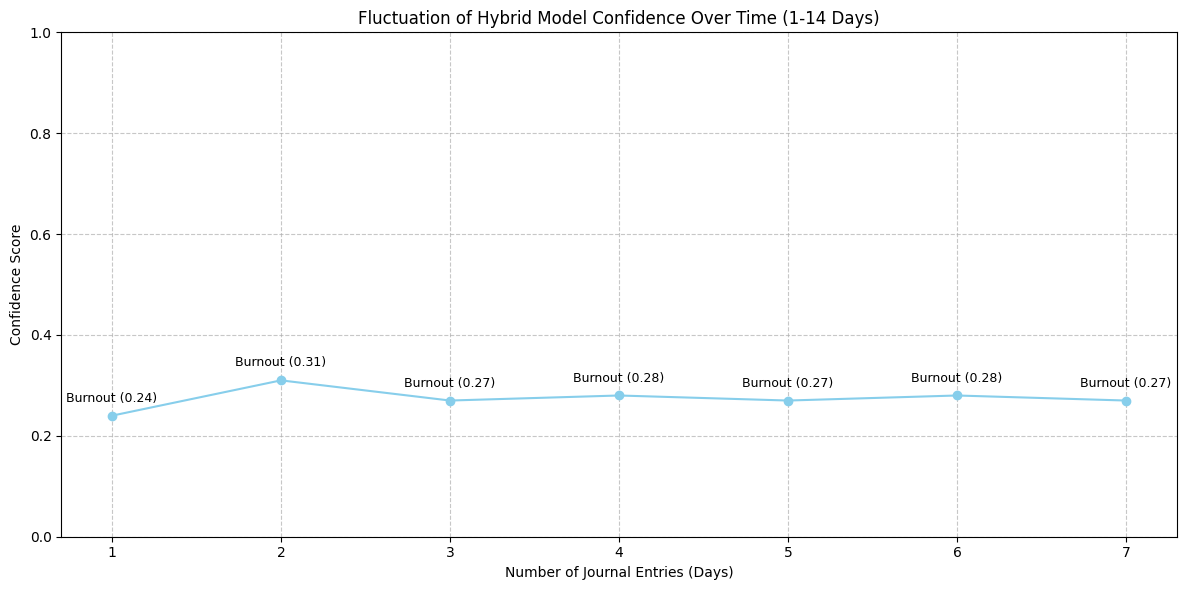

Confidence scores for each day:
Day 1: Burnout (Confidence: 0.24)
Day 2: Burnout (Confidence: 0.31)
Day 3: Burnout (Confidence: 0.27)
Day 4: Burnout (Confidence: 0.28)
Day 5: Burnout (Confidence: 0.27)
Day 6: Burnout (Confidence: 0.28)
Day 7: Burnout (Confidence: 0.27)


In [ ]:
import matplotlib.pyplot as plt

confidence_scores = []
predictions = []

# Loop from 1 day to 14 days
for num_days in range(1, len(new_journal_entries) + 1):
    current_daily_texts = new_journal_entries[:num_days]

    # Use the predict_hybrid_diagnosis function for each cumulative set of entries
    result = predict_hybrid_diagnosis(
        daily_texts=current_daily_texts,
        classifier=classifier,
        tfidf_vectorizer=tfidf_vectorizer,
        rf_combined_model=rf_combined_model,
        emotional_feature_names=emotional_feature_names,
        label_encoder=label_encoder
    )
    confidence_scores.append(result['confidence'])
    predictions.append(result['diagnosis'])

# Plotting the confidence score fluctuation
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(new_journal_entries) + 1), confidence_scores, marker='o', linestyle='-', color='skyblue')
plt.title('Fluctuation of Hybrid Model Confidence Over Time (1-14 Days)')
plt.xlabel('Number of Journal Entries (Days)')
plt.ylabel('Confidence Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(new_journal_entries) + 1)) # Ensure all days are marked on x-axis
plt.ylim(0, 1) # Confidence is between 0 and 1

# Add text labels for predicted diagnosis and confidence on hover (or near points)
for i, (conf, pred) in enumerate(zip(confidence_scores, predictions)):
    plt.annotate(f'{pred} ({conf:.2f})', (i + 1, conf), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Confidence scores for each day:")
for i, (conf, pred) in enumerate(zip(confidence_scores, predictions)):
    print(f"Day {i+1}: {pred} (Confidence: {conf:.2f})")

In [ ]:
emotional_confidence_scores = []
emotional_predictions = []

# Loop from 1 day to 14 days for the emotional model
for num_days in range(1, len(new_journal_entries) + 1):
    current_daily_texts = new_journal_entries[:num_days]

    # Build emotional features for the current cumulative entries
    # The build_patient_emotional_features function expects a list of texts for a single patient across days
    feature_dict_emotional, _, _, _ = build_patient_emotional_features(
        current_daily_texts, classifier, EKMAN_MAPPING
    )

    # Convert emotional features to a DataFrame with correct column names
    # emotional_feature_names comes from the loaded artifacts or was created during training
    emotional_features_df = pd.DataFrame([feature_dict_emotional], columns=emotional_feature_names)

    # Predict using the emotional model (rf_model_tuned)
    pred_emotional_raw = rf_model_tuned.predict(emotional_features_df)
    pred_emotional_label = label_encoder.inverse_transform(pred_emotional_raw)[0]

    # Get probability predictions for the emotional model
    pred_emotional_proba = rf_model_tuned.predict_proba(emotional_features_df)
    # Ensure we get the confidence for the predicted class
    pred_emotional_confidence = pred_emotional_proba[0][pred_emotional_raw[0]]

    emotional_confidence_scores.append(pred_emotional_confidence)
    emotional_predictions.append(pred_emotional_label)

print("Emotional Model Confidence scores for each day:")
for i, (conf, pred) in enumerate(zip(emotional_confidence_scores, emotional_predictions)):
    print(f"Day {i+1}: {pred} (Confidence: {conf:.2f})")

Emotional Model Confidence scores for each day:
Day 1: Healthy (Confidence: 0.27)
Day 2: Depression (Confidence: 0.28)
Day 3: Depression (Confidence: 0.25)
Day 4: Depression (Confidence: 0.25)
Day 5: ADHD (Confidence: 0.31)
Day 6: Burnout (Confidence: 0.31)
Day 7: Burnout (Confidence: 0.38)


In [ ]:
tfidf_confidence_scores = []
tfidf_predictions = []

# Loop from 1 day to 14 days for the TF-IDF model
for num_days in range(1, len(new_journal_entries) + 1):
    current_daily_texts = new_journal_entries[:num_days]

    # Combine current cumulative texts into a single string for TF-IDF
    full_text_for_tfidf_current = ' '.join(current_daily_texts)

    # Transform the text using the fitted tfidf_vectorizer
    tfidf_features_current = tfidf_vectorizer.transform([full_text_for_tfidf_current])

    # Predict using the TF-IDF model (tfidf_rf_pipeline_tuned)
    pred_tfidf_raw_current = tfidf_rf_pipeline_tuned.predict(tfidf_features_current)
    pred_tfidf_label_current = label_encoder.inverse_transform(pred_tfidf_raw_current)[0]

    # Get probability predictions for the TF-IDF model
    pred_tfidf_proba_current = tfidf_rf_pipeline_tuned.predict_proba(tfidf_features_current)
    # Get the confidence for the predicted class
    pred_tfidf_confidence_current = pred_tfidf_proba_current[0][pred_tfidf_raw_current[0]]

    # FIXED: Append confidence and label to their respective lists
    tfidf_confidence_scores.append(pred_tfidf_confidence_current)
    tfidf_predictions.append(pred_tfidf_label_current)

print("TF-IDF Model Confidence scores for each day:")
for i, (conf, pred) in enumerate(zip(tfidf_confidence_scores, tfidf_predictions)):
    print(f"Day {i+1}: {pred} (Confidence: {conf:.2f})")

TF-IDF Model Confidence scores for each day:
Day 1: Anxiety (Confidence: 0.26)
Day 2: Burnout (Confidence: 0.23)
Day 3: Burnout (Confidence: 0.24)
Day 4: Anxiety (Confidence: 0.25)
Day 5: Burnout (Confidence: 0.25)
Day 6: Burnout (Confidence: 0.24)
Day 7: Anxiety (Confidence: 0.22)


Acum, să vizualizăm curbele de încredere pentru modelul hibrid, emoțional și TF-IDF pe același grafic pentru a le compara.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

# Plot Hybrid Model Confidence
plt.plot(range(1, len(new_journal_entries) + 1), confidence_scores, marker='o', linestyle='-', linewidth=2.5, color='skyblue', label='Hybrid Model')

# Plot Emotional Model Confidence
plt.plot(range(1, len(new_journal_entries) + 1), emotional_confidence_scores, marker='x', linestyle='--', linewidth=2.5, color='lightcoral', label='Emotional Model')

# Plot TF-IDF Model Confidence
plt.plot(range(1, len(new_journal_entries) + 1), tfidf_confidence_scores, marker='s', linestyle='-.', linewidth=2.5, color='green', label='TF-IDF Model')

# Chart formatting and labels
plt.title('Model Confidence Fluctuation: Hybrid vs. Emotional vs. TF-IDF (1-14 Days)', fontsize=15, pad=20)
plt.xlabel('Journal Entry Index (Days)', fontsize=12, labelpad=12)
plt.ylabel('Confidence Score', fontsize=12, labelpad=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Wider horizontal margins
plt.margins(x=0.1)

plt.xticks(range(1, len(new_journal_entries) + 1), fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.35)  # More space above for labels
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Add text labels for Hybrid Model (much higher than the point)
for i, (conf, pred) in enumerate(zip(confidence_scores, predictions)):
    plt.annotate(
        f'{pred} ({conf:.2f})',
        (i + 1, conf),
        textcoords="offset points",
        xytext=(0, 22),
        ha='center',
        fontsize=9,
        color='#0277BD', # A darker and visible blue
        fontweight='bold'
    )

# Add text labels for Emotional Model (at a neutral distance from the point)
for i, (conf, pred) in enumerate(zip(emotional_confidence_scores, emotional_predictions)):
    plt.annotate(
        f'{pred} ({conf:.2f})',
        (i + 1, conf),
        textcoords="offset points",
        xytext=(0, -12),
        ha='center',
        fontsize=9,
        color='#C62828', # A darker red/coral
        fontweight='bold'
    )

# Add text labels for TF-IDF Model (much lower than the point)
for i, (conf, pred) in enumerate(zip(tfidf_confidence_scores, tfidf_predictions)):
    plt.annotate(
        f'{pred} ({conf:.2f})',
        (i + 1, conf),
        textcoords="offset points",
        xytext=(0, -42),
        ha='center',
        fontsize=9,
        color='#2E7D32', # A darker green
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined